# 강원도 산불 분석 보고서 기입용 EDA 노트북

이 노트북 파일은 본 프로젝트의 전체 EDA 중에서 보고서에 작성할 핵심 결과만 추출한 것이다.  

노트북 개요 제목은 보고서의 목차랑 동일하다.

# 데이터 불러오기

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
TYPE_PALETTE = {
    "영동 해안형": "#2A6FBB",
    "영서 내륙형": "#2E8B57",
    "고지·산간형": "#C97A28",
}
TARGET_CRS = "EPSG:5186"

plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def find_report_dir() -> Path:
    cwd = Path.cwd()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "primary_manifest.csv").exists():
            return candidate
    raise FileNotFoundError("data/primary_manifest.csv를 찾지 못했습니다. EDA_test 폴더에서 실행하세요.")


REPORT_DIR = find_report_dir()
DATA_DIR = REPORT_DIR / "data"
OUTPUT_DIR = REPORT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for stale_png in OUTPUT_DIR.glob("*.png"):
    stale_png.unlink()


PRIMARY_FILES = {
    "cells": "primary_cells.csv",
    "fire_events": "primary_fire_events.csv",
    "matched_weather": "primary_matched_weather.csv",
    "canadian_index": "primary_canadian_index.csv",
    "lead_thresholds": "primary_lead_thresholds.csv",
    "spatial_context": "primary_spatial_context.csv",
    "manifest": "primary_manifest.csv",
}


FIGURE_FILES = {
    "fig01": "그림 1 강원도 기상셀과 기후지형유형.png",
    "fig02": "그림 2 산불 발생 위치와 기후지형유형.png",
    "fig03": "그림 3 기후지형유형별 배경 기후·지형 차이.png",
    "fig04": "그림 4 월별·시간대별 산불 발생 건수.png",
    "fig05": "그림 5 대조군과 비교한 산불 발생 전 습도.png",
}


TEXT_COLS = {
    "source_table", "variable", "feature", "feature_family", "condition", "group",
    "expected_direction", "risk_direction", "support_flag", "decision_grade", "note",
    "description", "operator", "metric", "value", "notes", "sample_group", "item",
    "fire_exposure_id", "기상셀ID", "기준시각", "date", "season", "계절", "기후지형유형",
    "기후권역", "FWI지수", "spatial_layer", "spatial_layer_500", "comparison_frame",
    "L1_NAME", "L2_NAME", "control_id", "matched_fire_id", "변수명", "등급",
    "권장 피처 처리 방식", "선정/제외 사유", "해석 메모", "geometry_wkt",
}


def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if col in TEXT_COLS:
            continue
        converted = pd.to_numeric(out[col], errors="coerce")
        non_null = out[col].notna()
        if non_null.any() and converted[non_null].notna().all():
            out[col] = converted
    return out


def load_primary_data() -> dict[str, pd.DataFrame]:
    data = {}
    for key, filename in PRIMARY_FILES.items():
        path = DATA_DIR / filename
        if not path.exists():
            raise FileNotFoundError(path)
        data[key] = pd.read_csv(path, encoding="utf-8-sig")
    return data


def unpack_table(packed: pd.DataFrame, source_table: str) -> pd.DataFrame:
    out = packed.loc[packed["source_table"] == source_table].drop(columns=["source_table"])
    out = out.dropna(axis=1, how="all").reset_index(drop=True)
    return coerce_numeric(out)


def derive_secondary_tables(primary: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    tables = {}
    for key in ["matched_weather", "canadian_index", "lead_thresholds", "spatial_context"]:
        packed = primary[key]
        for source_table in packed["source_table"].dropna().unique():
            tables[source_table] = unpack_table(packed, source_table)
    return tables


def set_type_order(frame: pd.DataFrame, col: str = "기후지형유형") -> pd.DataFrame:
    out = frame.copy()
    if col in out.columns:
        out[col] = pd.Categorical(out[col], categories=TYPE_ORDER, ordered=True)
    return out


def make_cells_gdf(primary: dict[str, pd.DataFrame]) -> gpd.GeoDataFrame:
    cells = coerce_numeric(primary["cells"])
    return gpd.GeoDataFrame(
        cells,
        geometry=gpd.GeoSeries.from_wkt(cells["geometry_wkt"]),
        crs="EPSG:4326",
    )


def make_fire_gdf(primary: dict[str, pd.DataFrame]) -> gpd.GeoDataFrame:
    fires = coerce_numeric(primary["fire_events"])
    return gpd.GeoDataFrame(
        fires,
        geometry=gpd.GeoSeries.from_wkt(fires["geometry_wkt"]),
        crs="EPSG:4326",
    )


primary = load_primary_data()
tables = derive_secondary_tables(primary)
cells_gdf = set_type_order(make_cells_gdf(primary))
fire_gdf = set_type_order(make_fire_gdf(primary))

display(primary["manifest"])
print("table keys:", sorted(tables))

C:\Users\swoo6\AppData\Local\Temp\ipykernel_14752\3576684531.py:86: DtypeWarning: Columns (0: full_5_matched, 1: is_ys0071, 2: is_less_than_5_matched, 3: is_2021_feb_cluster, 4: risk_direction_match, 5: group, 6: support_flag, 7: date_ci_excludes_zero, 8: cell_ci_excludes_zero, 9: candidate_priority, 10: condition, 11: decision_grade, 12: note) have mixed types. Specify dtype option on import or set low_memory=False.
  data[key] = pd.read_csv(path, encoding="utf-8-sig")


,domain,filename,rows,columns,size_bytes
0,cells,primary_cells.csv,92,22,65547
1,fire_events,primary_fire_events.csv,3405,11,458196
2,matched_weather,primary_matched_weather.csv,57,64,25776
3,canadian_index,primary_canadian_index.csv,1274,70,402554
4,lead_thresholds,primary_lead_thresholds.csv,44232,59,11572782
5,spatial_context,primary_spatial_context.csv,6196,97,2688961


table keys: ['S1-08_fwi_season_cell_summary', 'S1-08_fwi_season_friedman', 'S2-05_weather_comparison', 'S2-06_canadian_comparison', 'S2-07_weather_delta_summary', 'S2-08_analysis_scope', 'S2-08_canadian_delta_raw', 'S2-08_canadian_delta_summary', 'S2-08_population_validation', 'S2-08_sample_group_counts', 'S2-09_heterogeneity_tests', 'S3-02_lead_window_delta_raw', 'S3-02_lead_window_delta_summary', 'S3-02_window_rank_overall', 'S3-04_dry_spell_threshold_summary', 'S3-04_post_rain_drying_proxy', 'S3-04_rain_elapsed_summary', 'S3-05_wind_direction_condition_summary', 'S3-05_wind_duration_summary', 'S3-07_threshold_performance_summary', 'S3-08_compound_condition_summary', 'S3-10_candidate_threshold_registry', 'S4-02_fire_terrain_summary', 'S4-03_access_threshold_sensitivity', 'S4-03_accessibility_distance_summary', 'S4-03_spatial_layer_assignment', 'S4-04_spatial_control_pool', 'S4-04_spatial_control_pool_audit', 'S4-05_effect_size_by_variable', 'S4-05_fire_vs_spatial_control_summary', 'S

# EDA 코드

## 2. 데이터 탐색 및 전처리 

### 2-2. 기상 데이터

#### <그림 1> 강원도 기상셀과 기후지형유형

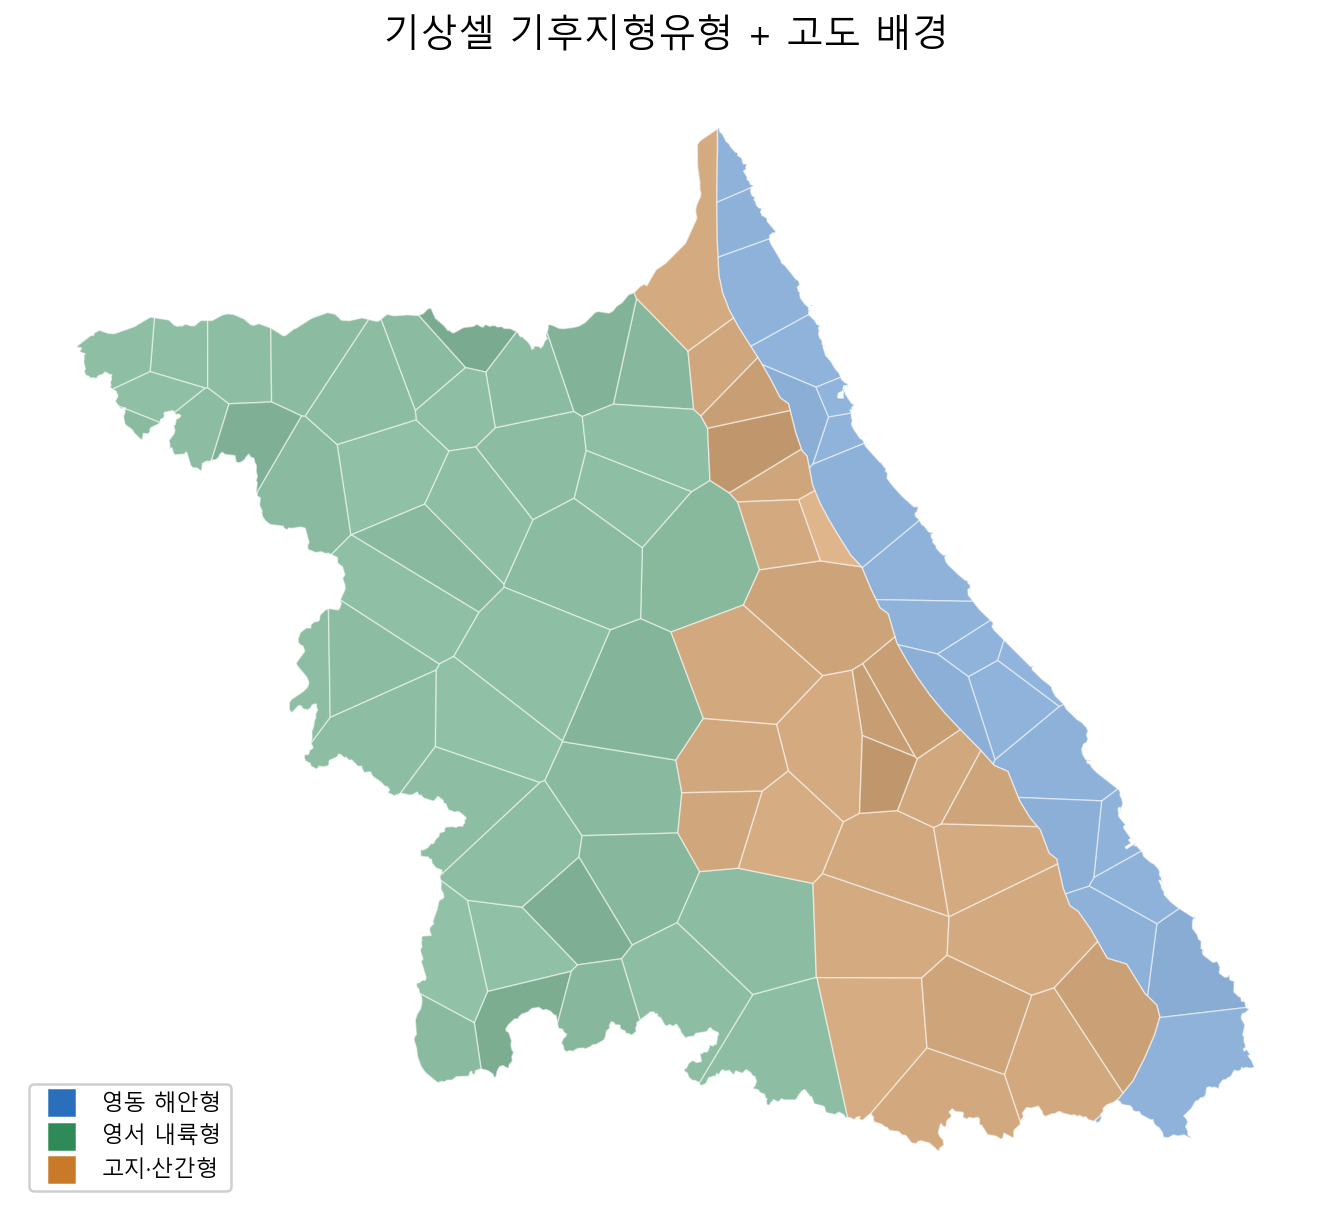

'그림 1 강원도 기상셀과 기후지형유형.png'

In [2]:
grid_map = cells_gdf.to_crs(TARGET_CRS)
fig, ax = plt.subplots(figsize=(7.5, 7.2), dpi=180)
ax.set_facecolor("white")

if "DEM_고도_m" in grid_map.columns:
    grid_map.plot(
        ax=ax,
        column="DEM_고도_m",
        cmap="Greys",
        alpha=0.28,
        edgecolor="none",
        zorder=0,
    )

for climate_type in TYPE_ORDER:
    part = grid_map.loc[grid_map["기후지형유형"] == climate_type]
    part.plot(
        ax=ax,
        color=TYPE_PALETTE[climate_type],
        edgecolor="white",
        linewidth=0.55,
        alpha=0.52,
        zorder=2,
    )

ax.set_title("기상셀 기후지형유형 + 고도 배경", fontsize=15, pad=12)
ax.set_aspect("equal")
ax.set_axis_off()
handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", color=TYPE_PALETTE[t], label=t, markersize=10)
    for t in TYPE_ORDER
]
ax.legend(handles=handles, loc="lower left", frameon=True, framealpha=0.94, fontsize=9)
fig.tight_layout()

fig01 = OUTPUT_DIR / FIGURE_FILES["fig01"]
fig.savefig(fig01, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
fig01.name

- 기상 자료는 기상청 ASOS/AWS의 시간·일 단위 관측자료를 사용하였다. 
- 이때 분석의 기상 단위를 행정구역이 아니라 ‘기상셀’로 설정하였다. 
- 강원도 내 관측지점의 공간적 영향권을 반영하기 위해 영동·영서 권역별 Voronoi(관측지점과의 거리가 가장 가까운 영역끼리 공간을 나누는 방법.) 기반으로 셀을 구축하고, 셀 중심점의 기상값은 주변 관측값을 IDW (가까운 관측지점일수록 더 큰 가중치를 주어 값을 보간하는 방법.) 방식으로 보간하였다. 
- 그 결과 총 92개 기상셀이 생성되었으며, 산불 발생 좌표는 해당 기상셀에 연결하였다.
- 또한 각 기상셀은 산불 발생 특성을 해석하기 위해 기후·지형 유형으로 재분류하였다. 
- 기존의 태백산맥 기준 영동/영서 구분만으로는 영서 내부의 고지 산지축을 충분히 설명하기 어려웠다. 
- 이에 기존 영동 지역의 21개 셀은 영동 해안형으로 유지하고, 기상셀별 고도, 기온, 일교차, 풍속, 습도 특성을 바탕으로 영서 내부의 동쪽 고고도 산지축을 27개의 고지·산간형 셀로 분리하였으며, 나머지 44개의 영서 셀은 영서 내륙형으로 구분하였다. 
- 이 구분은 산불 위험등급이 아니라 산불 발생 특성을 층화하여 해석하기 위한 기준 변수로 사용하였다.

## 3. EDA (탐색적 데이터 분석)

### 3-1. 강원도 산불 분석의 기본 축 : 기후지형유형

#### <그림 2> 산불 발생 위치와 기후지형유형

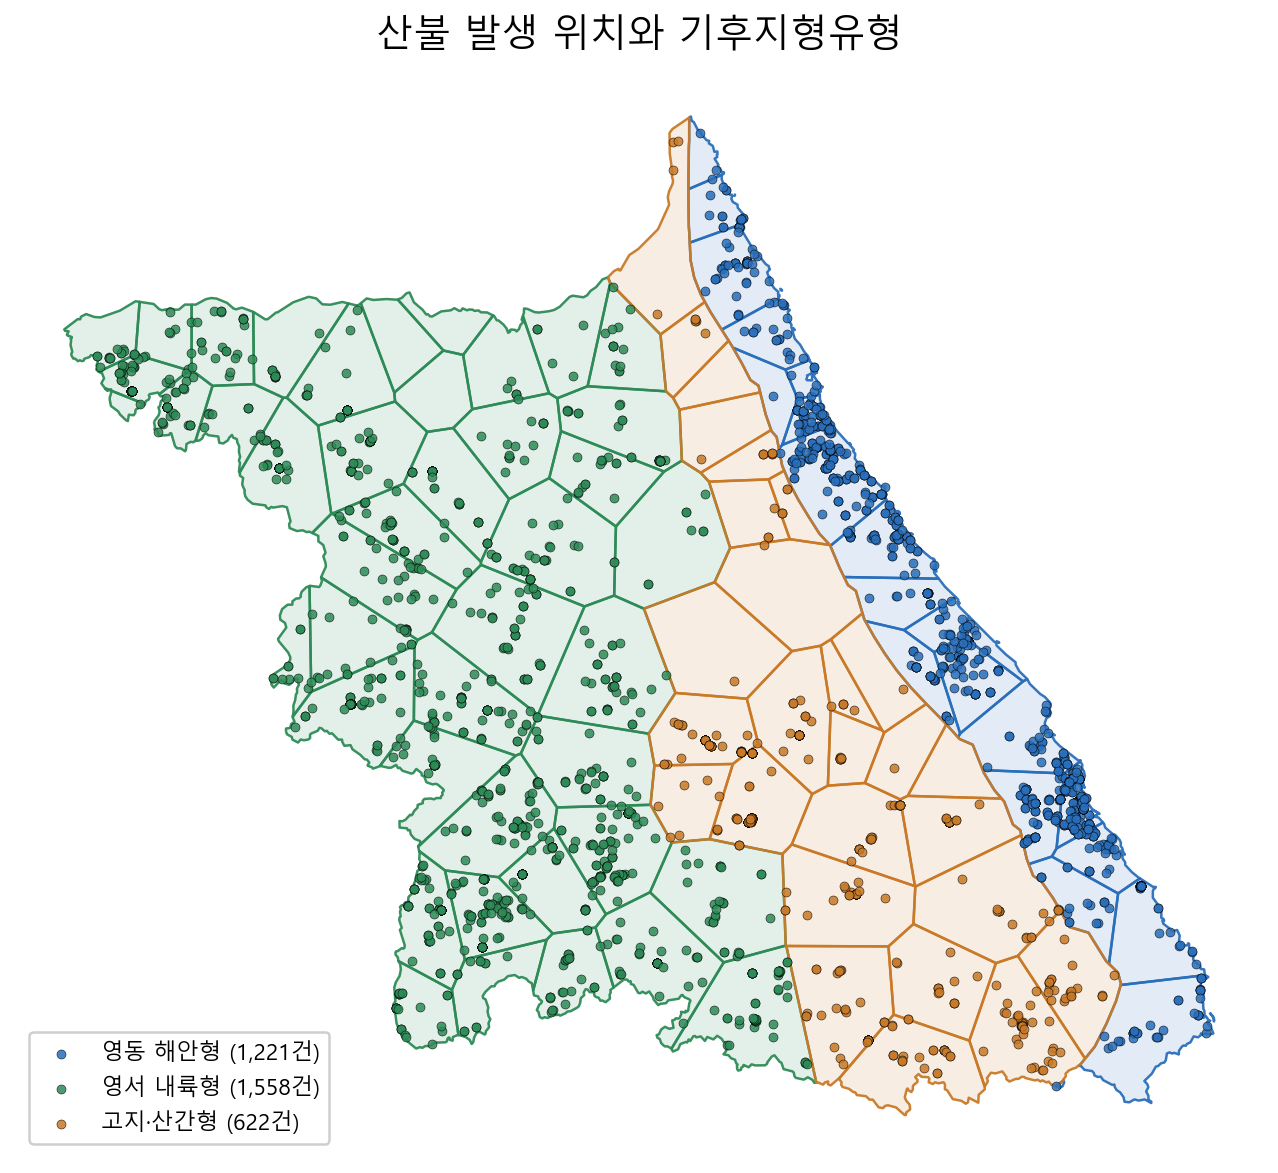

,기후지형유형,기상셀수,산불좌표수
0,영동 해안형,21,1221
1,영서 내륙형,44,1558
2,고지·산간형,27,622


'그림 2 산불 발생 위치와 기후지형유형.png'

In [3]:
grid_map = cells_gdf.to_crs(TARGET_CRS)
fire_map = fire_gdf.loc[fire_gdf["기상셀ID"].notna()].to_crs(TARGET_CRS)

fig, ax = plt.subplots(figsize=(7.2, 8.2), dpi=180)
ax.set_facecolor("white")

for climate_type in TYPE_ORDER:
    cell_part = grid_map.loc[grid_map["기후지형유형"] == climate_type]
    cell_part.plot(
        ax=ax,
        color=TYPE_PALETTE[climate_type],
        edgecolor="white",
        linewidth=0.35,
        alpha=0.13,
        zorder=1,
    )
    cell_part.boundary.plot(
        ax=ax,
        color=TYPE_PALETTE[climate_type],
        linewidth=1.0,
        alpha=0.95,
        zorder=2,
    )

    fire_part = fire_map.loc[fire_map["기후지형유형"] == climate_type]
    ax.scatter(
        fire_part.geometry.x,
        fire_part.geometry.y,
        s=13,
        color=TYPE_PALETTE[climate_type],
        edgecolor="black",
        linewidth=0.22,
        alpha=0.86,
        label=f"{climate_type} ({len(fire_part):,}건)",
        zorder=3,
    )

minx, miny, maxx, maxy = grid_map.total_bounds
pad_x = (maxx - minx) * 0.04
pad_y = (maxy - miny) * 0.04
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("산불 발생 위치와 기후지형유형", fontsize=15, pad=12)
ax.legend(loc="lower left", frameon=True, framealpha=0.94, fontsize=9)
fig.tight_layout()

fig02 = OUTPUT_DIR / FIGURE_FILES["fig02"]
fig.savefig(fig02, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

summary = pd.concat(
    [
        cells_gdf["기후지형유형"].value_counts().reindex(TYPE_ORDER).rename("기상셀수"),
        fire_map["기후지형유형"].value_counts().reindex(TYPE_ORDER).rename("산불좌표수"),
    ],
    axis=1,
).reset_index(names="기후지형유형")
display(summary)
fig02.name

- 먼저 산불 발생 위치를 기후·지형 유형별로 구분하여 공간적 분포를 확인하였다. 
- 산불 발생 건수는 영서 내륙형 1,558건, 영동 해안형 1,221건, 고지·산간형 622건 순으로 나타났다. 
- 영서 내륙형은 강원도 서부 전반에 걸쳐 산불 발생 지점이 넓게 분포하였고, 영동 해안형은 동해안 축을 따라 비교적 집중적으로 분포하였다. 
- 반면 고지·산간형은 산지 전역에서 고르게 발생하기보다는, 산간 마을, 계곡부, 도로 접근이 가능한 생활권 주변에서 발생하는 경향을 보였다.

#### <그림 3> 기후지형유형별 배경 기후·지형 차이

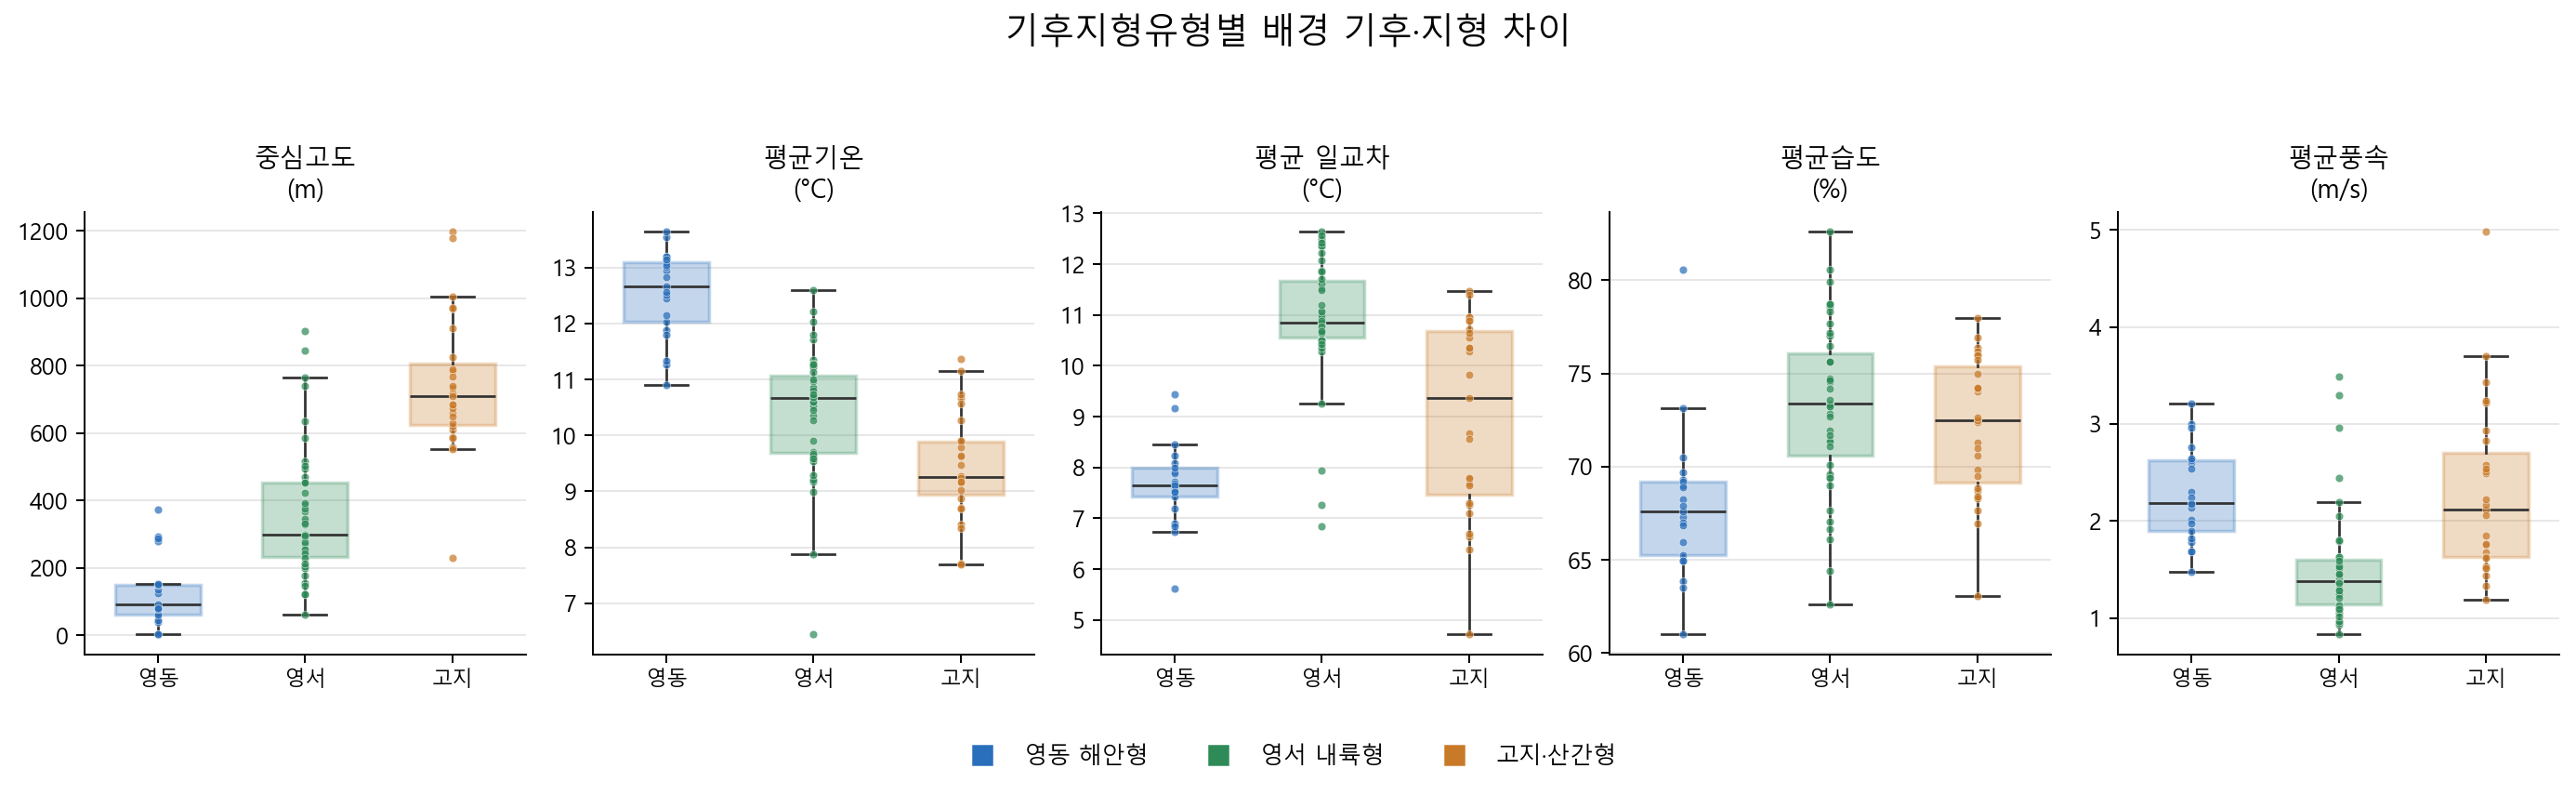

,기후지형유형,DEM_고도_m,평균기온_C,평균_일교차_C,평균습도_pct,평균풍속_m_s
0,영동 해안형,91.378746,12.662717,7.646772,67.601645,2.180498
1,영서 내륙형,297.275391,10.664723,10.852585,73.378165,1.378340
2,고지·산간형,708.671021,9.262117,9.374254,72.476389,2.116822


'그림 3 기후지형유형별 배경 기후·지형 차이.png'

In [4]:
climate = set_type_order(coerce_numeric(primary["cells"]))
climate_clean = climate.loc[climate["기상셀ID"] != "YS_0071"].copy()

plot_vars = [
    ("DEM_고도_m", "중심고도\n(m)"),
    ("평균기온_C", "평균기온\n(°C)"),
    ("평균_일교차_C", "평균 일교차\n(°C)"),
    ("평균습도_pct", "평균습도\n(%)"),
    ("평균풍속_m_s", "평균풍속\n(m/s)"),
]

fig, axes = plt.subplots(1, len(plot_vars), figsize=(15.5, 4.4), dpi=180)
for ax, (col, label) in zip(axes, plot_vars):
    data = [climate_clean.loc[climate_clean["기후지형유형"] == t, col].dropna() for t in TYPE_ORDER]
    box = ax.boxplot(data, patch_artist=True, widths=0.58, showfliers=False)
    for patch, t in zip(box["boxes"], TYPE_ORDER):
        patch.set_facecolor(TYPE_PALETTE[t])
        patch.set_alpha(0.28)
        patch.set_edgecolor(TYPE_PALETTE[t])
        patch.set_linewidth(1.4)
    for part in ["whiskers", "caps", "medians"]:
        for line in box[part]:
            line.set_color("#333333")
            line.set_linewidth(1.1)
    for i, t in enumerate(TYPE_ORDER, start=1):
        vals = data[i - 1]
        ax.scatter([i] * len(vals), vals, s=12, color=TYPE_PALETTE[t], edgecolor="white", linewidth=0.25, alpha=0.72, zorder=3)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(range(1, len(TYPE_ORDER) + 1))
    ax.set_xticklabels(["영동", "영서", "고지"], fontsize=9)
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)

handles = [plt.Line2D([0], [0], marker="s", linestyle="", color=TYPE_PALETTE[t], label=t, markersize=8) for t in TYPE_ORDER]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("기후지형유형별 배경 기후·지형 차이", fontsize=15, y=1.02)
fig.tight_layout(rect=(0, 0.07, 1, 0.96))

fig03 = OUTPUT_DIR / FIGURE_FILES["fig03"]
fig.savefig(fig03, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

display(
    climate_clean.groupby("기후지형유형", observed=False)[[col for col, _ in plot_vars]]
    .median()
    .reindex(TYPE_ORDER)
    .reset_index()
)
fig03.name

- 다음으로 기후·지형 유형별 해당 지역의 기상·지형 차이를 확인하였다. 
- <그림 3>에서 영동 해안형은 중심고도 91m, 평균기온 12.66°C, 평균습도 67.60%로 양간지풍의 영향을 받는 저고도·저습·강풍성 해안 기후의 특성이 뚜렷하다. 
- 영서 내륙형은 평균 일교차 10.85°C, 평균풍속 1.38m/s로 일교차가 크고 바람이 약한 내륙형 분포를 보였다. 고지·산간형은 중심고도 709m, 평균기온 9.26°C로 고도가 높고 기온이 낮으며, 주요 기상 특성은 영동과 영서의 중간적 성격을 보였다. 
- 이를 통해 강원도가 하나의 균질한 기상권이 아님을 보여주며, 기후·지형 유형이 강원도 내부의 배경 기후와 지형 차이를 반영하는 유의미한 층화 기준으로 활용될 수 있음을 시사한다.

### 3-2. 산불 발생의 시간적 집중과 권역별 차이

#### <그림 4> 월별·시간대별 산불 발생 건수

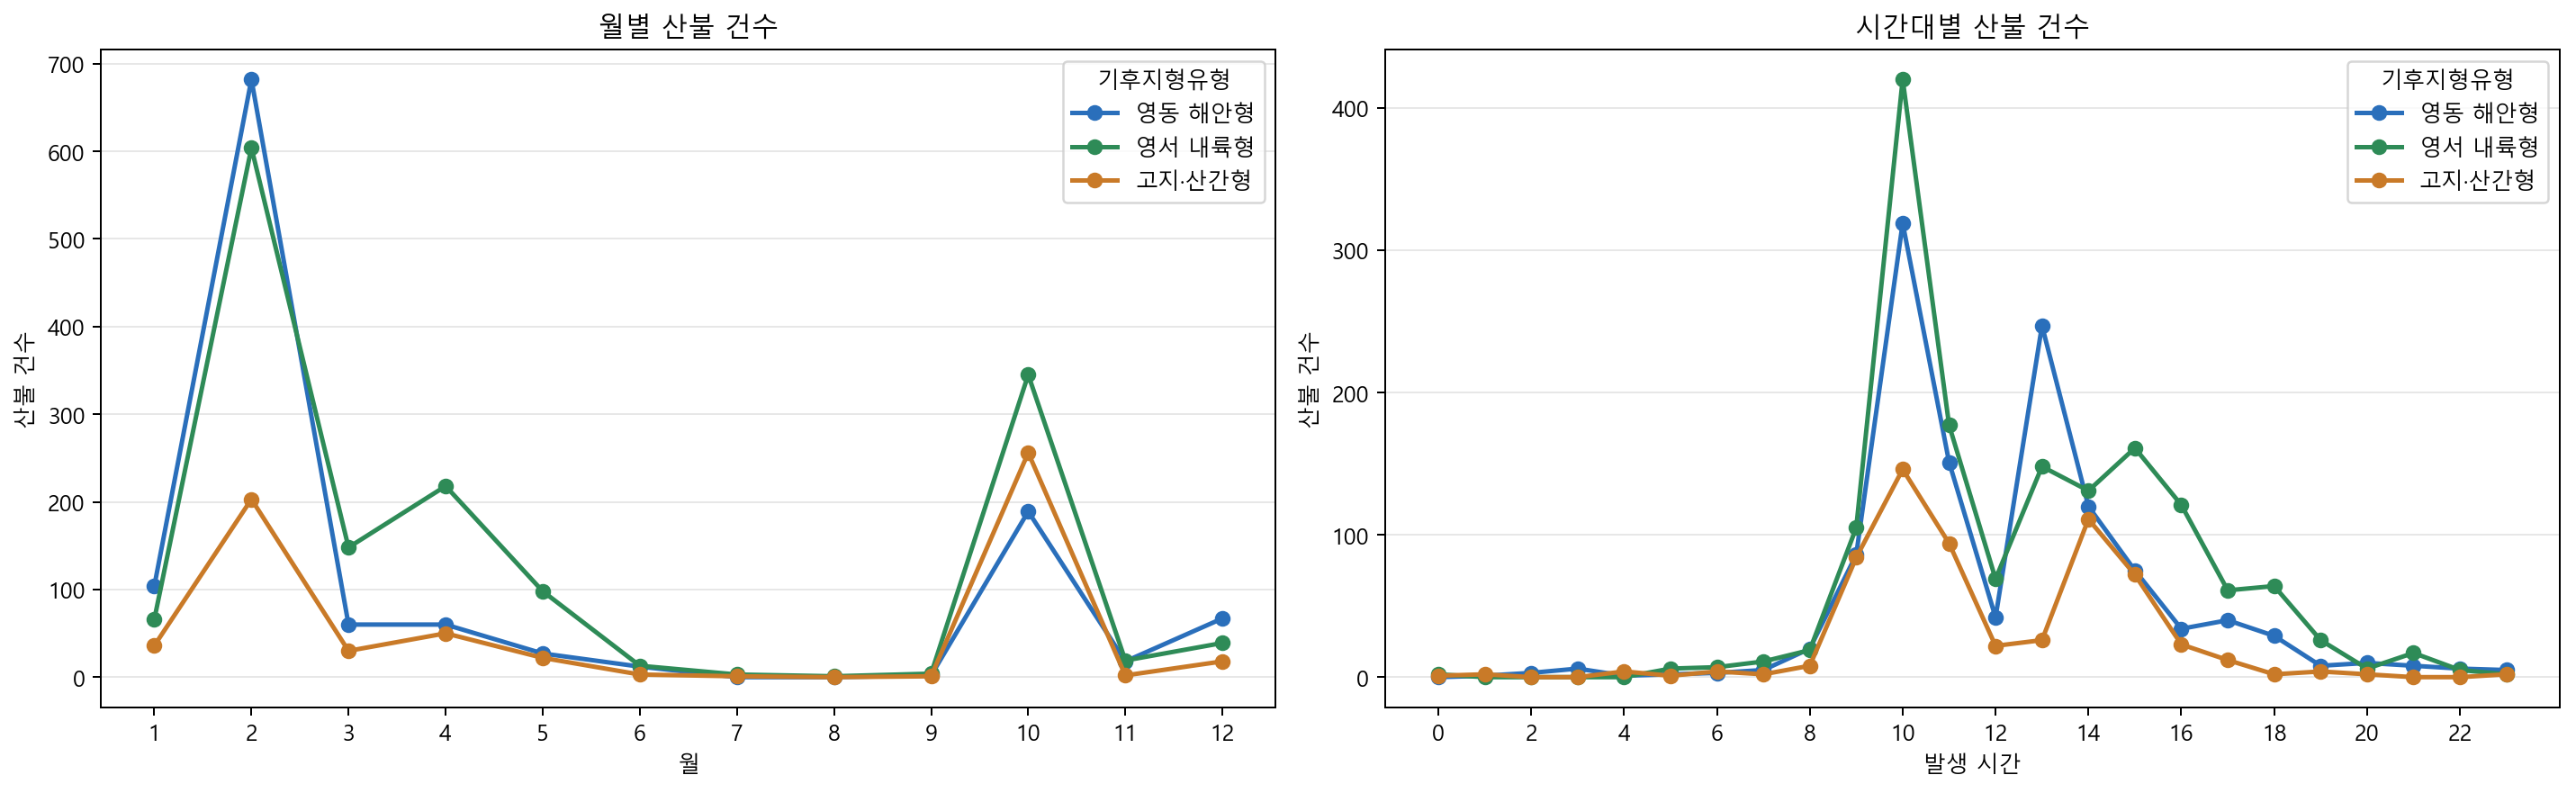

'그림 4 월별·시간대별 산불 발생 건수.png'

In [5]:
fires = set_type_order(coerce_numeric(primary["fire_events"]))
fires = fires.loc[fires["기상셀ID"].notna()].copy()
fires["월"] = pd.to_numeric(fires["월"], errors="coerce").astype("Int64")
fires["시간"] = pd.to_numeric(fires["시간"], errors="coerce").astype("Int64")

month_counts = fires.groupby(["월", "기후지형유형"], observed=False).size().rename("산불건수").reset_index()
hour_counts = fires.groupby(["시간", "기후지형유형"], observed=False).size().rename("산불건수").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=180)
for climate_type in TYPE_ORDER:
    part = month_counts.loc[month_counts["기후지형유형"] == climate_type].set_index("월")["산불건수"].reindex(range(1, 13), fill_value=0)
    axes[0].plot(part.index, part.values, marker="o", linewidth=2, color=TYPE_PALETTE[climate_type], label=climate_type)
axes[0].set_title("월별 산불 건수")
axes[0].set_xlabel("월")
axes[0].set_ylabel("산불 건수")
axes[0].set_xticks(range(1, 13))
axes[0].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
axes[0].legend(title="기후지형유형")

for climate_type in TYPE_ORDER:
    part = hour_counts.loc[hour_counts["기후지형유형"] == climate_type].set_index("시간")["산불건수"].reindex(range(24), fill_value=0)
    axes[1].plot(part.index, part.values, marker="o", linewidth=2, color=TYPE_PALETTE[climate_type], label=climate_type)
axes[1].set_title("시간대별 산불 건수")
axes[1].set_xlabel("발생 시간")
axes[1].set_ylabel("산불 건수")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
axes[1].legend(title="기후지형유형")
fig.tight_layout()

fig04 = OUTPUT_DIR / FIGURE_FILES["fig04"]
fig.savefig(fig04, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
fig04.name

- 월별 산불 발생 건수를 보면, 주로 10월부터 이듬해 5월 사이에 집중되며, 특히 2월과 10월에 매우 큰 발생 피크가 나타났다. 
- 영동 해안형과 고지·산간형은 2월 발생 집중도가 두드러지는 반면, 영서 내륙형은 2월과 10월뿐 아니라 3~5월에도 산불 발생이 이어지는 양상을 보였다. 
- 이는 영동 해안형과 고지·산간형에서는 겨울철 특정 시기의 집중 발생이 강하고, 영서 내륙형에서는 봄철까지 산불 발생 기간이 더 넓게 이어짐을 의미한다.
- 시간대별 분포를 보면 산불은 주로 오전부터 오후 시간대에 집중되어 있으며, 야간 발생은 상대적으로 적었다. 
- 이는 산불 발생이 단순히 건조한 기상 조건만으로 설명되기보다는, 계절적 건조 조건과 함께 낮 시간대의 인간 활동이 결합되어 나타나는 현상임을 시사한다. 
- 따라서 이후 분석에서는 산불 발생을 기상 조건만으로 해석하지 않고, 계절·시간대·인간 활동 배경을 함께 고려하였다.

### 3-3. 산불 발생 전 기상 조건

#### 3-3-1. 습도

##### <그림 5> 대조군과 비교한 산불 발생 전 습도

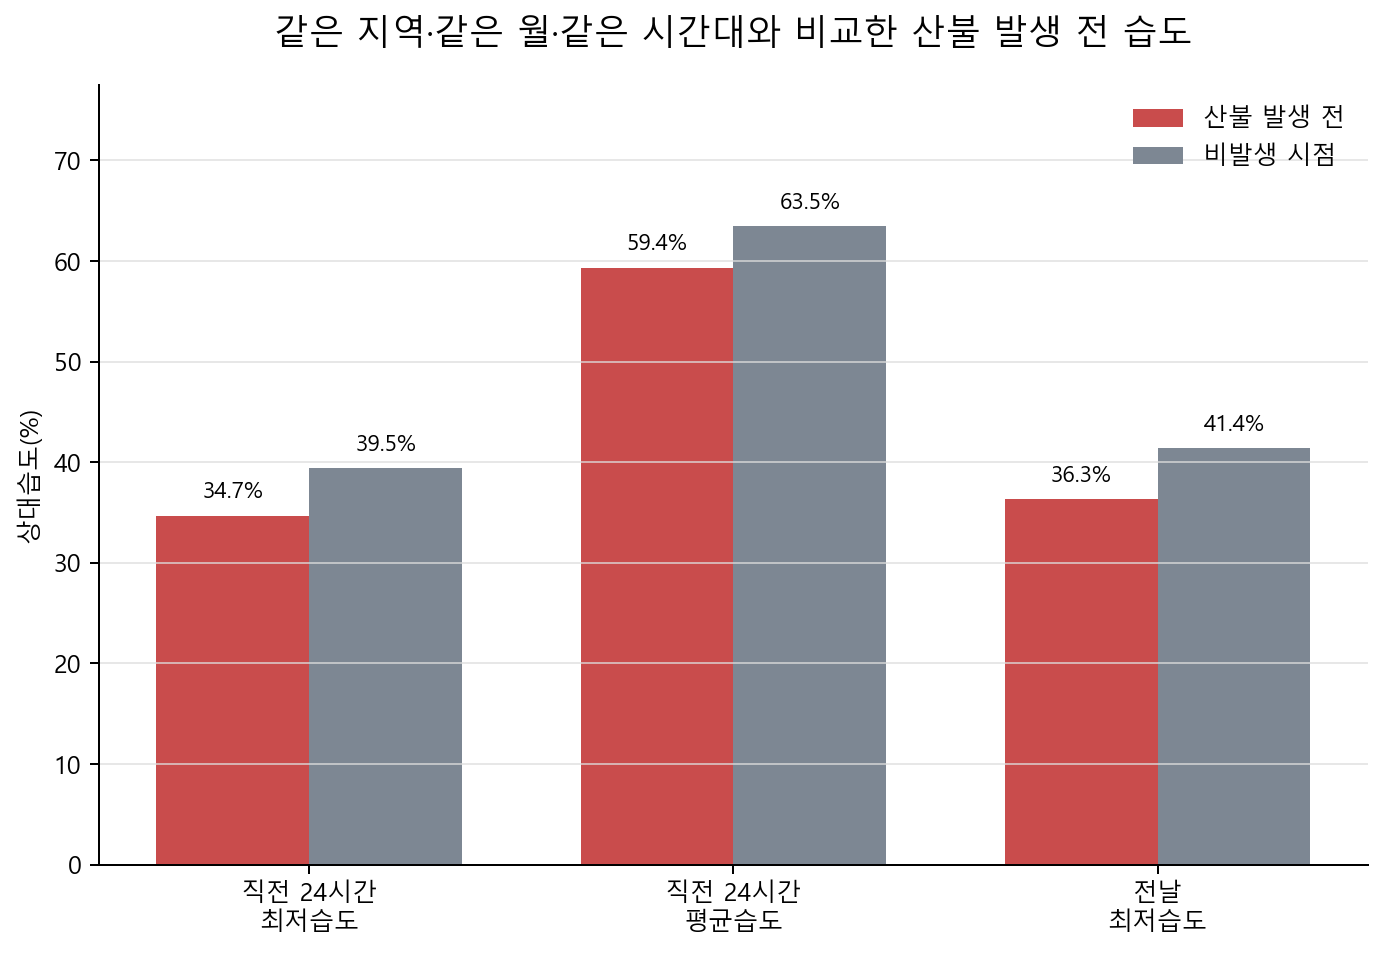

,항목,산불 발생 전 평균,비발생 시점 평균,차이,95% 범위,통계 검정 결과
0,직전 24시간 최저습도,34.70%,39.46%,4.76%p 낮음,3.35~6.10%p 낮음,95% 범위가 0을 지나지 않음
1,직전 24시간 평균습도,59.35%,63.49%,4.14%p 낮음,2.23~5.99%p 낮음,95% 범위가 0을 지나지 않음
2,전날 최저습도,36.31%,41.42%,5.11%p 낮음,3.28~6.76%p 낮음,95% 범위가 0을 지나지 않음


,항목,산불 발생 전 평균(%),산불 발생 전 중앙값(%),비발생 시점 평균(%),비발생 시점 중앙값(%),"평균 차이(%p, 산불-비발생)",평균 차이 95% 하한,평균 차이 95% 상한,산불 쪽이 더 낮았던 사건 비율(%),대응 검정 p값,보정 p값
0,직전 24시간 최저습도,34.70,30.23,39.46,34.97,-4.76,-6.10,-3.35,68.09,3.89e-28,6.80e-27
1,직전 24시간 평균습도,59.35,59.51,63.49,62.65,-4.14,-5.99,-2.23,61.30,1.67e-21,9.20e-21
2,전날 최저습도,36.31,31.56,41.42,36.79,-5.11,-6.76,-3.28,69.19,6.18e-28,6.80e-27


,습도 항목,선행 시간,산불 발생 전 평균(%),비발생 시점 평균(%),"차이(%p, 산불-비발생)",95% 범위,산불 쪽이 더 낮았던 사건 비율(%),보정 p값
11,선행 최저습도,1시간,52.54,57.19,-4.65,-7.61~-1.15,62.09,3.23e-15
7,선행 최저습도,3시간,50.55,55.26,-4.72,-7.86~-0.85,63.39,4.83e-16
6,선행 최저습도,6시간,48.80,53.51,-4.72,-7.96~-1.30,63.04,1.05e-16
12,선행 최저습도,12시간,45.88,50.18,-4.30,-7.02~-1.16,61.83,3.23e-15
0,선행 최저습도,24시간,34.71,39.44,-4.73,-6.02~-3.37,67.97,1.28e-25
2,선행 최저습도,48시간,31.00,34.40,-3.39,-4.52~-2.32,64.75,4.61e-20
13,선행 최저습도,72시간,28.94,31.48,-2.53,-3.55~-1.50,62.62,6.79e-14
10,선행 평균습도,1시간,52.54,57.19,-4.65,-7.93~-1.11,62.09,3.23e-15
5,선행 평균습도,3시간,54.79,59.61,-4.82,-8.10~-1.35,62.17,4.41e-17
4,선행 평균습도,6시간,58.37,63.04,-4.67,-7.89~-1.33,61.57,1.76e-17


'그림 5 대조군과 비교한 산불 발생 전 습도.png'

In [6]:

# ============================================================
# 1. 데이터 불러오기
# ============================================================

humidity_matched = coerce_numeric(tables["S2-07_weather_delta_summary"])

window_rank = coerce_numeric(tables["S3-02_window_rank_overall"])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. 습도 비교용 데이터 구성
# ============================================================

humidity_vars = [
    "직전24h_최소습도",
    "직전24h_평균습도",
    "D-1_최소습도_pct",
]

humidity_names = {
    "직전24h_최소습도": "직전 24시간 최저습도",
    "직전24h_평균습도": "직전 24시간 평균습도",
    "D-1_최소습도_pct": "전날 최저습도",
}

humidity_plot_labels = {
    "직전24h_최소습도": "직전 24시간\n최저습도",
    "직전24h_평균습도": "직전 24시간\n평균습도",
    "D-1_최소습도_pct": "전날\n최저습도",
}

main = (
    humidity_matched.loc[humidity_matched["variable"].isin(humidity_vars)]
    .set_index("variable")
    .loc[humidity_vars]
    .reset_index()
)

main["항목"] = main["variable"].map(humidity_names)
main["plot_label"] = main["variable"].map(humidity_plot_labels)

# 산불 발생 전 평균 - 비발생 시점 평균이 음수이면,
# 산불 발생 전 습도가 더 낮다는 의미이므로 보기 쉽게 양수 방향으로 변환
main["낮은정도"] = -main["mean_delta"]
main["낮은정도_하한"] = -main["mean_delta_ci_upper"]
main["낮은정도_상한"] = -main["mean_delta_ci_lower"]

main["검정판단"] = np.where(
    (main["mean_delta_ci_lower"] < 0) & (main["mean_delta_ci_upper"] < 0),
    "95% 범위가 0을 지나지 않음",
    "95% 범위가 0을 지남",
)


# ============================================================
# 3. 플롯 출력: 왼쪽 플롯만 남긴 단일 그래프
# ============================================================

fig, ax = plt.subplots(figsize=(7.8, 5.4), dpi=180)

x = np.arange(len(main))
width = 0.36

ax.bar(
    x - width / 2,
    main["fire_mean"],
    width,
    color="#C94C4C",
    label="산불 발생 전",
)

ax.bar(
    x + width / 2,
    main["control_mean"],
    width,
    color="#7D8793",
    label="비발생 시점",
)

for i, row in main.iterrows():
    ax.text(
        i - width / 2,
        row["fire_mean"] + 1.2,
        f"{row['fire_mean']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    ax.text(
        i + width / 2,
        row["control_mean"] + 1.2,
        f"{row['control_mean']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(
    "같은 지역·같은 월·같은 시간대와 비교한 산불 발생 전 습도",
    fontsize=14,
    pad=16,
)

ax.set_xticks(x)
ax.set_xticklabels(main["plot_label"])
ax.set_ylabel("상대습도(%)")

ymax = main[["fire_mean", "control_mean"]].max().max()
ax.set_ylim(0, ymax + 14)

ax.grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
ax.legend(frameon=False, loc="upper right")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

humidity_path = OUTPUT_DIR / FIGURE_FILES["fig05"]
fig.savefig(
    humidity_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================
# 4. 보고서용 결과표 생성
# ============================================================

report_humidity_table = main.assign(
    **{
        "산불 발생 전 평균": main["fire_mean"].map(lambda v: f"{v:.2f}%"),
        "비발생 시점 평균": main["control_mean"].map(lambda v: f"{v:.2f}%"),
        "차이": main["낮은정도"].map(lambda v: f"{v:.2f}%p 낮음"),
        "95% 범위": main.apply(
            lambda r: f"{r['낮은정도_하한']:.2f}~{r['낮은정도_상한']:.2f}%p 낮음",
            axis=1,
        ),
        "통계 검정 결과": main["검정판단"],
    }
)[
    [
        "항목",
        "산불 발생 전 평균",
        "비발생 시점 평균",
        "차이",
        "95% 범위",
        "통계 검정 결과",
    ]
]

detail_humidity_table = main.assign(
    **{
        "산불 발생 전 평균(%)": main["fire_mean"].round(2),
        "산불 발생 전 중앙값(%)": main["fire_median"].round(2),
        "비발생 시점 평균(%)": main["control_mean"].round(2),
        "비발생 시점 중앙값(%)": main["control_median"].round(2),
        "평균 차이(%p, 산불-비발생)": main["mean_delta"].round(2),
        "평균 차이 95% 하한": main["mean_delta_ci_lower"].round(2),
        "평균 차이 95% 상한": main["mean_delta_ci_upper"].round(2),
        "산불 쪽이 더 낮았던 사건 비율(%)": main["expected_direction_match_rate"].round(2),
        "대응 검정 p값": main["p_value"].map(lambda v: f"{v:.2e}"),
        "보정 p값": main["q_value"].map(lambda v: f"{v:.2e}"),
    }
)[
    [
        "항목",
        "산불 발생 전 평균(%)",
        "산불 발생 전 중앙값(%)",
        "비발생 시점 평균(%)",
        "비발생 시점 중앙값(%)",
        "평균 차이(%p, 산불-비발생)",
        "평균 차이 95% 하한",
        "평균 차이 95% 상한",
        "산불 쪽이 더 낮았던 사건 비율(%)",
        "대응 검정 p값",
        "보정 p값",
    ]
]


# ============================================================
# 5. 선행 시간별 습도 결과표 생성
# ============================================================

window_order = [1, 3, 6, 12, 24, 48, 72]

window_names = {
    "humidity_min": "선행 최저습도",
    "humidity_mean": "선행 평균습도",
}

lead_window_table = window_rank.loc[
    (window_rank["group"] == "전체")
    & (window_rank["feature_family"] == "hourly_window")
    & (window_rank["variable"].isin(window_names.keys()))
    & (window_rank["window_h"].isin(window_order))
].copy()

lead_window_table["습도 항목"] = lead_window_table["variable"].map(window_names)
lead_window_table["선행 시간"] = lead_window_table["window_h"].astype(int).map(lambda v: f"{v}시간")
lead_window_table["산불 발생 전 평균(%)"] = lead_window_table["fire_mean"].round(2)
lead_window_table["비발생 시점 평균(%)"] = lead_window_table["control_mean"].round(2)
lead_window_table["차이(%p, 산불-비발생)"] = lead_window_table["mean_delta"].round(2)

lead_window_table["95% 범위"] = lead_window_table.apply(
    lambda r: f"{r['date_boot_ci_low']:.2f}~{r['date_boot_ci_high']:.2f}",
    axis=1,
)

lead_window_table["보정 p값"] = lead_window_table["paired_t_q"].map(lambda v: f"{v:.2e}")

lead_window_table = (
    lead_window_table
    .sort_values(["습도 항목", "window_h"])
    [
        [
            "습도 항목",
            "선행 시간",
            "산불 발생 전 평균(%)",
            "비발생 시점 평균(%)",
            "차이(%p, 산불-비발생)",
            "95% 범위",
            "direction_match_pct",
            "보정 p값",
        ]
    ]
    .rename(columns={"direction_match_pct": "산불 쪽이 더 낮았던 사건 비율(%)"})
)

lead_window_table["산불 쪽이 더 낮았던 사건 비율(%)"] = (
    lead_window_table["산불 쪽이 더 낮았던 사건 비율(%)"].round(2)
)

display(report_humidity_table)
display(detail_humidity_table)
display(lead_window_table)
humidity_path.name


<그림 5>는 산불 발생 시점의 습도를 같은 지역·같은 월·같은 시간대의 비발생 시점과 비교한 결과이다. 즉 단순히 계절이나 시간대가 달라서 생긴 차이가 아니라, 산불이 실제로 발생한 시점이 동일한 조건의 대조 시점보다 얼마나 더 건조했는지를 보여준다. 그림에서 세 지표 모두 산불 발생 전 막대가 비발생 시점 막대보다 낮게 나타나며, 이는 산불 발생 전 습도 저하가 일관적으로 관찰되었음을 의미한다.

대표 지표를 보면, 직전 24시간 최저습도는 산불 발생 전 평균이 34.70%, 비발생 시점 평균이 39.46%로 산불 발생 전이 4.76%p 낮았다. 95% 범위도 3.35~6.10%p 낮음으로 0을 지나지 않았고, 대응 검정 p값은 3.89e-28, 보정 p값은 6.80e-27로 매우 작았다. 중앙값 기준으로도 산불 발생 전은 30.23%, 비발생 시점은 34.97%로 산불 발생 전이 낮았으며, 전체 사건 중 68.09%에서 산불 쪽의 직전 24시간 최저습도가 더 낮았다.

직전 24시간 평균습도도 같은 방향을 보였다. 산불 발생 전 평균은 59.35%, 비발생 시점 평균은 63.49%로 산불 발생 전이 4.14%p 낮았다. 95% 범위는 2.23~5.99%p 낮음으로 나타나 0을 포함하지 않았고, 대응 검정 p값은 1.67e-21, 보정 p값은 9.20e-21이었다. 중앙값은 산불 발생 전 59.51%, 비발생 시점 62.65%였으며, 산불 쪽이 더 낮았던 사건 비율은 61.30%였다. 최저습도보다 비율은 조금 낮지만, 평균습도에서도 산불 발생 전의 건조한 상태가 통계적으로 뚜렷하게 확인된다.

전날 최저습도는 세 대표 지표 중 평균 차이가 가장 컸다. 산불 발생 전 평균은 36.31%, 비발생 시점 평균은 41.42%로 산불 발생 전이 5.11%p 낮았다. 95% 범위는 3.28~6.76%p 낮음이었고, 대응 검정 p값은 6.18e-28, 보정 p값은 6.80e-27이었다. 중앙값 역시 산불 발생 전 31.56%, 비발생 시점 36.79%로 낮았으며, 산불 쪽이 더 낮았던 사건 비율은 69.19%로 세 대표 지표 중 가장 높았다. 이는 산불 발생 당일 직전의 건조함뿐 아니라, 전날 이미 낮은 최저습도 상태가 형성되어 있었음을 보여준다.

선행 시간별 결과를 보면 습도 저하는 특정 시간 창에만 한정되지 않았다. 선행 최저습도는 1시간 평균이 산불 52.54%, 비발생 57.19%로 -4.65%p 낮았고, 95% 범위는 -7.61~-1.15, 보정 p값은 3.23e-15였다. 3시간은 산불 50.55%, 비발생 55.26%로 -4.72%p, 95% 범위 -7.86~-0.85, 보정 p값 4.83e-16이었다. 6시간도 산불 48.80%, 비발생 53.51%로 -4.72%p, 95% 범위 -7.96~-1.30, 보정 p값 1.05e-16이었다. 12시간은 산불 45.88%, 비발생 50.18%로 -4.30%p, 95% 범위 -7.02~-1.16, 보정 p값 3.23e-15였다.

더 긴 시간 창에서도 같은 방향이 유지되었다. 선행 최저습도 24시간은 산불 34.71%, 비발생 39.44%로 -4.73%p 낮았고, 95% 범위는 -6.02~-3.37, 보정 p값은 1.28e-25였다. 48시간은 산불 31.00%, 비발생 34.40%로 -3.39%p, 95% 범위 -4.52~-2.32, 보정 p값 4.61e-20이었다. 72시간은 산불 28.94%, 비발생 31.48%로 -2.53%p, 95% 범위 -3.55~-1.50, 보정 p값 6.79e-14였다. 즉 최저습도 차이는 1~24시간 구간에서 약 -4.3~-4.7%p 수준으로 크게 나타났고, 48시간과 72시간으로 갈수록 차이는 줄어들지만 여전히 산불 발생 전이 유의하게 낮았다.

선행 평균습도 역시 모든 시간 창에서 산불 발생 전이 낮았다. 1시간은 산불 52.54%, 비발생 57.19%로 -4.65%p, 95% 범위 -7.93~-1.11, 보정 p값 3.23e-15였다. 3시간은 산불 54.79%, 비발생 59.61%로 -4.82%p, 95% 범위 -8.10~-1.35, 보정 p값 4.41e-17이었고, 6시간은 산불 58.37%, 비발생 63.04%로 -4.67%p, 95% 범위 -7.89~-1.33, 보정 p값 1.76e-17이었다. 12시간은 산불 63.03%, 비발생 67.12%로 -4.09%p, 95% 범위 -7.26~-1.18, 보정 p값 5.60e-16이었다.

24시간 이상 평균습도에서도 차이는 유지되었다. 선행 평균습도 24시간은 산불 59.37%, 비발생 63.49%로 -4.13%p, 95% 범위 -6.02~-2.10, 보정 p값 8.08e-20이었다. 48시간은 산불 60.15%, 비발생 63.38%로 -3.23%p, 95% 범위 -4.89~-1.43, 보정 p값 1.94e-15였고, 72시간은 산불 60.62%, 비발생 63.19%로 -2.57%p, 95% 범위 -3.82~-1.20, 보정 p값 4.91e-12였다. 평균습도도 최저습도와 마찬가지로 1~24시간 구간에서 약 -4%p 이상의 차이를 보이다가, 48시간과 72시간에서는 차이가 다소 완만해지는 양상을 보였다.

산불 쪽이 더 낮았던 사건 비율도 같은 해석을 뒷받침한다. 선행 최저습도에서는 1시간 62.09%, 3시간 63.39%, 6시간 63.04%, 12시간 61.83%, 24시간 67.97%, 48시간 64.75%, 72시간 62.62%에서 산불 쪽이 더 낮았다. 선행 평균습도에서는 1시간 62.09%, 3시간 62.17%, 6시간 61.57%, 12시간 58.09%, 24시간 61.27%, 48시간 59.79%, 72시간 57.55%에서 산불 쪽이 더 낮았다. 모든 시간 창에서 절반을 넘는 사건이 산불 발생 전 더 낮은 습도를 보였으므로, 평균 차이가 일부 극단값에 의해서만 만들어진 결과라고 보기 어렵다.

종합하면, 습도는 산불 발생 전 기상 조건 중 가장 일관된 차이를 보인 변수이다. 직전 24시간 최저습도, 직전 24시간 평균습도, 전날 최저습도 모두 산불 발생 전이 비발생 시점보다 낮았고, 95% 범위가 모두 0을 지나지 않았으며 보정 p값도 매우 작았다. 또한 1시간부터 72시간까지의 선행 최저습도와 선행 평균습도에서도 모든 구간에서 산불 발생 전이 낮았다. 따라서 강원도 산불은 발생 순간의 일시적인 저습도만이 아니라, 발생 전 수 시간에서 전날, 더 넓게는 2~3일 전까지 이어진 상대적으로 건조한 상태와 밀접하게 관련된 것으로 해석할 수 있다.

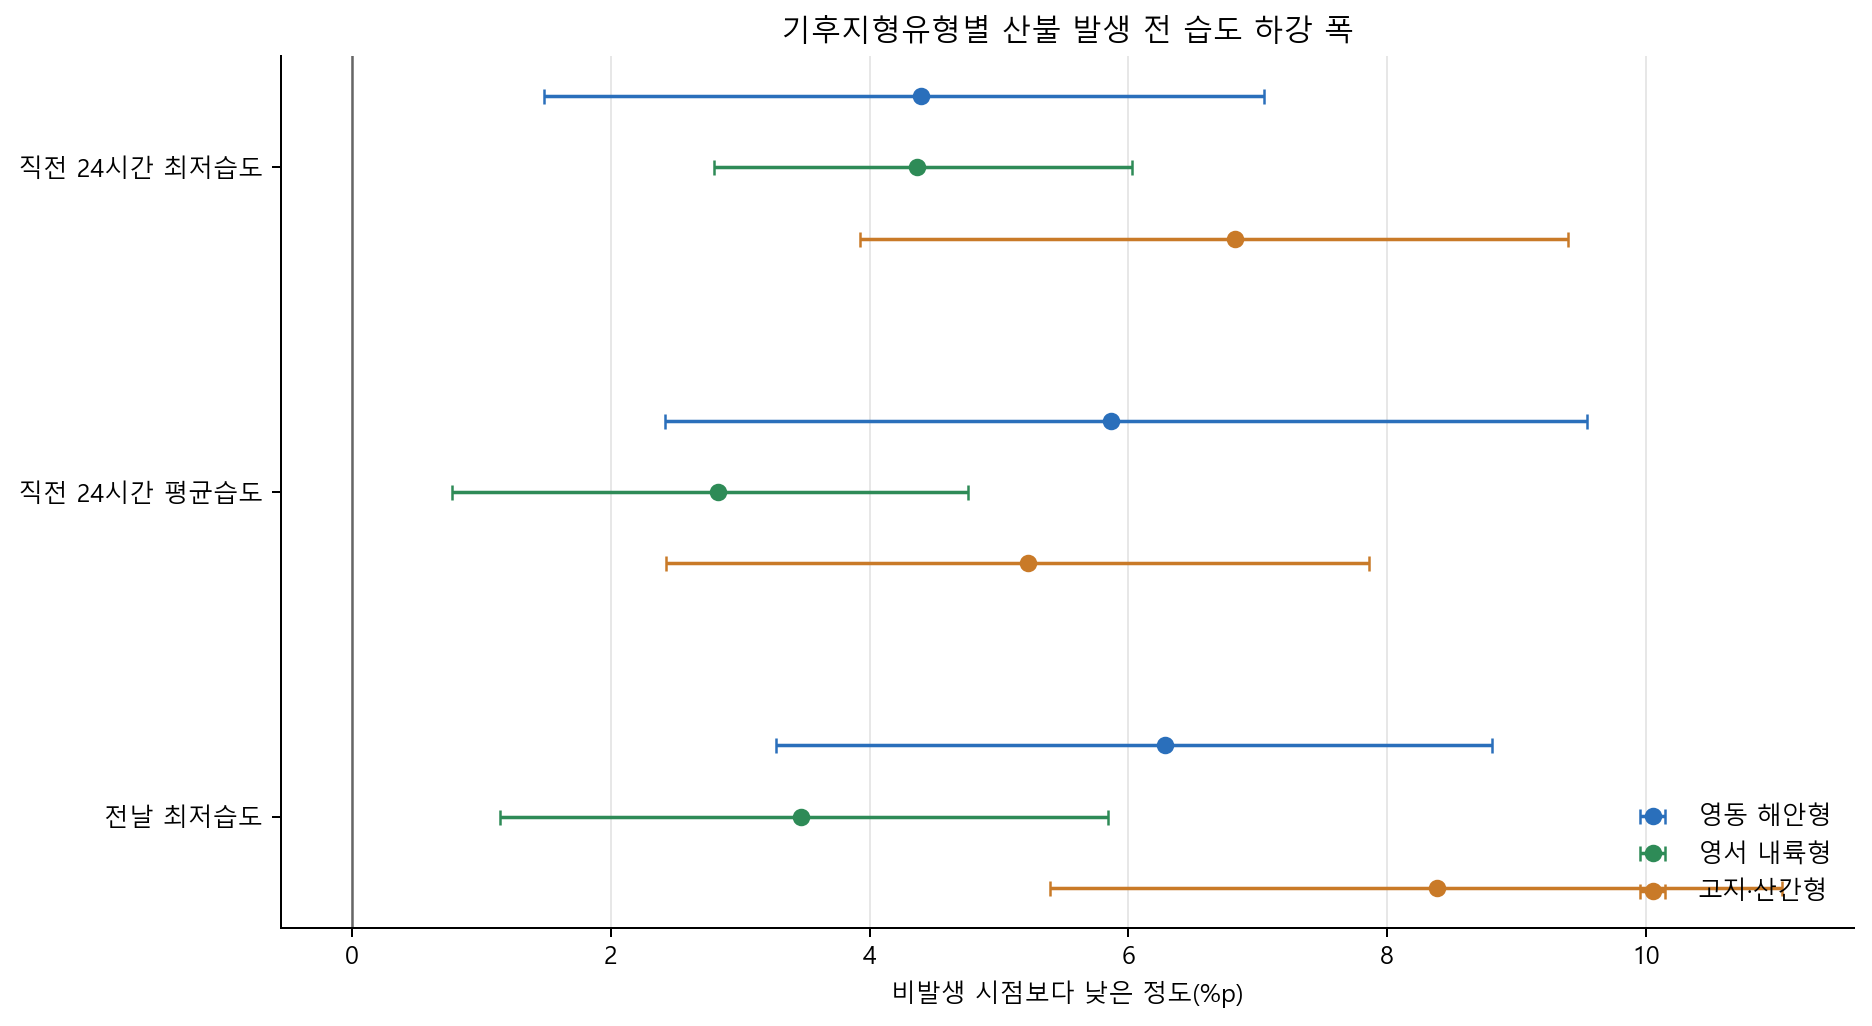

,습도 항목,기후지형유형,사건 수,산불-대조군 차이(%p),비발생보다 낮은 정도(%p),낮은 정도 95% 범위,Kruskal-Wallis 보정 p값
0,직전 24시간 최저습도,영동 해안형,354,-4.39,4.39,1.49~7.05,0.00836
1,직전 24시간 최저습도,영서 내륙형,615,-4.36,4.36,2.80~6.03,0.00836
2,직전 24시간 최저습도,고지·산간형,181,-6.83,6.83,3.93~9.40,0.00836
3,직전 24시간 평균습도,영동 해안형,354,-5.86,5.86,2.42~9.55,0.00416
4,직전 24시간 평균습도,영서 내륙형,615,-2.83,2.83,0.77~4.76,0.00416
5,직전 24시간 평균습도,고지·산간형,181,-5.22,5.22,2.43~7.86,0.00416
6,전날 최저습도,영동 해안형,353,-6.28,6.28,3.27~8.81,9.42e-06
7,전날 최저습도,영서 내륙형,615,-3.47,3.47,1.14~5.85,9.42e-06
8,전날 최저습도,고지·산간형,181,-8.39,8.39,5.40~11.06,9.42e-06


,습도항목,세 유형 차이 보정 p값,영동-영서 보정 p값,영동-고지 보정 p값,영서-고지 보정 p값
0,직전 24시간 최저습도,0.00836,0.133,0.361,0.00662
1,직전 24시간 평균습도,0.00416,0.00415,0.596,0.118
5,전날 최저습도,9.42e-06,0.000545,0.596,0.000221


,기후지형유형,산불 충족률(%),대조군 충족률(%),차이(%p),OR,보정 p값
45,영동 해안형,14.12,5.88,8.25,2.60,0.000247
63,영서 내륙형,11.22,6.99,4.23,1.67,0.00562
27,고지·산간형,9.94,6.85,3.09,1.48,0.277


In [7]:
type_test = coerce_numeric(tables["S2-09_heterogeneity_tests"])
local_threshold = coerce_numeric(tables["S3-07_threshold_performance_summary"])

type_humidity_vars = ["직전24h_최소습도", "직전24h_평균습도", "D-1_최소습도_pct"]
type_humidity_names = {
    "직전24h_최소습도": "직전 24시간 최저습도",
    "직전24h_평균습도": "직전 24시간 평균습도",
    "D-1_최소습도_pct": "전날 최저습도",
}
type_prefix = {
    "영동 해안형": "yd",
    "영서 내륙형": "ys",
    "고지·산간형": "yg",
}

rows = []
for variable in type_humidity_vars:
    row = type_test.loc[type_test["variable"] == variable].iloc[0]
    for climate_type in TYPE_ORDER:
        prefix = type_prefix[climate_type]
        mean_diff = row[f"{prefix}_mean"]
        ci_low = row[f"{prefix}_ci_lower"]
        ci_high = row[f"{prefix}_ci_upper"]
        rows.append(
            {
                "습도 항목": type_humidity_names[variable],
                "기후지형유형": climate_type,
                "사건 수": int(row[f"{prefix}_n"]),
                "산불-대조군 차이(%p)": mean_diff,
                "비발생보다 낮은 정도(%p)": -mean_diff,
                "낮은 정도 95% 하한": -ci_high,
                "낮은 정도 95% 상한": -ci_low,
                "중앙 차이(%p)": row[f"{prefix}_median"],
                "Kruskal-Wallis 보정 p값": row["kruskal_q"],
                "YD-YS 보정 p값": row["q_yd_ys"],
                "YD-YG 보정 p값": row["q_yd_yg"],
                "YS-YG 보정 p값": row["q_ys_yg"],
            }
        )

type_humidity_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=180)
y_base = np.arange(len(type_humidity_vars))
offsets = {"영동 해안형": -0.22, "영서 내륙형": 0.0, "고지·산간형": 0.22}

for climate_type in TYPE_ORDER:
    sub = type_humidity_table.loc[type_humidity_table["기후지형유형"] == climate_type].reset_index(drop=True)
    y = y_base + offsets[climate_type]
    x = sub["비발생보다 낮은 정도(%p)"]
    xerr = np.vstack([
        x - sub["낮은 정도 95% 하한"],
        sub["낮은 정도 95% 상한"] - x,
    ])
    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="o",
        color=TYPE_PALETTE[climate_type],
        ecolor=TYPE_PALETTE[climate_type],
        capsize=3,
        markersize=6,
        linewidth=1.4,
        label=climate_type,
    )

ax.axvline(0, color="#666666", linewidth=1)
ax.set_yticks(y_base)
ax.set_yticklabels([type_humidity_names[v] for v in type_humidity_vars])
ax.set_xlabel("비발생 시점보다 낮은 정도(%p)")
ax.set_title("기후지형유형별 산불 발생 전 습도 하강 폭")
ax.grid(axis="x", color="#dddddd", linewidth=0.7, alpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()

plt.show()

type_humidity_report_table = type_humidity_table.assign(
    **{
        "산불-대조군 차이(%p)": type_humidity_table["산불-대조군 차이(%p)"].round(2),
        "비발생보다 낮은 정도(%p)": type_humidity_table["비발생보다 낮은 정도(%p)"].round(2),
        "낮은 정도 95% 범위": type_humidity_table.apply(lambda r: f"{r['낮은 정도 95% 하한']:.2f}~{r['낮은 정도 95% 상한']:.2f}", axis=1),
        "Kruskal-Wallis 보정 p값": type_humidity_table["Kruskal-Wallis 보정 p값"].map(lambda v: f"{v:.3g}"),
    }
)[[
    "습도 항목",
    "기후지형유형",
    "사건 수",
    "산불-대조군 차이(%p)",
    "비발생보다 낮은 정도(%p)",
    "낮은 정도 95% 범위",
    "Kruskal-Wallis 보정 p값",
]]

pairwise_test_table = (
    type_test.loc[type_test["variable"].isin(type_humidity_vars), ["variable", "kruskal_q", "q_yd_ys", "q_yd_yg", "q_ys_yg"]]
    .assign(습도항목=lambda d: d["variable"].map(type_humidity_names))
    [["습도항목", "kruskal_q", "q_yd_ys", "q_yd_yg", "q_ys_yg"]]
    .rename(columns={
        "kruskal_q": "세 유형 차이 보정 p값",
        "q_yd_ys": "영동-영서 보정 p값",
        "q_yd_yg": "영동-고지 보정 p값",
        "q_ys_yg": "영서-고지 보정 p값",
    })
)
for col in pairwise_test_table.columns[1:]:
    pairwise_test_table[col] = pairwise_test_table[col].map(lambda v: f"{v:.3g}")

local_dryness_table = local_threshold.loc[
    (local_threshold["condition"] == "rh_local_q05")
    & (local_threshold["group"].isin(TYPE_ORDER))
].copy()
local_dryness_table["기후지형유형"] = pd.Categorical(local_dryness_table["group"], categories=TYPE_ORDER, ordered=True)
local_dryness_table = local_dryness_table.sort_values("기후지형유형").assign(
    **{
        "산불 충족률(%)": (local_dryness_table["fire_condition_rate"] * 100).round(2),
        "대조군 충족률(%)": (local_dryness_table["control_condition_rate"] * 100).round(2),
        "차이(%p)": (local_dryness_table["matched_risk_diff"] * 100).round(2),
        "OR": local_dryness_table["matched_or_approx"].round(2),
        "보정 p값": local_dryness_table["paired_t_q"].map(lambda v: f"{v:.3g}"),
    }
)[["기후지형유형", "산불 충족률(%)", "대조군 충족률(%)", "차이(%p)", "OR", "보정 p값"]]

display(type_humidity_report_table)
display(pairwise_test_table)
display(local_dryness_table)


기후지형유형별로 나누어 보아도 산불 발생 전 습도 하강은 세 유형 모두에서 확인되었다. 위의 플롯은 산불 발생 전 습도가 비발생 시점보다 얼마나 낮았는지를 양수 방향의 %p 값으로 나타낸 것이다. 모든 점이 0선의 오른쪽에 위치하고, 각 95% 범위도 대부분 0에서 충분히 떨어져 있으므로, 유형을 나누어 보더라도 산불 발생 전 습도는 대조 시점보다 낮았다고 해석할 수 있다.

직전 24시간 최저습도는 영동 해안형 354건에서 산불 발생 전이 비발생 시점보다 4.39%p 낮았고, 낮은 정도의 95% 범위는 1.49~7.05%p였다. 영서 내륙형 615건에서도 4.36%p 낮았으며, 95% 범위는 2.80~6.03%p였다. 고지·산간형 181건에서는 6.83%p 낮아 세 유형 중 하강 폭이 가장 컸고, 95% 범위도 3.93~9.40%p로 나타났다. 세 유형 간 차이에 대한 Kruskal-Wallis 보정 p값은 0.00836으로, 직전 24시간 최저습도의 하강 폭은 기후지형유형에 따라 동일하지 않다고 볼 수 있다. 사후비교에서는 영동-영서 차이는 보정 p값 0.133, 영동-고지 차이는 0.361로 뚜렷하지 않았지만, 영서-고지 차이는 0.00662로 유의하였다. 즉 직전 24시간 최저습도에서는 고지·산간형이 영서 내륙형보다 더 큰 습도 하강을 보인 것이 핵심이다.

직전 24시간 평균습도도 모든 유형에서 산불 발생 전이 낮았다. 영동 해안형은 354건에서 5.86%p 낮았고, 95% 범위는 2.42~9.55%p였다. 영서 내륙형은 615건에서 2.83%p 낮았으며, 95% 범위는 0.77~4.76%p였다. 고지·산간형은 181건에서 5.22%p 낮았고, 95% 범위는 2.43~7.86%p였다. 세 유형 차이에 대한 Kruskal-Wallis 보정 p값은 0.00416으로 유의하였다. 사후비교에서는 영동-영서 차이의 보정 p값이 0.00415로 유의했지만, 영동-고지 차이는 0.596, 영서-고지 차이는 0.118로 유의하지 않았다. 따라서 평균습도에서는 영동 해안형의 하강 폭이 영서 내륙형보다 뚜렷하게 컸고, 고지·산간형은 영동 해안형과 비슷한 수준의 큰 하강 폭을 보였다고 해석할 수 있다.

전날 최저습도에서는 유형별 차이가 가장 뚜렷했다. 영동 해안형 353건에서는 산불 발생 전이 비발생 시점보다 6.28%p 낮았고, 95% 범위는 3.27~8.81%p였다. 영서 내륙형 615건에서는 3.47%p 낮았으며, 95% 범위는 1.14~5.85%p였다. 고지·산간형 181건에서는 8.39%p 낮아 세 유형 중 가장 큰 차이를 보였고, 95% 범위도 5.40~11.06%p로 가장 높게 나타났다. 세 유형 차이에 대한 Kruskal-Wallis 보정 p값은 9.42e-06으로 매우 작아, 전날 최저습도의 하강 폭은 기후지형유형에 따라 뚜렷하게 달랐다. 사후비교에서도 영동-영서 차이는 보정 p값 0.000545, 영서-고지 차이는 0.000221로 유의했으며, 영동-고지 차이는 0.596으로 유의하지 않았다. 즉 전날 최저습도는 영서 내륙형보다 영동 해안형과 고지·산간형에서 더 크게 낮아졌고, 특히 고지·산간형의 전날 최저습도 하강이 가장 강하게 나타났다.

이 결과를 종합하면, 산불 발생 전 습도 하강은 세 기후지형유형에서 공통적으로 나타나는 현상이지만, 하강 폭의 크기는 유형별로 다르다. 영서 내륙형은 세 지표 모두에서 산불 발생 전 습도가 낮아지기는 했지만, 상대적으로 하강 폭이 작았다. 반면 고지·산간형은 직전 24시간 최저습도 6.83%p, 전날 최저습도 8.39%p로 최저습도 계열에서 가장 큰 하강을 보였다. 영동 해안형은 직전 24시간 평균습도 5.86%p, 전날 최저습도 6.28%p로 평균적인 습도 저하와 전날 건조 상태가 모두 뚜렷했다. 따라서 습도 하강은 강원도 전역의 공통적인 산불 발생 전 조건이지만, 고지·산간형에서는 최저습도 하강, 영동 해안형에서는 평균습도와 전날 최저습도 하강이 상대적으로 중요한 특징으로 나타난다.

국지적인 저습 조건 충족률을 보아도 유형별 차이가 확인된다. 영동 해안형은 산불 발생 시점의 충족률이 14.12%, 대조군 충족률이 5.88%로 차이가 8.25%p였고, OR은 2.60, 보정 p값은 0.000247이었다. 이는 영동 해안형에서 해당 저습 조건이 충족될 때 산불 발생 시점과의 관련성이 가장 강하게 나타났음을 의미한다. 영서 내륙형은 산불 충족률 11.22%, 대조군 충족률 6.99%로 차이가 4.23%p였고, OR은 1.67, 보정 p값은 0.00562였다. 영서 내륙형에서도 저습 조건은 산불 발생 시점에서 더 자주 나타났지만, 영동 해안형보다는 효과 크기가 작았다.

반면 고지·산간형은 산불 충족률 9.94%, 대조군 충족률 6.85%로 차이가 3.09%p였고, OR은 1.48이었으나 보정 p값은 0.277이었다. 즉 고지·산간형에서도 산불 시점의 충족률이 대조군보다 높기는 했지만, 이 조건만으로는 통계적으로 뚜렷한 차이라고 보기 어렵다. 앞선 결과에서 고지·산간형의 최저습도 하강 폭은 컸지만, 특정 저습 조건의 충족 여부로 단순화하면 유의성이 약해진다는 점이 중요하다. 이는 고지·산간형의 산불 전 건조 상태가 특정 임계조건의 충족 여부보다는 최저습도 자체의 하강 폭으로 더 잘 설명될 수 있음을 시사한다.

결론적으로, 습도는 전체 분석뿐 아니라 기후지형유형별 분석에서도 산불 발생 전 가장 일관된 차이를 보인 변수이다. 세 유형 모두에서 직전 24시간 최저습도, 직전 24시간 평균습도, 전날 최저습도가 비발생 시점보다 낮았고, 유형별 하강 폭의 차이도 통계적으로 확인되었다. 특히 고지·산간형은 최저습도 하강 폭이 크고, 영동 해안형은 저습 조건 충족률과 OR이 가장 높게 나타났다. 따라서 강원도 산불의 습도 조건은 단순히 전 지역에서 동일하게 작용하는 것이 아니라, 지역의 기후·지형 특성에 따라 “얼마나 낮아지는가”와 “저습 조건이 얼마나 자주 충족되는가”가 다르게 나타나는 구조로 해석할 수 있다.

#### 3-3-2. 강수량과 무강수 지속

In [15]:
from IPython.display import Markdown, display

weather_delta = coerce_numeric(tables["S2-07_weather_delta_summary"])
rain_window_summary = coerce_numeric(tables["S3-02_lead_window_delta_summary"])
rain_window_raw = coerce_numeric(tables["S3-02_lead_window_delta_raw"])
dry_spell = coerce_numeric(tables["S3-04_dry_spell_threshold_summary"])
rain_elapsed = coerce_numeric(tables["S3-04_rain_elapsed_summary"])
post_rain_proxy = coerce_numeric(tables["S3-04_post_rain_drying_proxy"])

text_cols = {
    "variable", "feature", "group", "condition", "기후지형유형", "date", "기준시각",
    "기상셀ID", "fire_exposure_id", "risk_direction", "feature_family", "support_flag",
}
for df in [weather_delta, rain_window_summary, rain_window_raw, dry_spell, rain_elapsed, post_rain_proxy]:
    for col in df.columns:
        if col not in text_cols:
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().any():
                df[col] = converted

rain_window_names = {
    "rain_sum_24h": "직전 24시간 강수량합",
    "rain_sum_48h": "직전 48시간 강수량합",
    "rain_sum_72h": "직전 72시간 강수량합",
}

def window_row(feature, group="전체"):
    return rain_window_summary.loc[
        (rain_window_summary["group"] == group)
        & (rain_window_summary["feature"] == feature)
    ].iloc[0]

def raw_medians(feature):
    part = rain_window_raw.loc[rain_window_raw["feature"] == feature].copy()
    part["fire_value"] = pd.to_numeric(part["fire_value"], errors="coerce")
    part["control_mean"] = pd.to_numeric(part["control_mean"], errors="coerce")
    return part["fire_value"].median(), part["control_mean"].median()

def weather_row(variable):
    return weather_delta.loc[weather_delta["variable"] == variable].iloc[0]

def dry_row(condition, group="전체"):
    return dry_spell.loc[
        (dry_spell["group"] == group)
        & (dry_spell["condition"] == condition)
    ].iloc[0]

def elapsed_row(feature, group="전체"):
    return rain_elapsed.loc[
        (rain_elapsed["group"] == group)
        & (rain_elapsed["feature"] == feature)
    ].iloc[0]

def signed(value, digits=2):
    return f"{value:+.{digits}f}"

# 표 1. 보고서용 강수 요약표
rain24 = window_row("rain_sum_24h")
rain72 = window_row("rain_sum_72h")
dry5 = dry_row("dry_spell_5p0_gt_240h")
elapsed5 = elapsed_row("last_rain_elapsed_h_5p0")
drying01 = elapsed_row("drying_amount_0p1")

report_rain_summary_table = pd.DataFrame([
    {
        "구분": "단기 강수 부족",
        "지표": "직전 24시간 강수량합",
        "산불 발생 전 특징": f"대조군보다 {abs(rain24['mean_delta']):.2f}mm 적음",
    },
    {
        "구분": "누적 강수 부족",
        "지표": "직전 72시간 강수량합",
        "산불 발생 전 특징": f"대조군보다 {abs(rain72['mean_delta']):.2f}mm 적음",
    },
    {
        "구분": "유효 강수 부재",
        "지표": "마지막 5mm 이상 강수 후 10일 초과",
        "산불 발생 전 특징": f"산불 {dry5['fire_condition_rate']*100:.2f}%, 대조군 {dry5['control_condition_rate']*100:.2f}%, {signed(dry5['matched_risk_diff']*100)}%p",
    },
    {
        "구분": "강수 후 재건조",
        "지표": "최근 5mm 이상 강수 후 경과시간",
        "산불 발생 전 특징": f"산불 발생 전이 평균 {elapsed5['mean_delta']:.2f}시간 더 김",
    },
    {
        "구분": "강수 후 재건조",
        "지표": "강수 이후 상대습도 하락폭",
        "산불 발생 전 특징": f"산불 {drying01['fire_mean']:.2f}%p, 대조군 {drying01['control_mean']:.2f}%p, {signed(drying01['mean_delta'])}%p",
    },
])

# 표 2. 강수량 매칭 비교 상세표
rain_detail_rows = []
for feature in ["rain_sum_24h", "rain_sum_48h", "rain_sum_72h"]:
    row = window_row(feature)
    fire_median, control_median = raw_medians(feature)
    rain_detail_rows.append({
        "항목": rain_window_names[feature],
        "산불 발생 전 평균(mm)": row["fire_mean"],
        "산불 발생 전 중앙값(mm)": fire_median,
        "비발생 시점 평균(mm)": row["control_mean"],
        "비발생 시점 중앙값(mm)": control_median,
        "평균 차이(mm, 산불-비발생)": row["mean_delta"],
        "block bootstrap 95% 하한": row["date_boot_ci_low"],
        "block bootstrap 95% 상한": row["date_boot_ci_high"],
    })

d1 = weather_row("D-1_강수량합_mm")
rain_detail_rows.append({
    "항목": "전날 강수량합",
    "산불 발생 전 평균(mm)": d1["fire_mean"],
    "산불 발생 전 중앙값(mm)": d1["fire_median"],
    "비발생 시점 평균(mm)": d1["control_mean"],
    "비발생 시점 중앙값(mm)": d1["control_median"],
    "평균 차이(mm, 산불-비발생)": d1["mean_delta"],
    "block bootstrap 95% 하한": d1["mean_delta_ci_lower"],
    "block bootstrap 95% 상한": d1["mean_delta_ci_upper"],
})
rain_matching_detail_table = pd.DataFrame(rain_detail_rows)
for col in rain_matching_detail_table.columns[1:]:
    rain_matching_detail_table[col] = rain_matching_detail_table[col].astype(float).round(2)

# 표 3. 유효 강수 부재 조건 요약표
condition_specs = [
    (
        "dry_spell_0p1_gt_24h",
        "0.1mm 이상 강수 후 24시간 초과",
        "0.1mm 이상 비가 온 뒤 24시간 넘게 지난 상태",
        "미세 강수 후 하루 넘게 지난 상태가 산불 발생 전 더 자주 나타남",
    ),
    (
        "dry_spell_5p0_gt_240h",
        "5mm 이상 강수 후 10일 초과",
        "5mm 이상 비가 온 뒤 10일 넘게 지난 상태",
        "연료를 젖힐 수 있는 비가 장기간 없었던 상태가 산불 발생 전 더 자주 나타남",
    ),
]
no_effective_rain_rows = []
for condition, label, easy_desc, memo in condition_specs:
    row = dry_row(condition)
    no_effective_rain_rows.append({
        "조건명": label,
        "쉬운 설명": easy_desc,
        "산불 발생 전 비율(%)": row["fire_condition_rate"] * 100,
        "비발생 시점 비율(%)": row["control_condition_rate"] * 100,
        "차이(%p)": row["matched_risk_diff"] * 100,
        "matched OR": row["matched_or_approx"],
        "해석 메모": memo,
    })
no_effective_rain_table = pd.DataFrame(no_effective_rain_rows)
for col in ["산불 발생 전 비율(%)", "비발생 시점 비율(%)", "차이(%p)", "matched OR"]:
    no_effective_rain_table[col] = no_effective_rain_table[col].astype(float).round(2)

# 표 4. 강수 후 재건조 요약표
post_rain_drying_table = pd.DataFrame([
    {
        "지표": "최근 5mm 이상 강수 후 경과시간",
        "산불 발생 전 평균": elapsed5["fire_mean"],
        "비발생 시점 평균": elapsed5["control_mean"],
        "차이": elapsed5["mean_delta"],
        "단위": "시간",
    },
    {
        "지표": "강수 이후 상대습도 하락폭",
        "산불 발생 전 평균": drying01["fire_mean"],
        "비발생 시점 평균": drying01["control_mean"],
        "차이": drying01["mean_delta"],
        "단위": "%p",
    },
])
for col in ["산불 발생 전 평균", "비발생 시점 평균", "차이"]:
    post_rain_drying_table[col] = post_rain_drying_table[col].astype(float).round(2)

# 표 5. 기후지형유형별 강수·재건조 요약표
interpret_labels = {
    "전체": "강수 부족보다 무강수·재건조 배경",
    "영동 해안형": "강수 후 재건조 가능성",
    "영서 내륙형": "누적 강수 부족",
    "고지·산간형": "무강수 지속과 단기 저습 동반",
}
by_type_rows = []
for group in ["전체", *TYPE_ORDER]:
    rain24_g = window_row("rain_sum_24h", group)
    rain72_g = window_row("rain_sum_72h", group)
    dry5_g = dry_row("dry_spell_5p0_gt_240h", group)
    elapsed5_g = elapsed_row("last_rain_elapsed_h_5p0", group)
    drying01_g = elapsed_row("drying_amount_0p1", group)
    by_type_rows.append({
        "기후지형유형": group,
        "직전 24시간 강수량 차이(mm)": rain24_g["mean_delta"],
        "직전 72시간 강수량 차이(mm)": rain72_g["mean_delta"],
        "5mm 이상 강수 후 10일 초과 비율: 산불(%)": dry5_g["fire_condition_rate"] * 100,
        "5mm 이상 강수 후 10일 초과 비율: 대조군(%)": dry5_g["control_condition_rate"] * 100,
        "5mm 이상 강수 후 10일 초과 차이(%p)": dry5_g["matched_risk_diff"] * 100,
        "최근 5mm 이상 강수 후 평균 경과시간 차이(시간)": elapsed5_g["mean_delta"],
        "강수 이후 상대습도 하락폭 차이(%p)": drying01_g["mean_delta"],
        "해석 라벨": interpret_labels[group],
    })
rain_by_type_summary_table = pd.DataFrame(by_type_rows)
for col in rain_by_type_summary_table.columns[1:-1]:
    rain_by_type_summary_table[col] = rain_by_type_summary_table[col].astype(float).round(2)

for title, table in [
    ("강수량 매칭 비교 상세표", rain_matching_detail_table),
    ("유효 강수 부재 조건 요약표", no_effective_rain_table),
    ("강수 후 재건조 요약표", post_rain_drying_table),
    ("기후지형유형별 강수·재건조 요약표", rain_by_type_summary_table),
]:
    display(Markdown(f"### {title}"))
    display(table)

### 강수량 매칭 비교 상세표

,항목,산불 발생 전 평균(mm),산불 발생 전 중앙값(mm),비발생 시점 평균(mm),비발생 시점 중앙값(mm),"평균 차이(mm, 산불-비발생)",block bootstrap 95% 하한,block bootstrap 95% 상한
0,직전 24시간 강수량합,0.69,0.0,1.85,0.16,-1.16,-1.76,-0.44
1,직전 48시간 강수량합,1.24,0.0,3.51,0.60,-2.27,-3.20,-1.29
2,직전 72시간 강수량합,2.32,0.0,5.32,1.08,-3.00,-4.51,-1.81
3,전날 강수량합,0.60,0.0,1.74,0.00,-1.14,-1.62,-0.69


### 유효 강수 부재 조건 요약표

,조건명,쉬운 설명,산불 발생 전 비율(%),비발생 시점 비율(%),차이(%p),matched OR,해석 메모
0,0.1mm 이상 강수 후 24시간 초과,0.1mm 이상 비가 온 뒤 24시간 넘게 지난 상태,89.91,80.68,9.23,2.13,미세 강수 후 하루 넘게 지난 상태가 산불 발생 전 더 자주 나타남
1,5mm 이상 강수 후 10일 초과,5mm 이상 비가 온 뒤 10일 넘게 지난 상태,88.43,81.69,6.75,1.71,연료를 젖힐 수 있는 비가 장기간 없었던 상태가 산불 발생 전 더 자주 나타남


### 강수 후 재건조 요약표

,지표,산불 발생 전 평균,비발생 시점 평균,차이,단위
0,최근 5mm 이상 강수 후 경과시간,586.07,553.51,32.56,시간
1,강수 이후 상대습도 하락폭,33.67,28.46,5.21,%p


### 기후지형유형별 강수·재건조 요약표

,기후지형유형,직전 24시간 강수량 차이(mm),직전 72시간 강수량 차이(mm),5mm 이상 강수 후 10일 초과 비율: 산불(%),5mm 이상 강수 후 10일 초과 비율: 대조군(%),5mm 이상 강수 후 10일 초과 차이(%p),최근 5mm 이상 강수 후 평균 경과시간 차이(시간),강수 이후 상대습도 하락폭 차이(%p),해석 라벨
0,전체,-1.16,-3.00,88.43,81.69,6.75,32.56,5.21,강수 부족보다 무강수·재건조 배경
1,영동 해안형,-0.77,-1.91,91.53,85.08,6.44,26.44,2.75,강수 후 재건조 가능성
2,영서 내륙형,-1.42,-3.74,86.18,79.19,6.99,35.63,6.97,누적 강수 부족
3,고지·산간형,-1.00,-2.64,90.06,83.54,6.52,34.11,4.08,무강수 지속과 단기 저습 동반


강수량 매칭 비교 결과, 산불 발생 전에는 같은 지역·같은 월·같은 시간대의 비발생 시점보다 최근 강수량이 전반적으로 적었다. 직전 24시간 강수량합은 산불 발생 전 평균 0.69mm, 비발생 시점 평균 1.85mm로 산불 발생 전이 1.16mm 적었다. block bootstrap 95% 범위도 -1.76~-0.44mm로 0을 지나지 않아, 직전 24시간 강수 부족이 통계적으로 확인된다. 직전 48시간 강수량합은 산불 발생 전 1.24mm, 비발생 시점 3.51mm로 2.27mm 적었고, 95% 범위는 -3.20~-1.29mm였다. 직전 72시간 강수량합은 산불 발생 전 2.32mm, 비발생 시점 5.32mm로 3.00mm 적었으며, 95% 범위는 -4.51~-1.81mm였다. 전날 강수량합도 산불 발생 전 0.60mm, 비발생 시점 1.74mm로 1.14mm 적었고, 95% 범위는 -1.62~-0.69mm였다.

중앙값을 보면 산불 발생 전 강수 부족의 특징이 더 분명하게 드러난다. 산불 발생 전 직전 24시간, 48시간, 72시간, 전날 강수량의 중앙값은 모두 0.0mm였다. 반면 비발생 시점은 직전 24시간 0.16mm, 직전 48시간 0.60mm, 직전 72시간 1.08mm로, 같은 조건의 대조 시점에서는 적은 양이라도 강수가 있었던 경우가 더 많았다. 전날 강수량 중앙값은 양쪽 모두 0.0mm였지만 평균은 산불 발생 전 0.60mm, 비발생 시점 1.74mm로 차이가 있었다. 이는 산불 발생 전에는 강수 자체가 없거나 매우 적은 상태가 많았고, 특히 48~72시간 누적 강수량에서 대조군과의 차이가 더 커졌음을 의미한다.

유효 강수 부재 조건에서도 같은 방향의 차이가 확인된다. 0.1mm 이상 강수 후 24시간이 초과된 상태는 산불 발생 전 89.91%, 비발생 시점 80.68%로 산불 발생 전이 9.23%p 높았다. matched OR은 2.13으로, 미세 강수 이후에도 하루 이상 지난 상태가 산불 발생 전 더 자주 나타났다. 5mm 이상 강수 후 10일이 초과된 상태도 산불 발생 전 88.43%, 비발생 시점 81.69%로 산불 발생 전이 6.75%p 높았고, matched OR은 1.71이었다. 5mm 이상 강수는 연료를 실제로 젖힐 수 있는 수준의 강수로 볼 수 있으므로, 산불 발생 전에는 연료 습윤에 의미 있는 강수가 장기간 없었던 조건이 더 자주 형성되었다고 해석할 수 있다.

강수 후 재건조 지표는 단순한 강수 부족을 넘어, 비가 온 뒤 다시 건조해지는 과정이 산불 발생 전 더 진행되어 있었음을 보여준다. 최근 5mm 이상 강수 후 평균 경과시간은 산불 발생 전 586.07시간, 비발생 시점 553.51시간으로 산불 발생 전이 32.56시간 더 길었다. 즉 산불 발생 전에는 의미 있는 강수 이후 평균적으로 약 1.36일 더 긴 시간이 지난 상태였다. 강수 이후 상대습도 하락폭도 산불 발생 전 33.67%p, 비발생 시점 28.46%p로 산불 발생 전이 5.21%p 더 컸다. 이는 산불 발생 전에는 단순히 비가 적게 온 것뿐 아니라, 비가 온 뒤 대기가 더 많이 건조해진 상태였음을 의미한다.

기후지형유형별로 보면 강수 부족과 재건조의 양상은 유형마다 다르게 나타났다. 전체 기준으로 직전 24시간 강수량 차이는 -1.16mm, 직전 72시간 강수량 차이는 -3.00mm였고, 5mm 이상 강수 후 10일 초과 비율은 산불 88.43%, 대조군 81.69%로 6.75%p 높았다. 최근 5mm 이상 강수 후 평균 경과시간은 산불 발생 전이 32.56시간 더 길었으며, 강수 이후 상대습도 하락폭도 5.21%p 더 컸다. 따라서 전체적으로는 “강수 부족” 자체보다 “무강수 지속과 강수 후 재건조 배경”이 산불 발생 전의 핵심 조건으로 나타난다.

영동 해안형은 직전 24시간 강수량 차이가 -0.77mm, 직전 72시간 강수량 차이가 -1.91mm로 세 유형 중 누적 강수량 차이는 상대적으로 작았다. 그러나 5mm 이상 강수 후 10일 초과 비율은 산불 발생 전 91.53%, 대조군 85.08%로 6.44%p 높았고, 최근 5mm 이상 강수 후 평균 경과시간도 산불 발생 전이 26.44시간 더 길었다. 강수 이후 상대습도 하락폭 차이는 2.75%p였다. 즉 영동 해안형은 강수량 부족의 절대 차이보다는, 강수 후 시간이 지나면서 다시 건조해지는 재건조 가능성이 산불 발생 전 조건으로 더 중요하게 나타난다.

영서 내륙형은 강수량 차이가 가장 크게 나타났다. 직전 24시간 강수량 차이는 -1.42mm, 직전 72시간 강수량 차이는 -3.74mm로 세 유형 중 가장 컸다. 5mm 이상 강수 후 10일 초과 비율은 산불 발생 전 86.18%, 대조군 79.19%로 6.99%p 높았고, 최근 5mm 이상 강수 후 평균 경과시간은 산불 발생 전이 35.63시간 더 길었다. 강수 이후 상대습도 하락폭 차이도 6.97%p로 가장 컸다. 따라서 영서 내륙형은 단기·누적 강수 부족이 가장 뚜렷하고, 강수 이후 대기가 다시 건조해지는 폭도 가장 크게 나타나는 유형으로 해석된다.

고지·산간형은 직전 24시간 강수량 차이가 -1.00mm, 직전 72시간 강수량 차이가 -2.64mm였다. 5mm 이상 강수 후 10일 초과 비율은 산불 발생 전 90.06%, 대조군 83.54%로 6.52%p 높았고, 최근 5mm 이상 강수 후 평균 경과시간은 산불 발생 전이 34.11시간 더 길었다. 강수 이후 상대습도 하락폭 차이는 4.08%p였다. 고지·산간형은 영서 내륙형만큼 누적 강수 부족 차이가 크지는 않지만, 무강수 지속 조건이 높게 나타나고 앞선 습도 분석에서 최저습도 하강도 컸기 때문에, 무강수 지속과 단기 저습이 함께 작용하는 유형으로 볼 수 있다.

종합하면, 산불 발생 전 강수 조건은 “최근에 비가 덜 왔다”는 단순한 차이로만 설명하기 어렵다. 직전 24시간, 48시간, 72시간, 전날 강수량은 모두 산불 발생 전이 비발생 시점보다 적었고, 95% 범위도 모두 0을 지나지 않았다. 동시에 0.1mm 이상 강수 후 24시간 초과 조건과 5mm 이상 강수 후 10일 초과 조건이 산불 발생 전 더 자주 나타났으며, 최근 5mm 이상 강수 후 경과시간과 강수 이후 상대습도 하락폭도 더 컸다. 따라서 산불 발생 전에는 강수량 부족, 유효 강수 부재, 강수 후 재건조가 함께 나타났고, 이 중 영서 내륙형은 누적 강수 부족, 영동 해안형은 강수 후 재건조, 고지·산간형은 무강수 지속과 단기 저습의 결합이 상대적으로 중요한 특징으로 해석된다.

##### <표 2> 대조군과 비교한 산불 발생 전 강수 조건

In [17]:
display(report_rain_summary_table)

,구분,지표,산불 발생 전 특징
0,단기 강수 부족,직전 24시간 강수량합,대조군보다 1.16mm 적음
1,누적 강수 부족,직전 72시간 강수량합,대조군보다 3.00mm 적음
2,유효 강수 부재,마지막 5mm 이상 강수 후 10일 초과,"산불 88.43%, 대조군 81.69%, +6.75%p"
3,강수 후 재건조,최근 5mm 이상 강수 후 경과시간,산불 발생 전이 평균 32.56시간 더 김
4,강수 후 재건조,강수 이후 상대습도 하락폭,"산불 33.67%p, 대조군 28.46%p, +5.21%p"


위의 표를 통해 강수량은 습도보다 직접적인 차이는 작지만, 산불 발생 전에는 단기·누적 강수 부족이 함께 나타났다는 것을 알 수 있다. 또한 산불 발생 전에는 연료를 충분히 적실 만한 유효 강수가 오래 없었던 경우가 더 많았으며, 마지막 유효 강수 이후 경과시간이 더 길고, 이후 습도도 더 크게 하락한 조건인 경향을 보여준다.

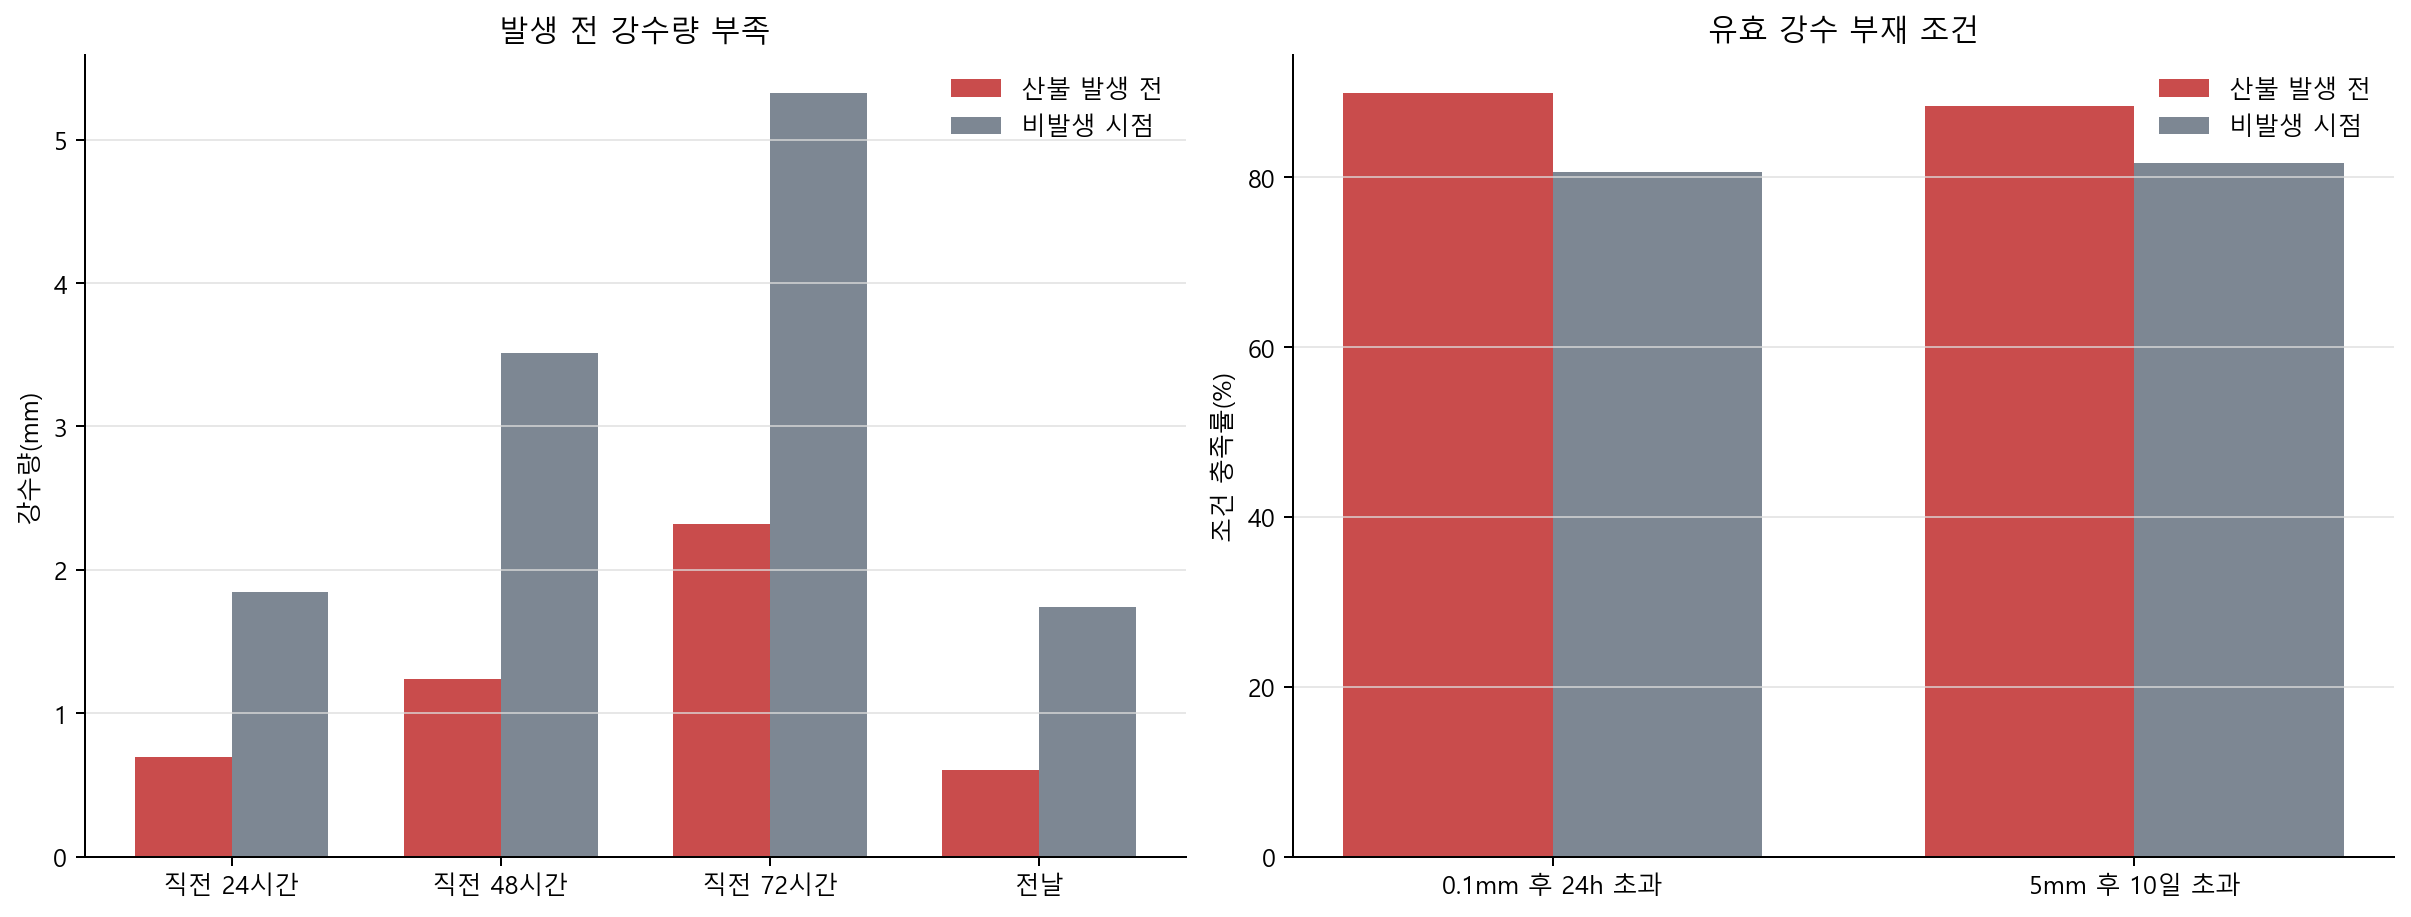

,항목,산불,비발생,차이
0,직전 24시간,0.69,1.85,-1.16
1,직전 48시간,1.24,3.51,-2.27
2,직전 72시간,2.32,5.32,-3.00
3,전날,0.60,1.74,-1.14


,조건,산불,비발생,차이
0,0.1mm 후 24h 초과,89.91,80.68,9.23
1,5mm 후 10일 초과,88.43,81.69,6.75


In [9]:
weather_delta = tables["S2-07_weather_delta_summary"]
rain_window_summary = tables["S3-02_lead_window_delta_summary"]
dry_spell = tables["S3-04_dry_spell_threshold_summary"]
rain_elapsed = tables["S3-04_rain_elapsed_summary"]

rain_features = [
    ("rain_sum_24h", "직전 24시간"),
    ("rain_sum_48h", "직전 48시간"),
    ("rain_sum_72h", "직전 72시간"),
]
rain_rows = []
for feature, label in rain_features:
    row = rain_window_summary.loc[
        (rain_window_summary["group"] == "전체") & (rain_window_summary["feature"] == feature)
    ].iloc[0]
    rain_rows.append({"항목": label, "산불": row["fire_mean"], "비발생": row["control_mean"], "차이": row["mean_delta"]})
d1 = weather_delta.loc[weather_delta["variable"] == "D-1_강수량합_mm"].iloc[0]
rain_rows.append({"항목": "전날", "산불": d1["fire_mean"], "비발생": d1["control_mean"], "차이": d1["mean_delta"]})
rain_plot = pd.DataFrame(rain_rows)

dry_conditions = [
    ("dry_spell_0p1_gt_24h", "0.1mm 후 24h 초과"),
    ("dry_spell_5p0_gt_240h", "5mm 후 10일 초과"),
]
dry_rows = []
for condition, label in dry_conditions:
    row = dry_spell.loc[(dry_spell["group"] == "전체") & (dry_spell["condition"] == condition)].iloc[0]
    dry_rows.append({"조건": label, "산불": row["fire_condition_rate"] * 100, "비발생": row["control_condition_rate"] * 100, "차이": row["matched_risk_diff"] * 100})
dry_plot = pd.DataFrame(dry_rows)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), dpi=180)
x = np.arange(len(rain_plot))
width = 0.36
axes[0].bar(x - width / 2, rain_plot["산불"], width, color="#C94C4C", label="산불 발생 전")
axes[0].bar(x + width / 2, rain_plot["비발생"], width, color="#7D8793", label="비발생 시점")
axes[0].set_xticks(x)
axes[0].set_xticklabels(rain_plot["항목"])
axes[0].set_ylabel("강수량(mm)")
axes[0].set_title("발생 전 강수량 부족")
axes[0].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
axes[0].legend(frameon=False)

x2 = np.arange(len(dry_plot))
axes[1].bar(x2 - width / 2, dry_plot["산불"], width, color="#C94C4C", label="산불 발생 전")
axes[1].bar(x2 + width / 2, dry_plot["비발생"], width, color="#7D8793", label="비발생 시점")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(dry_plot["조건"])
axes[1].set_ylabel("조건 충족률(%)")
axes[1].set_title("유효 강수 부재 조건")
axes[1].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

plt.show()

display(rain_plot.round(2))
display(dry_plot.round(2))

위의 플롯은 산불 발생 전 강수량 부족과 유효 강수 부재 조건을 같은 지역·같은 월·같은 시간대의 비발생 시점과 비교한 결과이다. 왼쪽 그래프는 직전 24시간, 48시간, 72시간, 전날의 누적 강수량을 비교한 것이고, 오른쪽 그래프는 일정 수준 이상의 강수가 발생한 뒤 충분한 시간이 지난 상태가 산불 발생 전과 비발생 시점에서 얼마나 자주 나타났는지를 비교한 것이다.

먼저 강수량을 보면, 모든 시간 창에서 산불 발생 전 강수량이 비발생 시점보다 적었다. 직전 24시간 강수량은 산불 발생 전 0.69mm, 비발생 시점 1.85mm로 산불 발생 전이 1.16mm 적었다. 직전 48시간은 산불 발생 전 1.24mm, 비발생 시점 3.51mm로 2.27mm 적었고, 직전 72시간은 산불 발생 전 2.32mm, 비발생 시점 5.32mm로 3.00mm 적었다. 전날 강수량도 산불 발생 전 0.60mm, 비발생 시점 1.74mm로 1.14mm 적었다.

이 중 차이가 가장 큰 항목은 직전 72시간 강수량이었다. 직전 24시간 차이는 -1.16mm였지만, 직전 48시간에서는 -2.27mm, 직전 72시간에서는 -3.00mm로 차이가 커졌다. 이는 산불 발생 전의 강수 부족이 단순히 발생 직전 하루에만 나타난 것이 아니라, 최소 2~3일 전부터 누적된 강수 부족 상태와 관련되어 있음을 보여준다. 또한 전날 강수량도 -1.14mm 차이를 보였으므로, 산불 발생 전날에도 비발생 시점보다 강수가 적은 조건이 확인된다.

상세표의 block bootstrap 95% 범위도 이 해석을 뒷받침한다. 직전 24시간 강수량 차이의 95% 범위는 -1.76~-0.44mm, 직전 48시간은 -3.20~-1.29mm, 직전 72시간은 -4.51~-1.81mm, 전날은 -1.62~-0.69mm였다. 네 항목 모두 95% 범위가 0을 지나지 않으므로, 산불 발생 전 강수량이 비발생 시점보다 적다는 결과는 우연한 평균 차이로 보기 어렵다.

오른쪽 그래프의 유효 강수 부재 조건도 산불 발생 전 건조 배경을 보여준다. 0.1mm 이상 강수 후 24시간이 초과된 상태는 산불 발생 전 89.91%, 비발생 시점 80.68%로 산불 발생 전이 9.23%p 높았다. 이는 아주 적은 비라도 내린 뒤 하루 이상 지난 상태가 산불 발생 전 더 자주 나타났다는 의미이다. 즉 산불 발생 전에는 최근에 미세한 강수가 있었더라도 그 효과가 이미 약해졌을 가능성이 크다.

5mm 이상 강수 후 10일이 초과된 상태도 산불 발생 전 88.43%, 비발생 시점 81.69%로 산불 발생 전이 6.75%p 높았다. 5mm 이상 강수는 연료를 실제로 적실 수 있는 수준의 강수로 볼 수 있는데, 이 강수 이후 10일 이상 지난 상태가 산불 발생 전 더 자주 나타났다는 것은 산불 발생 전에는 연료 습윤에 의미 있는 강수가 장기간 없었던 경우가 많았음을 의미한다.

따라서 이 결과는 산불 발생 전 조건을 단순히 “당일 비가 적었다”로만 설명하기 어렵다는 점을 보여준다. 산불 발생 전에는 직전 24시간, 48시간, 72시간, 전날 강수량이 모두 비발생 시점보다 적었고, 동시에 0.1mm 이상 강수 후 24시간 초과 조건과 5mm 이상 강수 후 10일 초과 조건도 더 자주 나타났다. 즉 산불 발생 전에는 단기 강수 부족과 함께, 유효한 강수가 일정 기간 없었던 무강수 지속 상태가 결합되어 있었다고 해석할 수 있다.

종합하면, 강수 관련 변수는 산불 발생 전의 건조 배경을 설명하는 핵심 지표이다. 특히 직전 72시간 강수량 차이가 -3.00mm로 가장 크게 나타난 점은 산불 발생이 발생 직전의 순간적인 무강수만이 아니라, 며칠 동안 누적된 강수 부족과 관련되어 있음을 시사한다. 또한 유효 강수 부재 조건의 충족률이 산불 발생 전 89.91%와 88.43%로 매우 높게 나타난 점을 고려하면, 강원도 산불은 최근 강수가 적고, 의미 있는 강수 이후 충분한 시간이 지나 연료와 대기가 다시 건조해진 조건에서 더 잘 발생한 것으로 해석할 수 있다.

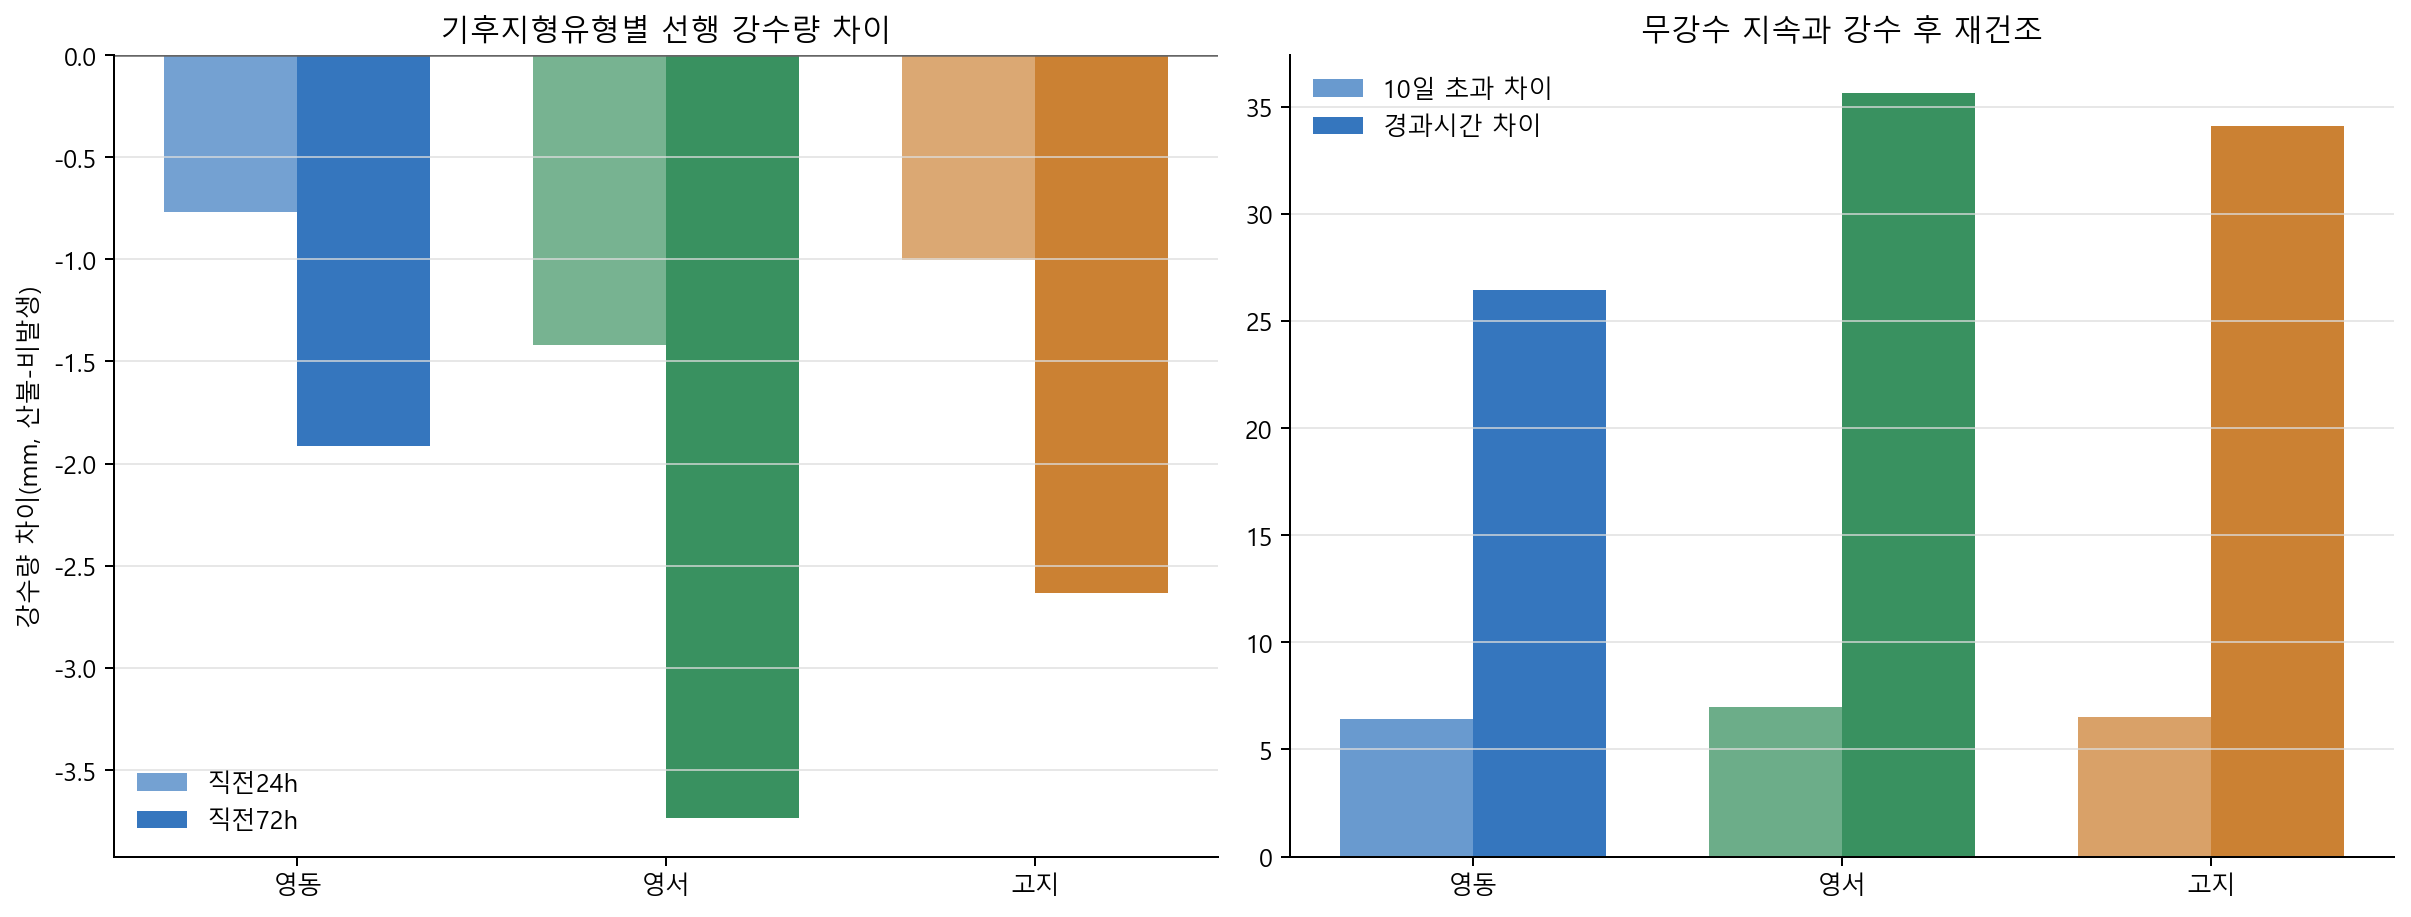

,기후지형유형,직전24h 강수 차이(mm),직전72h 강수 차이(mm),5mm 강수 후 10일 초과 차이(%p),5mm 강수 후 경과시간 차이(h)
0,영동 해안형,-0.77,-1.91,6.44,26.44
1,영서 내륙형,-1.42,-3.74,6.99,35.63
2,고지·산간형,-1.00,-2.64,6.52,34.11


In [10]:
rain_rows = []
for group in TYPE_ORDER:
    r24 = rain_window_summary.loc[(rain_window_summary["group"] == group) & (rain_window_summary["feature"] == "rain_sum_24h")].iloc[0]
    r72 = rain_window_summary.loc[(rain_window_summary["group"] == group) & (rain_window_summary["feature"] == "rain_sum_72h")].iloc[0]
    d5 = dry_spell.loc[(dry_spell["group"] == group) & (dry_spell["condition"] == "dry_spell_5p0_gt_240h")].iloc[0]
    e5 = rain_elapsed.loc[(rain_elapsed["group"] == group) & (rain_elapsed["feature"] == "last_rain_elapsed_h_5p0")].iloc[0]
    rain_rows.append(
        {
            "기후지형유형": group,
            "직전24h 강수 차이(mm)": r24["mean_delta"],
            "직전72h 강수 차이(mm)": r72["mean_delta"],
            "5mm 강수 후 10일 초과 차이(%p)": d5["matched_risk_diff"] * 100,
            "5mm 강수 후 경과시간 차이(h)": e5["mean_delta"],
        }
    )
rain_type = pd.DataFrame(rain_rows)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), dpi=180)
x = np.arange(len(TYPE_ORDER))
bar_colors = [TYPE_PALETTE[t] for t in TYPE_ORDER]

axes[0].bar(x - 0.18, rain_type["직전24h 강수 차이(mm)"], 0.36, color=bar_colors, alpha=0.65, label="직전24h")
axes[0].bar(x + 0.18, rain_type["직전72h 강수 차이(mm)"], 0.36, color=bar_colors, alpha=0.95, label="직전72h")
axes[0].axhline(0, color="#666666", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["영동", "영서", "고지"])
axes[0].set_ylabel("강수량 차이(mm, 산불-비발생)")
axes[0].set_title("기후지형유형별 선행 강수량 차이")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)

axes[1].bar(x - 0.18, rain_type["5mm 강수 후 10일 초과 차이(%p)"], 0.36, color=bar_colors, alpha=0.7, label="10일 초과 차이")
axes[1].bar(x + 0.18, rain_type["5mm 강수 후 경과시간 차이(h)"], 0.36, color=bar_colors, alpha=0.95, label="경과시간 차이")
axes[1].axhline(0, color="#666666", linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["영동", "영서", "고지"])
axes[1].set_title("무강수 지속과 강수 후 재건조")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

plt.show()

display(rain_type.round(2))

기후지형유형별로 보면, 산불 발생 전 강수 부족은 세 유형 모두에서 나타났지만 그 크기와 성격은 달랐다. 왼쪽 그래프는 산불 발생 전 강수량에서 비발생 시점 강수량을 뺀 값이므로, 막대가 0보다 아래로 내려갈수록 산불 발생 전 강수량이 더 적었다는 의미이다. 세 유형 모두 직전 24시간과 직전 72시간 강수량 차이가 음수로 나타나, 산불 발생 전에는 대조 시점보다 선행 강수량이 적었다.

영동 해안형은 직전 24시간 강수량이 비발생 시점보다 0.77mm 적었고, 직전 72시간 강수량은 1.91mm 적었다. 세 유형 중 강수량 차이는 가장 작았다. 그러나 5mm 이상 강수 후 10일이 초과된 비율은 산불 발생 전이 비발생 시점보다 6.44%p 높았고, 최근 5mm 이상 강수 후 경과시간도 산불 발생 전이 26.44시간 더 길었다. 즉 영동 해안형은 직전 강수량 자체의 부족 폭은 상대적으로 작지만, 의미 있는 강수가 온 뒤 시간이 더 지나 재건조가 진행된 상태가 산불 발생 전 더 자주 나타난다.

영서 내륙형은 강수량 부족이 가장 뚜렷했다. 직전 24시간 강수량은 산불 발생 전이 비발생 시점보다 1.42mm 적었고, 직전 72시간 강수량은 3.74mm 적었다. 이는 세 유형 중 가장 큰 차이이다. 또한 5mm 이상 강수 후 10일 초과 비율도 산불 발생 전이 6.99%p 높았고, 5mm 이상 강수 후 경과시간은 35.63시간 더 길었다. 따라서 영서 내륙형은 단기 강수 부족과 72시간 누적 강수 부족이 모두 가장 강하게 나타나며, 의미 있는 강수 이후의 무강수 지속 시간도 가장 길었다. 이 유형에서는 “비가 적게 온 상태”와 “비가 온 뒤 오래 지난 상태”가 동시에 산불 발생 전 조건으로 작용한 것으로 해석할 수 있다.

고지·산간형도 산불 발생 전 강수량이 대조 시점보다 적었다. 직전 24시간 강수량은 1.00mm 적었고, 직전 72시간 강수량은 2.64mm 적었다. 강수량 부족 폭은 영서 내륙형보다는 작지만 영동 해안형보다는 컸다. 5mm 이상 강수 후 10일 초과 비율은 산불 발생 전이 6.52%p 높았고, 5mm 이상 강수 후 경과시간은 34.11시간 더 길었다. 즉 고지·산간형은 누적 강수 부족이 중간 수준으로 나타나면서도, 유효 강수 이후 시간이 상당히 더 길어진 상태가 산불 발생 전 특징으로 확인된다.

오른쪽 그래프는 강수량의 절대 부족보다 “유효 강수 이후 얼마나 오래 지났는가”를 보여준다. 세 유형 모두 5mm 이상 강수 후 10일 초과 비율이 산불 발생 전 더 높았으며, 차이는 영동 해안형 6.44%p, 영서 내륙형 6.99%p, 고지·산간형 6.52%p로 서로 비슷한 수준이었다. 이는 유형과 관계없이 산불 발생 전에는 연료를 적실 수 있는 수준의 강수 이후 10일 이상 지난 상태가 더 자주 나타났다는 뜻이다.

반면 5mm 이상 강수 후 경과시간 차이는 유형별로 차이가 있었다. 영동 해안형은 26.44시간으로 가장 작았고, 영서 내륙형은 35.63시간으로 가장 컸으며, 고지·산간형은 34.11시간으로 영서 내륙형과 비슷하게 높았다. 따라서 영서 내륙형과 고지·산간형은 산불 발생 전 의미 있는 강수 이후의 시간이 하루 이상 더 길어진 경향이 뚜렷했고, 영동 해안형은 그 차이가 상대적으로 작았다.

종합하면, 세 기후지형유형 모두 산불 발생 전에는 비발생 시점보다 강수량이 적고 유효 강수 이후 시간이 더 길었다. 다만 유형별 핵심은 다르다. 영동 해안형은 직전 강수량 부족 폭은 작지만 유효 강수 부재 조건이 높게 나타나 강수 후 재건조 가능성이 중요하다. 영서 내륙형은 직전 24시간 -1.42mm, 직전 72시간 -3.74mm로 강수 부족이 가장 뚜렷하고, 경과시간 차이도 35.63시간으로 가장 커 누적 강수 부족과 무강수 지속이 함께 강하게 나타난다. 고지·산간형은 직전 72시간 -2.64mm와 경과시간 차이 34.11시간을 보여, 강수 부족과 무강수 지속이 함께 나타나며 앞선 습도 분석의 단기 저습 조건과 결합해 산불 발생 전 건조 배경을 형성한 것으로 해석할 수 있다.

#### 3-3-3. 풍속과 풍향

In [19]:
from IPython.display import Markdown, display

wind_duration = coerce_numeric(tables["S3-05_wind_duration_summary"])
wind_direction = coerce_numeric(tables["S3-05_wind_direction_condition_summary"])
compound_condition = coerce_numeric(tables["S3-08_compound_condition_summary"])
humidity_type = coerce_numeric(tables["S2-09_heterogeneity_tests"])

text_cols = {"group", "feature", "condition", "support_flag", "variable"}
for df in [wind_duration, wind_direction, compound_condition, humidity_type]:
    for col in df.columns:
        if col not in text_cols:
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().any():
                df[col] = converted

wind_feature_names = {
    "wind_mean_24h": "직전 24시간 평균풍속",
    "wind_max_24h": "직전 24시간 최대풍속",
    "wind_mean_6h": "직전 6시간 평균풍속",
    "wind_max_6h": "직전 6시간 최대풍속",
    "wind_duration_3m_s": "풍속 3m/s 이상 지속시간",
}
wind_feature_order = ["wind_mean_24h", "wind_max_24h", "wind_mean_6h", "wind_max_6h", "wind_duration_3m_s"]

def wind_row(feature, group="전체"):
    return wind_duration.loc[
        (wind_duration["group"] == group)
        & (wind_duration["feature"] == feature)
    ].iloc[0]

def direction_row(condition, group):
    return wind_direction.loc[
        (wind_direction["group"] == group)
        & (wind_direction["condition"] == condition)
    ].iloc[0]

def compound_row(condition, group):
    return compound_condition.loc[
        (compound_condition["group"] == group)
        & (compound_condition["condition"] == condition)
    ].iloc[0]

def humidity_delta(variable, prefix):
    row = humidity_type.loc[humidity_type["variable"] == variable].iloc[0]
    return row[f"{prefix}_mean"]

def fmt_signed(value, digits=2):
    return f"{value:+.{digits}f}"

def rate_pct(value):
    return value * 100

def ci_memo(low, high, positive_label="일부 시간창에서 양의 신호", weak_label="전체 공통 신호 약함"):
    if low > 0:
        return positive_label
    if high < 0:
        return "산불 발생 전이 더 낮음"
    return weak_label

# 표 1. 전체 풍속 매칭 비교 요약표
wind_overall_rows = []
for feature in wind_feature_order:
    row = wind_row(feature, "전체")
    wind_overall_rows.append({
        "항목": wind_feature_names[feature],
        "산불 발생 전 평균": row["fire_mean"],
        "비발생 시점 평균": row["control_mean"],
        "평균 차이, 산불-비발생": row["mean_delta"],
        "block bootstrap 95% 하한": row["date_boot_ci_low"],
        "block bootstrap 95% 상한": row["date_boot_ci_high"],
        "산불 쪽이 더 높았던 사건 비율(%)": row["direction_match_pct"],
        "해석 메모": ci_memo(row["date_boot_ci_low"], row["date_boot_ci_high"]),
    })
wind_overall_table = pd.DataFrame(wind_overall_rows)
for col in wind_overall_table.columns[1:7]:
    wind_overall_table[col] = wind_overall_table[col].astype(float).round(2)

# 표 2. 기후지형유형별 풍속 차이 요약표
wind_type_labels = {
    "전체": "풍속 단독 신호 약함",
    "영동 해안형": "풍속 상승 뚜렷",
    "영서 내륙형": "강풍보다 누적 건조",
    "고지·산간형": "풍속보다 단기 저습",
}
wind_type_rows = []
for group in ["전체", *TYPE_ORDER]:
    wind_type_rows.append({
        "기후지형유형": group,
        "직전 24시간 평균풍속 차이(m/s)": wind_row("wind_mean_24h", group)["mean_delta"],
        "직전 24시간 최대풍속 차이(m/s)": wind_row("wind_max_24h", group)["mean_delta"],
        "직전 6시간 평균풍속 차이(m/s)": wind_row("wind_mean_6h", group)["mean_delta"],
        "직전 6시간 최대풍속 차이(m/s)": wind_row("wind_max_6h", group)["mean_delta"],
        "풍속 3m/s 이상 지속시간 차이(시간)": wind_row("wind_duration_3m_s", group)["mean_delta"],
        "해석 라벨": wind_type_labels[group],
    })
wind_by_type_table = pd.DataFrame(wind_type_rows)
for col in wind_by_type_table.columns[1:-1]:
    wind_by_type_table[col] = wind_by_type_table[col].astype(float).round(2)

# 표 3. 영동 해안형 서풍계열 강풍 조건표
direction_specs = [
    ("영동 해안형", "westerly_strong_current_3m_s", "현재 서풍계열이면서 풍속 3m/s 이상", "영동 해안형에서 산불 발생 전 더 자주 나타남"),
    ("영동 해안형", "westerly_strong_max_24h", "직전 24시간 내 최대풍속 시점이 서풍계열", "영동 해안형에서 산불 발생 전 더 자주 나타남"),
    ("영동 겨울", "westerly_strong_current_3m_s", "겨울 영동: 현재 서풍계열이면서 풍속 3m/s 이상", "겨울 영동에서 차이가 더 커짐"),
    ("영동 겨울", "westerly_strong_max_24h", "겨울 영동: 직전 24시간 내 최대풍속 시점이 서풍계열", "겨울 영동에서 차이가 더 커짐"),
]
wind_direction_rows = []
for group, condition, label, memo in direction_specs:
    row = direction_row(condition, group)
    wind_direction_rows.append({
        "조건": label,
        "산불 발생 전 비율(%)": rate_pct(row["fire_condition_rate"]),
        "비발생 시점 비율(%)": rate_pct(row["control_condition_rate"]),
        "차이(%p)": rate_pct(row["matched_risk_diff"]),
        "matched OR": row["matched_or_approx"],
        "해석 메모": memo,
    })
wind_direction_condition_table = pd.DataFrame(wind_direction_rows)
for col in wind_direction_condition_table.columns[1:5]:
    wind_direction_condition_table[col] = wind_direction_condition_table[col].astype(float).round(2)

# 표 4. 저습×강풍 결합 조건표
compound_specs = [
    ("전체", "rh_local_q05_AND_wind_max_6h_ge_5", "rh_local_q05_AND_wind_max_6h_ge_5", "전체", "국지 저습과 6시간 최대풍속이 결합할 때 양의 신호"),
    ("전체", "rh_local_q05_AND_westerly_strong_max_6h", "rh_local_q05_AND_westerly_strong_max_6h", "전체", "국지 저습과 서풍계열 강풍 결합 조건"),
    ("영동 해안형", "rh_local_q05_AND_westerly_strong_max_6h", "rh_local_q05_AND_westerly_strong_max_6h", "영동 해안형", "영동 해안형의 저습·서풍계열 강풍 프록시"),
]
compound_rows = []
for group, condition, label, target, memo in compound_specs:
    row = compound_row(condition, group)
    compound_rows.append({
        "조건": label,
        "적용 대상": target,
        "산불 발생 전 비율(%)": rate_pct(row["fire_condition_rate"]),
        "비발생 시점 비율(%)": rate_pct(row["control_condition_rate"]),
        "차이(%p)": rate_pct(row["matched_risk_diff"]),
        "matched OR": row["matched_or_approx"],
        "해석 메모": memo,
    })
wind_humidity_compound_table = pd.DataFrame(compound_rows)
for col in wind_humidity_compound_table.columns[2:6]:
    wind_humidity_compound_table[col] = wind_humidity_compound_table[col].astype(float).round(2)

# 표 5. 보고서용 풍속 요약표
whole_wind = wind_row("wind_mean_24h", "전체")
yd_wind_mean = wind_row("wind_mean_24h", "영동 해안형")
yd_wind_max = wind_row("wind_max_24h", "영동 해안형")
yd_westerly = direction_row("westerly_strong_current_3m_s", "영동 해안형")
ys_wind_mean = wind_row("wind_mean_24h", "영서 내륙형")
ys_wind_max = wind_row("wind_max_24h", "영서 내륙형")
yg_hum24 = humidity_delta("직전24h_최소습도", "yg")
yg_humd1 = humidity_delta("D-1_최소습도_pct", "yg")
combo = compound_row("rh_local_q05_AND_wind_max_6h_ge_5", "전체")

report_wind_summary_table = pd.DataFrame([
    {
        "구분": "전체",
        "핵심 지표": "직전 24시간 평균풍속",
        "산불 발생 전 특징": f"대조군보다 {fmt_signed(whole_wind['mean_delta'])}m/s, CI {fmt_signed(whole_wind['date_boot_ci_low'])}~{fmt_signed(whole_wind['date_boot_ci_high'])}"
    },
    {
        "구분": "영동 해안형",
        "핵심 지표": "직전 24시간 평균·최대풍속",
        "산불 발생 전 특징": f"평균풍속 {fmt_signed(yd_wind_mean['mean_delta'])}m/s, 최대풍속 {fmt_signed(yd_wind_max['mean_delta'])}m/s"
    },
    {
        "구분": "영동 해안형",
        "핵심 지표": "서풍계열 강풍 조건",
        "산불 발생 전 특징": f"산불 {rate_pct(yd_westerly['fire_condition_rate']):.2f}%, 대조군 {rate_pct(yd_westerly['control_condition_rate']):.2f}%, {fmt_signed(rate_pct(yd_westerly['matched_risk_diff']))}%p, OR {yd_westerly['matched_or_approx']:.2f}"
    },
    {
        "구분": "영서 내륙형",
        "핵심 지표": "풍속 차이",
        "산불 발생 전 특징": f"24h 평균풍속 {fmt_signed(ys_wind_mean['mean_delta'])}m/s, 24h 최대풍속 {fmt_signed(ys_wind_max['mean_delta'])}m/s"
    },
    {
        "구분": "고지·산간형",
        "핵심 지표": "최소습도 하강",
        "산불 발생 전 특징": f"직전24h 최소습도 {fmt_signed(yg_hum24)}%p, 전날 최소습도 {fmt_signed(yg_humd1)}%p"
    },
    {
        "구분": "저습×강풍",
        "핵심 지표": "rh_local_q05_AND_wind_max_6h_ge_5",
        "산불 발생 전 특징": f"산불 {rate_pct(combo['fire_condition_rate']):.2f}%, 대조군 {rate_pct(combo['control_condition_rate']):.2f}%, OR {combo['matched_or_approx']:.2f}"
    },
])

for title, table in [
    ("전체 풍속 매칭 비교 요약표", wind_overall_table),
    ("기후지형유형별 풍속 차이 요약표", wind_by_type_table),
    ("영동 해안형 서풍계열 강풍 조건표", wind_direction_condition_table),
    ("저습×강풍 결합 조건표", wind_humidity_compound_table),
]:
    display(Markdown(f"### {title}"))
    display(table)


### 전체 풍속 매칭 비교 요약표

,항목,산불 발생 전 평균,비발생 시점 평균,"평균 차이, 산불-비발생",block bootstrap 95% 하한,block bootstrap 95% 상한,산불 쪽이 더 높았던 사건 비율(%),해석 메모
0,직전 24시간 평균풍속,2.08,1.97,0.11,-0.05,0.28,48.61,전체 공통 신호 약함
1,직전 24시간 최대풍속,4.12,4.01,0.11,-0.09,0.30,51.04,전체 공통 신호 약함
2,직전 6시간 평균풍속,2.13,2.01,0.12,-0.03,0.27,47.22,전체 공통 신호 약함
3,직전 6시간 최대풍속,3.01,2.86,0.14,-0.04,0.36,50.61,전체 공통 신호 약함
4,풍속 3m/s 이상 지속시간,18.65,18.89,-0.24,-11.75,8.21,22.09,전체 공통 신호 약함


### 기후지형유형별 풍속 차이 요약표

,기후지형유형,직전 24시간 평균풍속 차이(m/s),직전 24시간 최대풍속 차이(m/s),직전 6시간 평균풍속 차이(m/s),직전 6시간 최대풍속 차이(m/s),풍속 3m/s 이상 지속시간 차이(시간),해석 라벨
0,전체,0.11,0.11,0.12,0.14,-0.24,풍속 단독 신호 약함
1,영동 해안형,0.36,0.49,0.40,0.49,-0.61,풍속 상승 뚜렷
2,영서 내륙형,-0.02,-0.06,-0.02,-0.00,-0.02,강풍보다 누적 건조
3,고지·산간형,0.07,-0.06,0.02,-0.05,-0.31,풍속보다 단기 저습


### 영동 해안형 서풍계열 강풍 조건표

,조건,산불 발생 전 비율(%),비발생 시점 비율(%),차이(%p),matched OR,해석 메모
0,현재 서풍계열이면서 풍속 3m/s 이상,29.10,19.15,9.94,1.73,영동 해안형에서 산불 발생 전 더 자주 나타남
1,직전 24시간 내 최대풍속 시점이 서풍계열,50.28,38.59,11.69,1.61,영동 해안형에서 산불 발생 전 더 자주 나타남
2,겨울 영동: 현재 서풍계열이면서 풍속 3m/s 이상,40.72,24.23,16.49,2.14,겨울 영동에서 차이가 더 커짐
3,겨울 영동: 직전 24시간 내 최대풍속 시점이 서풍계열,63.40,45.05,18.35,2.10,겨울 영동에서 차이가 더 커짐


### 저습×강풍 결합 조건표

,조건,적용 대상,산불 발생 전 비율(%),비발생 시점 비율(%),차이(%p),matched OR,해석 메모
0,rh_local_q05_AND_wind_max_6h_ge_5,전체,2.43,0.90,1.53,2.66,국지 저습과 6시간 최대풍속이 결합할 때 양의 신호
1,rh_local_q05_AND_westerly_strong_max_6h,전체,1.74,0.63,1.11,2.69,국지 저습과 서풍계열 강풍 결합 조건
2,rh_local_q05_AND_westerly_strong_max_6h,영동 해안형,4.24,1.36,2.88,3.01,영동 해안형의 저습·서풍계열 강풍 프록시


전체 풍속 매칭 비교에서는 풍속 단독 지표의 차이가 크지 않았다. 직전 24시간 평균풍속은 산불 발생 전 2.08m/s, 비발생 시점 1.97m/s로 산불 발생 전이 0.11m/s 높았지만, block bootstrap 95% 범위가 -0.05~0.28m/s로 0을 포함하였다. 직전 24시간 최대풍속도 산불 발생 전 4.12m/s, 비발생 시점 4.01m/s로 0.11m/s 높았으나, 95% 범위는 -0.09~0.30m/s였다. 직전 6시간 평균풍속은 산불 발생 전 2.13m/s, 비발생 시점 2.01m/s로 0.12m/s 높았고, 95% 범위는 -0.03~0.27m/s였다. 직전 6시간 최대풍속도 산불 발생 전 3.01m/s, 비발생 시점 2.86m/s로 0.14m/s 높았지만, 95% 범위는 -0.04~0.36m/s였다. 네 지표 모두 평균 차이는 양수였지만 95% 범위가 0을 지나므로, 강원도 전체에서 풍속 단독 효과가 안정적으로 확인된다고 보기는 어렵다.

산불 쪽이 더 높았던 사건 비율도 전체 풍속 신호가 약하다는 점을 보여준다. 직전 24시간 평균풍속은 산불 쪽이 더 높았던 사건 비율이 48.61%였고, 직전 24시간 최대풍속은 51.04%였다. 직전 6시간 평균풍속은 47.22%, 직전 6시간 최대풍속은 50.61%였다. 모두 50% 안팎에 머물러 있어, 전체 산불 사건에서 산불 발생 전 풍속이 대조군보다 일관되게 높았다고 보기 어렵다. 풍속 3m/s 이상 지속시간도 산불 발생 전 18.65시간, 비발생 시점 18.89시간으로 오히려 -0.24시간 낮았고, 95% 범위가 -11.75~8.21시간으로 매우 넓었다. 따라서 풍속은 전체 평균 기준으로는 습도나 강수처럼 일관된 공통 신호를 보이지 않았다.

그러나 기후지형유형별로 나누면 해석이 달라진다. 영동 해안형에서는 풍속 상승이 비교적 뚜렷했다. 직전 24시간 평균풍속 차이는 +0.36m/s, 직전 24시간 최대풍속 차이는 +0.49m/s였고, 직전 6시간 평균풍속 차이는 +0.40m/s, 직전 6시간 최대풍속 차이도 +0.49m/s였다. 반면 풍속 3m/s 이상 지속시간 차이는 -0.61시간으로 길게 지속된 강풍보다는, 발생 전 단기 평균풍속과 최대풍속이 높아지는 양상이 더 중요하게 나타났다. 즉 영동 해안형에서는 산불 발생 전 풍속 자체의 상승이 다른 유형보다 분명하게 관찰된다.

영서 내륙형과 고지·산간형에서는 풍속 차이가 거의 나타나지 않았다. 영서 내륙형은 직전 24시간 평균풍속 -0.02m/s, 직전 24시간 최대풍속 -0.06m/s, 직전 6시간 평균풍속 -0.02m/s, 직전 6시간 최대풍속 -0.00m/s, 풍속 3m/s 이상 지속시간 -0.02시간으로 거의 차이가 없었다. 고지·산간형도 직전 24시간 평균풍속은 +0.07m/s였지만, 직전 24시간 최대풍속 -0.06m/s, 직전 6시간 평균풍속 +0.02m/s, 직전 6시간 최대풍속 -0.05m/s, 풍속 3m/s 이상 지속시간 -0.31시간으로 뚜렷한 상승을 보이지 않았다. 따라서 영서 내륙형은 강풍보다는 앞서 확인된 누적 건조와 강수 부족이 더 중요한 조건으로 보이고, 고지·산간형은 풍속보다 단기 저습과 최저습도 하강이 더 중요한 특징으로 해석된다.

영동 해안형에서는 단순 풍속보다 서풍계열 강풍 조건에서 차이가 더 뚜렷했다. 현재 서풍계열이면서 풍속 3m/s 이상인 조건은 산불 발생 전 29.10%, 비발생 시점 19.15%로 산불 발생 전이 9.94%p 높았고, matched OR은 1.73이었다. 직전 24시간 내 최대풍속 시점이 서풍계열인 조건도 산불 발생 전 50.28%, 비발생 시점 38.59%로 11.69%p 높았으며, matched OR은 1.61이었다. 이는 영동 해안형 산불 발생 전에는 단순히 바람이 강한 것보다, 서풍계열 바람이 동반되는 강풍 조건이 더 자주 나타났음을 의미한다.

특히 겨울 영동 해안형에서는 서풍계열 강풍 조건의 차이가 더 커졌다. 겨울 영동에서 현재 서풍계열이면서 풍속 3m/s 이상인 조건은 산불 발생 전 40.72%, 비발생 시점 24.23%로 16.49%p 높았고, matched OR은 2.14였다. 겨울 영동에서 직전 24시간 내 최대풍속 시점이 서풍계열인 조건은 산불 발생 전 63.40%, 비발생 시점 45.05%로 18.35%p 높았으며, matched OR은 2.10이었다. 즉 영동 해안형, 그중에서도 겨울철에는 서풍계열 강풍 조건이 산불 발생 전 더 뚜렷하게 나타난다. 이는 영동 지역의 지형성 바람 조건이 산불 발생 전 기상 환경을 설명하는 중요한 단서가 될 수 있음을 보여준다.

저습과 강풍을 결합한 조건에서도 양의 신호가 확인되었다. 전체 기준으로 국지 저습 하위 5% 조건과 직전 6시간 최대풍속 5m/s 이상 조건이 동시에 충족된 경우는 산불 발생 전 2.43%, 비발생 시점 0.90%로 1.53%p 높았고, matched OR은 2.66이었다. 국지 저습 하위 5%와 서풍계열 6시간 강풍이 결합된 조건은 전체에서 산불 발생 전 1.74%, 비발생 시점 0.63%로 1.11%p 높았으며, matched OR은 2.69였다. 비율 자체는 낮지만, 조건이 충족될 경우 산불 발생 전에서 더 자주 나타나는 복합 조건임을 알 수 있다.

이 결합 조건은 영동 해안형에서 더 강하게 나타났다. 영동 해안형의 국지 저습 하위 5%와 서풍계열 6시간 강풍 결합 조건은 산불 발생 전 4.24%, 비발생 시점 1.36%로 2.88%p 높았고, matched OR은 3.01이었다. 이는 영동 해안형에서 저습과 서풍계열 강풍이 동시에 나타날 때 산불 발생 전 조건과의 관련성이 더 커진다는 뜻이다. 따라서 풍속은 전체 평균에서는 약한 변수이지만, 영동 해안형에서는 서풍계열 강풍으로 조건을 좁히고, 여기에 국지 저습을 결합할 때 의미 있는 신호가 된다.

종합하면, 풍속은 강원도 전체를 하나로 묶어 보면 산불 발생 전 공통적으로 강해지는 변수라고 보기 어렵다. 전체 평균 차이는 0.11~0.14m/s 수준으로 작고, 95% 범위도 모두 0을 포함한다. 그러나 영동 해안형에서는 직전 24시간과 직전 6시간의 평균·최대풍속이 모두 0.36~0.49m/s 높아졌고, 서풍계열 강풍 조건 및 겨울 영동 조건에서는 차이와 matched OR이 더 커졌다. 따라서 풍속은 전체 공통 요인이라기보다, 영동 해안형에서 저습·서풍계열 바람과 결합할 때 산불 발생 전 특징을 설명하는 지역 특화 요인으로 해석하는 것이 적절하다.

##### <표 3> 대조군과 비교한 산불 발생 전 풍속 조건


In [18]:
display(report_wind_summary_table)

,구분,핵심 지표,산불 발생 전 특징
0,전체,직전 24시간 평균풍속,"대조군보다 +0.11m/s, CI -0.05~+0.28"
1,영동 해안형,직전 24시간 평균·최대풍속,"평균풍속 +0.36m/s, 최대풍속 +0.49m/s"
2,영동 해안형,서풍계열 강풍 조건,"산불 29.10%, 대조군 19.15%, +9.94%p, OR 1.73"
3,영서 내륙형,풍속 차이,"24h 평균풍속 -0.02m/s, 24h 최대풍속 -0.06m/s"
4,고지·산간형,최소습도 하강,"직전24h 최소습도 -6.83%p, 전날 최소습도 -8.39%p"
5,저습×강풍,rh_local_q05_AND_wind_max_6h_ge_5,"산불 2.43%, 대조군 0.90%, OR 2.66"


풍속은 습도나 강수처럼 강원도 전체에서 일관되게 나타나는 선행 신호는 아니었다. 대조군과의 평균 풍속 차이는 보이지 않았고, 국지 저습과 순간 강풍 결합 조건은 오즈비(OR)의 차이가 크지만 발생 비율 자체는 낮다.

반면 기후·지형 유형에서는 영동 해안형에서 서풍과 강풍의 빈도가 높아지고, 겨울에서는 이 차이가 +16.49%p까지 커진다. 영서 내륙형과 고지·산간형은 풍속 차이가 거의 없어 앞서 확인한 누적 건조와 강수 부족을 중심으로 해석하는 것이 적절하다.

#### 3-3-4. 캐나다 산불기상지수

In [20]:
from IPython.display import Markdown, display

INDEX_ORDER = ["FFMC", "ISI", "FWI", "DMC", "DC", "BUI"]
INDEX_MEANING = {
    "FFMC": "미세연료 건조도",
    "ISI": "초기 확산 가능성",
    "FWI": "종합 화재강도",
    "DMC": "중간층 연료 건조도",
    "DC": "깊은 유기층 장기 건조도",
    "BUI": "누적 연료 건조도",
}
INDEX_LABEL = {
    "FFMC": "가장 안정적인 단기 신호",
    "ISI": "보조 양의 신호",
    "FWI": "보조 양의 신호",
    "DMC": "장기 배경 지표",
    "DC": "장기 배경 지표",
    "BUI": "장기 배경 지표",
}
TYPE_PREFIX = {
    "영동 해안형": "yd",
    "영서 내륙형": "ys",
    "고지·산간형": "yg",
}
SEASON_ORDER = ["겨울", "봄", "여름", "가을"]


def read_report_table(filename):
    return coerce_numeric(tables[filename.removesuffix(".csv")])


canadian_simple = read_report_table("S2-06_canadian_comparison.csv")
canadian_matched = read_report_table("S2-08_canadian_delta_summary.csv")
canadian_delta_raw = read_report_table("S2-08_canadian_delta_raw.csv")
canadian_population = read_report_table("S2-08_population_validation.csv")
canadian_sample_counts = read_report_table("S2-08_sample_group_counts.csv")
canadian_scope = read_report_table("S2-08_analysis_scope.csv")
canadian_type = read_report_table("S2-09_heterogeneity_tests.csv")
canadian_conditions = read_report_table("S3-10_candidate_threshold_registry.csv")
canadian_compound = read_report_table("S3-08_compound_condition_summary.csv")
canadian_season = read_report_table("S1-08_fwi_season_cell_summary.csv")
canadian_friedman = read_report_table("S1-08_fwi_season_friedman.csv")

text_cols = {
    "variable", "expected_direction", "group", "condition", "support_flag",
    "decision_grade", "note", "description", "feature", "operator",
    "기후지형유형", "계절", "FWI지수", "metric", "value", "notes",
    "sample_group", "item", "fire_exposure_id", "기상셀ID", "기준시각", "date", "season",
}
for df in [
    canadian_simple, canadian_matched, canadian_delta_raw, canadian_population,
    canadian_sample_counts, canadian_type, canadian_conditions, canadian_compound,
    canadian_season, canadian_friedman,
]:
    for col in df.columns:
        if col not in text_cols:
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().any():
                df[col] = converted


def metric_value(df, key):
    value = df.loc[df["metric"] == key, "value"]
    if value.empty:
        return pd.NA
    value = value.iloc[0]
    numeric = pd.to_numeric(value, errors="coerce")
    return numeric if pd.notna(numeric) else value


def ordered_index(df):
    return df.set_index("variable").loc[INDEX_ORDER].reset_index()


def matched_row(index_name):
    return canadian_matched.loc[canadian_matched["variable"] == index_name].iloc[0]


def simple_row(index_name):
    return canadian_simple.loc[canadian_simple["variable"] == index_name].iloc[0]


def type_row(index_name):
    return canadian_type.loc[canadian_type["variable"] == index_name].iloc[0]


def condition_row(condition_name):
    row = canadian_conditions.loc[
        (canadian_conditions["group"] == "전체")
        & (canadian_conditions["condition"] == condition_name)
    ]
    if not row.empty:
        row = row.iloc[0]
        return {
            "fire_rate": row["fire_condition_rate"],
            "control_rate": row["control_condition_rate"],
            "or": row["matched_or_approx"],
            "q": row.get("paired_t_q", pd.NA),
        }

    row = canadian_compound.loc[
        (canadian_compound["group"] == "전체")
        & (canadian_compound["condition"] == condition_name)
    ]
    if not row.empty:
        row = row.iloc[0]
        return {
            "fire_rate": row["fire_condition_rate"],
            "control_rate": row["control_condition_rate"],
            "or": row["matched_or_approx"],
            "q": row.get("paired_t_q", pd.NA),
        }

    return {"fire_rate": pd.NA, "control_rate": pd.NA, "or": pd.NA, "q": pd.NA}


def pct(value):
    return value * 100 if pd.notna(value) else pd.NA


def signed(value, digits=2):
    return f"{value:+.{digits}f}" if pd.notna(value) else "NA"


def round_numeric(df, digits=2):
    out = df.copy()
    for col in out.select_dtypes(include=["number"]).columns:
        out[col] = out[col].round(digits)
    return out


# 1. 데이터 확인
data_check_table = pd.DataFrame([
    {
        "확인 항목": "캐나다 지수 결합 산불 노출",
        "값": metric_value(canadian_population, "fire_merged_rows"),
        "근거": "S2-08_population_validation.csv",
    },
    {
        "확인 항목": "매칭 대조군 행 수",
        "값": metric_value(canadian_population, "control_merged_rows"),
        "근거": "S2-08_population_validation.csv",
    },
    {
        "확인 항목": "캐나다 지수 결측/키 결측",
        "값": metric_value(canadian_population, "missing_keys_total"),
        "근거": "S2-08_population_validation.csv",
    },
    {
        "확인 항목": "산불 노출 중복 키",
        "값": metric_value(canadian_population, "duplicate_cell_time_rows"),
        "근거": "S2-08_population_validation.csv",
    },
    {
        "확인 항목": "전체 단순 비교 비발생 후보",
        "값": simple_row("FFMC")["nonfire_n"],
        "근거": "S2-06_canadian_comparison.csv",
    },
])

# 2. paired 데이터 확인
paired_delta_cols = [col for col in INDEX_ORDER if col in canadian_delta_raw.columns]
paired_check_table = pd.DataFrame([
    {
        "확인 항목": "paired delta 행 수",
        "값": len(canadian_delta_raw),
        "기대값": metric_value(canadian_population, "fire_exposure_rows"),
        "해석": "산불 고유 노출 1개당 paired delta 1행",
    },
    {
        "확인 항목": "고유 산불 노출 수",
        "값": canadian_delta_raw["fire_exposure_id"].nunique(),
        "기대값": metric_value(canadian_population, "fire_exposure_rows"),
        "해석": "중복 노출 없이 사건 단위 비교",
    },
    {
        "확인 항목": "캐나다 주 지수 delta 컬럼 수",
        "값": len(paired_delta_cols),
        "기대값": len(INDEX_ORDER),
        "해석": ", ".join(paired_delta_cols),
    },
    {
        "확인 항목": "주 지수 delta 결측 수",
        "값": int(canadian_delta_raw[paired_delta_cols].isna().sum().sum()),
        "기대값": 0,
        "해석": "결측 없이 paired delta 계산됨",
    },
])

# 표 1. 캐나다 지수 매칭 비교 요약표
canadian_matched_ordered = ordered_index(canadian_matched)
canadian_table1 = pd.DataFrame([
    {
        "지수": row["variable"],
        "지수 의미": INDEX_MEANING[row["variable"]],
        "산불 발생 전 평균": row["fire_mean"],
        "비발생 시점 평균": row["control_mean"],
        "평균 차이, 산불-비발생": row["mean_delta"],
        "date block bootstrap 95% 하한": row["mean_delta_ci_lower"],
        "date block bootstrap 95% 상한": row["mean_delta_ci_upper"],
        "cell bootstrap 95% 하한": row["mean_delta_cell_ci_lower"],
        "cell bootstrap 95% 상한": row["mean_delta_cell_ci_upper"],
        "중앙값 차이, 산불-비발생": row["median_delta"],
        "위험방향 일치율(%)": row["expected_direction_match_rate"],
        "paired 효과크기": row["cohen_d_paired"],
        "해석 라벨": INDEX_LABEL[row["variable"]],
    }
    for _, row in canadian_matched_ordered.iterrows()
])
canadian_table1 = round_numeric(canadian_table1, 2)

# 표 2. 단순 비교와 매칭 비교 결과 대조표
canadian_simple_ordered = ordered_index(canadian_simple)
change_labels = {
    "FFMC": "효과는 줄었지만 매칭 후에도 가장 안정적",
    "ISI": "효과는 줄었지만 보조 양의 신호 유지",
    "FWI": "효과는 줄었지만 보조 양의 신호 유지",
    "DMC": "단순 비교 양수이나 매칭 후 강건성 약화",
    "DC": "단순 비교 양수이나 매칭 후 강건성 약화",
    "BUI": "단순 비교 양수이나 매칭 후 강건성 약화",
}
canadian_table2_rows = []
for index_name in INDEX_ORDER:
    srow = simple_row(index_name)
    mrow = matched_row(index_name)
    canadian_table2_rows.append({
        "지수": index_name,
        "단순 비교 평균": srow["mean_difference"],
        "매칭 비교 평균": mrow["mean_delta"],
        "차이": mrow["mean_delta"] - srow["mean_difference"],
        "해석 변화": change_labels[index_name],
    })
canadian_table2 = round_numeric(pd.DataFrame(canadian_table2_rows), 2)

# 표 3. 기후지형유형별 요약표
def delta_for_group(index_name, group_name):
    if group_name == "전체":
        return matched_row(index_name)["mean_delta"]
    row = type_row(index_name)
    return row[f"{TYPE_PREFIX[group_name]}_mean"]

summary_labels = {
    "전체": ("FFMC", "FFMC가 가장 안정적이고 ISI·FWI는 보조 신호"),
    "영동 해안형": ("ISI·FWI", "확산 지수와 풍속 관련 신호가 상대적으로 큼"),
    "영서 내륙형": ("DMC·DC·BUI", "장기 누적 지수의 평균과 오른쪽 꼬리가 상대적으로 큼"),
    "고지·산간형": ("단기 최소습도", "캐나다 지수만보다 단기 최소습도 하강을 함께 봐야 함"),
}
canadian_table3 = pd.DataFrame([
    {
        "유형": group_name,
        "FFMC 차이": delta_for_group("FFMC", group_name),
        "ISI 차이": delta_for_group("ISI", group_name),
        "FWI 차이": delta_for_group("FWI", group_name),
        "DMC 차이": delta_for_group("DMC", group_name),
        "DC 차이": delta_for_group("DC", group_name),
        "BUI 차이": delta_for_group("BUI", group_name),
        "대표 신호": summary_labels[group_name][0],
        "해석": summary_labels[group_name][1],
    }
    for group_name in ["전체", *TYPE_ORDER]
])
canadian_table3 = round_numeric(canadian_table3, 2)

# 표 4. 기후지형유형별 상세표
def type_detail_label(group_name, index_name):
    if index_name == "FFMC":
        return "지역과 무관하게 비교적 일정한 양의 신호"
    if group_name == "영동 해안형" and index_name in ["ISI", "FWI"]:
        return "영동 해안형에서 상대적으로 강화"
    if group_name == "영서 내륙형" and index_name in ["DMC", "DC", "BUI"]:
        return "평균과 오른쪽 꼬리에서 상대적으로 큼"
    if group_name == "고지·산간형" and index_name in ["DMC", "DC", "BUI"]:
        return "일부 양의 방향이나 단독 설명은 제한"
    return "보조 확인"

canadian_table4_rows = []
for group_name, prefix in TYPE_PREFIX.items():
    raw_part = canadian_delta_raw.loc[canadian_delta_raw["기후지형유형"] == group_name]
    for index_name in INDEX_ORDER:
        row = type_row(index_name)
        mean_delta = row[f"{prefix}_mean"]
        std_delta = row[f"{prefix}_std"]
        effect_size = mean_delta / std_delta if pd.notna(std_delta) and std_delta != 0 else pd.NA
        match_rate = (raw_part[index_name] > 0).mean() * 100 if index_name in raw_part.columns else pd.NA
        canadian_table4_rows.append({
            "유형": group_name,
            "지수": index_name,
            "평균 차이": mean_delta,
            "중앙값 차이": row[f"{prefix}_median"],
            "일치율": match_rate,
            "효과크기": effect_size,
            "해석": type_detail_label(group_name, index_name),
        })
canadian_table4 = round_numeric(pd.DataFrame(canadian_table4_rows), 2)

# 표 5. 복합 임계치 후보
condition_specs = [
    ("FFMC >= 90", "ffmc_ge_90", "단일 FFMC 후보"),
    ("ISI >= 10", "isi_ge_10", "단일 ISI 후보"),
    ("FWI >= 15", "fwi_ge_15", "단일 FWI 후보"),
    ("국지 저습 + FFMC", "rh_local_q05_AND_ffmc_ge_90", "단일 FFMC보다 실용적인 복합 후보"),
    ("국지 저습 + ISI", "rh_local_q05_AND_isi_ge_10", "단일 ISI보다 실용적인 복합 후보"),
    ("FFMC + ISI", "ffmc_ge_90_AND_isi_ge_10", "국지 저습 결합보다 약한 보조 후보"),
]
canadian_table5_rows = []
for label, condition_name, memo in condition_specs:
    row = condition_row(condition_name)
    canadian_table5_rows.append({
        "조건": label,
        "산불 비율": pct(row["fire_rate"]),
        "대조군 비율": pct(row["control_rate"]),
        "OR": row["or"],
        "q값": row["q"],
        "해석": memo,
    })
canadian_table5 = round_numeric(pd.DataFrame(canadian_table5_rows), 3)

# 표 6. 계절성 요약
fwi_season = canadian_season.loc[canadian_season["FWI지수"] == "FWI"].copy()
fwi_pivot = (
    fwi_season.pivot(index="기후지형유형", columns="계절", values="평균")
    .reindex(TYPE_ORDER)
    .reindex(columns=SEASON_ORDER)
)
fwi_w = canadian_friedman.loc[canadian_friedman["FWI지수"] == "FWI"].set_index("기후지형유형")
season_interpretation = {
    "영동 해안형": "겨울 FWI 배경이 가장 높고 계절 순서도 일관적",
    "영서 내륙형": "봄 FWI 배경이 상대적으로 높음",
    "고지·산간형": "봄 FWI가 높지만 계절 일관성은 영동보다 낮음",
}
canadian_table6_rows = []
for group_name in TYPE_ORDER:
    values = fwi_pivot.loc[group_name]
    main_season = values.astype(float).idxmax()
    kendall_w = fwi_w.loc[group_name, "Kendall_W"] if group_name in fwi_w.index else pd.NA
    canadian_table6_rows.append({
        "유형": group_name,
        "겨울": values.get("겨울", pd.NA),
        "봄": values.get("봄", pd.NA),
        "여름": values.get("여름", pd.NA),
        "가을": values.get("가을", pd.NA),
        "주요 계절": main_season,
        "해석": f"{season_interpretation[group_name]} (Kendall W={kendall_w:.3f})" if pd.notna(kendall_w) else season_interpretation[group_name],
    })
canadian_table6 = round_numeric(pd.DataFrame(canadian_table6_rows), 2)

# 표 7. 보고서용 최종 요약표
ffmc = matched_row("FFMC")
isi = matched_row("ISI")
fwi = matched_row("FWI")
dmc = matched_row("DMC")
dc = matched_row("DC")
bui = matched_row("BUI")
yd_isi = delta_for_group("ISI", "영동 해안형")
yd_fwi = delta_for_group("FWI", "영동 해안형")
combo_ffmc = condition_row("rh_local_q05_AND_ffmc_ge_90")
combo_isi = condition_row("rh_local_q05_AND_isi_ge_10")

canadian_table7 = pd.DataFrame([
    {
        "구분": "배경 차이",
        "핵심 지표": "권역·계절별 FWI",
        "특징": f"영동 겨울 {canadian_table6.loc[canadian_table6['유형']=='영동 해안형', '겨울'].iloc[0]:.2f}, 영서 봄 {canadian_table6.loc[canadian_table6['유형']=='영서 내륙형', '봄'].iloc[0]:.2f}, 고지 봄 {canadian_table6.loc[canadian_table6['유형']=='고지·산간형', '봄'].iloc[0]:.2f}",
        "해석": "산불 발생일 지수는 동일 권역·계절 배경과 비교해야 함",
    },
    {
        "구분": "FFMC",
        "핵심 지표": "미세연료 건조도",
        "특징": f"평균 차이 {signed(ffmc['mean_delta'])}, date CI {signed(ffmc['mean_delta_ci_lower'])}~{signed(ffmc['mean_delta_ci_upper'])}, 일치율 {ffmc['expected_direction_match_rate']:.2f}%",
        "해석": "매칭 후 가장 안정적으로 남은 캐나다 지수",
    },
    {
        "구분": "ISI/FWI",
        "핵심 지표": "확산·종합 강도",
        "특징": f"ISI {signed(isi['mean_delta'])}, FWI {signed(fwi['mean_delta'])}",
        "해석": "FFMC보다 약하지만 보조 양의 신호",
    },
    {
        "구분": "DMC/DC/BUI",
        "핵심 지표": "장기 누적 건조",
        "특징": f"DMC 중앙값 {signed(dmc['median_delta'])}, DC 중앙값 {signed(dc['median_delta'])}, BUI 중앙값 {signed(bui['median_delta'])}",
        "해석": "장기 배경 설명에는 유용하나 발생 순간 단독 구분 신호는 약함",
    },
    {
        "구분": "영동 해안형",
        "핵심 지표": "ISI·FWI",
        "특징": f"ISI 차이 {signed(yd_isi)}, FWI 차이 {signed(yd_fwi)}",
        "해석": "저습·서풍계열 바람과 함께 확산 지수 신호가 커짐",
    },
    {
        "구분": "복합 조건",
        "핵심 지표": "국지 저습 + FFMC/ISI",
        "특징": f"저습+FFMC OR {combo_ffmc['or']:.2f}, 저습+ISI OR {combo_isi['or']:.2f}",
        "해석": "단일 지수보다 국지 저습 결합 조건이 더 실용적인 후보",
    },
])

for title, table in [
    ("데이터 확인", data_check_table),
    ("paired 데이터 확인", paired_check_table),
    ("캐나다 지수 매칭 비교 요약표", canadian_table1),
    ("단순 비교와 매칭 비교 결과 대조표", canadian_table2),
    ("기후지형유형별 요약표", canadian_table3),
    ("기후지형유형별 상세표", canadian_table4),
    ("복합 임계치 후보", canadian_table5),
    ("계절성 요약", canadian_table6),
    ("보고서용 최종 요약표", canadian_table7),
]:
    display(Markdown(f"### {title}"))
    display(table)


### 데이터 확인

,확인 항목,값,근거
0,캐나다 지수 결합 산불 노출,1150.0,S2-08_population_validation.csv
1,매칭 대조군 행 수,5632.0,S2-08_population_validation.csv
2,캐나다 지수 결측/키 결측,0.0,S2-08_population_validation.csv
3,산불 노출 중복 키,0.0,S2-08_population_validation.csv
4,전체 단순 비교 비발생 후보,1534949.0,S2-06_canadian_comparison.csv


### paired 데이터 확인

,확인 항목,값,기대값,해석
0,paired delta 행 수,1150,1150,산불 고유 노출 1개당 paired delta 1행
1,고유 산불 노출 수,1150,1150,중복 노출 없이 사건 단위 비교
2,캐나다 주 지수 delta 컬럼 수,6,6,"FFMC, ISI, FWI, DMC, DC, BUI"
3,주 지수 delta 결측 수,0,0,결측 없이 paired delta 계산됨


### 캐나다 지수 매칭 비교 요약표

...

,조건,산불 비율,대조군 비율,OR,q값,해석
0,FFMC >= 90,15.565,10.583,1.556,0.000,단일 FFMC 후보
1,ISI >= 10,5.739,3.270,1.791,0.001,단일 ISI 후보
2,FWI >= 15,19.826,14.907,1.410,0.000,단일 FWI 후보
3,국지 저습 + FFMC,4.261,1.513,2.845,0.000,단일 FFMC보다 실용적인 복합 후보
4,국지 저습 + ISI,2.261,0.643,3.410,0.002,단일 ISI보다 실용적인 복합 후보
5,FFMC + ISI,4.609,2.609,1.791,0.012,국지 저습 결합보다 약한 보조 후보


### 계절성 요약

,유형,겨울,봄,여름,가을,주요 계절,해석
0,영동 해안형,10.16,6.07,4.18,6.77,겨울,겨울 FWI 배경이 가장 높고 계절 순서도 일관적 (Kendall W=0.930)
1,영서 내륙형,2.41,5.82,4.36,5.09,봄,봄 FWI 배경이 상대적으로 높음 (Kendall W=0.687)
2,고지·산간형,4.36,5.10,3.73,4.78,봄,봄 FWI가 높지만 계절 일관성은 영동보다 낮음 (Kendall W=0.356)


### 보고서용 최종 요약표

,구분,핵심 지표,특징,해석
0,배경 차이,권역·계절별 FWI,"영동 겨울 10.16, 영서 봄 5.82, 고지 봄 5.10",산불 발생일 지수는 동일 권역·계절 배경과 비교해야 함
1,FFMC,미세연료 건조도,"평균 차이 +4.30, date CI +2.11~+6.73, 일치율 68.78%",매칭 후 가장 안정적으로 남은 캐나다 지수
2,ISI/FWI,확산·종합 강도,"ISI +0.66, FWI +1.21",FFMC보다 약하지만 보조 양의 신호
3,DMC/DC/BUI,장기 누적 건조,"DMC 중앙값 -0.34, DC 중앙값 -1.48, BUI 중앙값 -0.32",장기 배경 설명에는 유용하나 발생 순간 단독 구분 신호는 약함
4,영동 해안형,ISI·FWI,"ISI 차이 +1.03, FWI 차이 +1.74",저습·서풍계열 바람과 함께 확산 지수 신호가 커짐
5,복합 조건,국지 저습 + FFMC/ISI,"저습+FFMC OR 2.84, 저습+ISI OR 3.41",단일 지수보다 국지 저습 결합 조건이 더 실용적인 후보


캐나다 산불기상지수 계열을 같은 지역·같은 월·같은 시간대의 비발생 시점과 매칭해 비교한 결과, 모든 지수가 단순 비교에서 보였던 큰 차이를 그대로 유지하지는 않았다. 매칭 후에도 가장 안정적으로 남은 신호는 FFMC였고, ISI와 FWI는 보조적인 양의 신호로 유지되었다. 반면 DMC, DC, BUI는 단순 비교에서는 큰 양의 차이를 보였지만, 매칭 후에는 효과가 크게 줄어 장기 배경 지표로 해석하는 것이 적절하다.

FFMC는 산불 발생 전 평균이 82.81, 비발생 시점 평균이 78.51로 산불 발생 전이 4.30 높았다. date block bootstrap 95% 범위는 2.11~6.73, cell bootstrap 95% 범위는 2.89~5.89로 두 기준 모두 0을 지나지 않았다. 중앙값 차이도 3.10으로 양수였고, 위험방향 일치율은 68.78%, paired 효과크기는 0.29였다. 즉 FFMC는 평균, 중앙값, 일치율, bootstrap 범위가 모두 같은 방향을 가리키는 가장 안정적인 단기 지표이다. FFMC가 미세연료 건조도를 나타내는 지수라는 점을 고려하면, 산불 발생 전에는 같은 시공간 조건의 비발생 시점보다 지표면 가까운 미세연료가 더 건조한 상태였다고 해석할 수 있다.

ISI는 산불 발생 전 평균 4.51, 비발생 시점 평균 3.85로 산불 발생 전이 0.66 높았다. date block bootstrap 95% 범위는 0.31~1.05, cell bootstrap 95% 범위는 0.37~0.96으로 모두 양수였고, 중앙값 차이는 0.39였다. 위험방향 일치율은 55.48%, paired 효과크기는 0.21이었다. ISI는 초기 확산 가능성을 나타내는 지수이므로, 산불 발생 전에는 점화 이후 불이 번지기 쉬운 조건이 대조 시점보다 다소 강하게 형성되었다고 볼 수 있다. 다만 일치율과 효과크기는 FFMC보다 낮기 때문에, ISI는 독립적인 핵심 지표라기보다 FFMC를 보완하는 확산 관련 보조 신호로 해석된다.

FWI도 양의 방향을 유지했다. 산불 발생 전 평균은 8.74, 비발생 시점 평균은 7.53으로 산불 발생 전이 1.21 높았다. date block bootstrap 95% 범위는 0.56~1.95, cell bootstrap 95% 범위는 0.63~1.84로 모두 0보다 컸고, 중앙값 차이는 0.52였다. 위험방향 일치율은 54.87%, paired 효과크기는 0.20이었다. FWI는 종합 화재강도를 나타내는 지수이므로, 산불 발생 전에는 종합적인 화재 위험 조건도 비발생 시점보다 높았다. 그러나 FFMC에 비해 일치율과 효과크기가 작고, ISI와 비슷한 수준이므로 FWI 역시 핵심 단독 신호보다는 보조적인 양의 신호로 보는 것이 적절하다.

반면 DMC, DC, BUI는 매칭 후 강건성이 약했다. DMC는 산불 발생 전 평균 24.63, 비발생 시점 평균 23.39로 평균 차이는 1.24였지만, date block bootstrap 95% 범위가 -0.25~2.92로 0을 포함하였다. cell bootstrap 범위는 0.22~2.27로 양수였지만, 중앙값 차이는 -0.34였고 위험방향 일치율도 47.30%에 그쳤다. DC는 산불 발생 전 평균 113.82, 비발생 시점 평균 112.01로 평균 차이는 1.82였으나, date block bootstrap 범위 -0.79~4.85, cell bootstrap 범위 -0.23~4.08로 모두 0을 포함하였다. 중앙값 차이는 -1.48, 위험방향 일치율은 43.30%였다. BUI도 평균 차이는 0.98이었지만 date block bootstrap 범위 -0.58~2.73, cell bootstrap 범위 -0.05~2.02로 0을 포함했고, 중앙값 차이는 -0.32, 위험방향 일치율은 47.83%였다. 따라서 DMC, DC, BUI는 평균값만 보면 산불 발생 전이 약간 높지만, 중앙값과 일치율까지 함께 보면 산불 발생 전 사건 전반에서 일관적으로 높았다고 보기 어렵다.

단순 비교와 매칭 비교를 대조하면, 계절·지역·시간대 보정의 중요성이 분명하게 나타난다. FFMC의 평균 차이는 단순 비교에서 10.71이었지만 매칭 후 4.30으로 줄어 6.40 감소하였다. ISI는 1.68에서 0.66으로 1.01 줄었고, FWI는 3.92에서 1.21로 2.71 줄었다. 그러나 이 세 지표는 매칭 후에도 양의 신호를 유지했다. 반면 DMC는 단순 비교 8.41에서 매칭 후 1.24로 7.17 줄었고, DC는 33.81에서 1.82로 31.99 줄었으며, BUI는 9.89에서 0.98로 8.91 줄었다. 특히 DC의 감소 폭이 가장 컸다. 이는 장기 누적 건조 지표의 단순 비교 차이 중 상당 부분이 산불이 자주 발생하는 계절·지역·시간대의 배경 차이에서 온 것일 수 있음을 의미한다.

기후지형유형별로 보면 FFMC는 세 유형 모두에서 비교적 일정한 양의 신호를 보였다. 영동 해안형의 FFMC 차이는 4.09, 영서 내륙형은 4.51, 고지·산간형은 4.04였다. 상세표에서도 영동 해안형은 중앙값 차이 2.39, 일치율 70.90%, 효과크기 0.33이었고, 영서 내륙형은 중앙값 차이 3.42, 일치율 67.15%, 효과크기 0.28이었다. 고지·산간형도 중앙값 차이 3.20, 일치율 70.17%, 효과크기 0.26이었다. 즉 FFMC는 특정 기후지형유형에만 국한되지 않고, 강원도 전반에서 산불 발생 전 미세연료 건조도를 설명하는 가장 일관된 지표이다.

영동 해안형에서는 ISI와 FWI의 상대적 강화가 두드러졌다. 영동 해안형의 ISI 차이는 1.03으로 전체 0.66보다 컸고, FWI 차이도 1.74로 전체 1.21보다 컸다. 상세표에서 영동 해안형 ISI는 중앙값 차이 0.73, 일치율 57.63%, 효과크기 0.30이었고, FWI는 중앙값 차이 1.36, 일치율 57.06%, 효과크기 0.26이었다. 반대로 DMC는 -1.02, DC는 -1.76, BUI는 -1.07로 음의 차이를 보였다. 따라서 영동 해안형에서는 장기 누적 건조 지수보다, 바람과 초기 확산 가능성을 반영하는 ISI·FWI가 더 중요한 지표로 나타난다. 앞선 풍속 분석에서 영동 해안형의 서풍계열 강풍 조건이 뚜렷했던 점과도 연결된다.

영서 내륙형에서는 장기 누적 지수의 평균 차이가 상대적으로 컸다. FFMC 차이는 4.51로 세 유형 중 가장 컸고, ISI는 0.45, FWI는 0.88로 보조 신호 수준이었다. DMC는 2.45, DC는 3.36, BUI는 2.04로 다른 유형보다 장기 누적 지수의 평균 차이가 컸다. 다만 상세표를 보면 DMC 중앙값 차이는 -0.08, DC 중앙값 차이는 -0.88, BUI 중앙값 차이는 -0.04였고, 일치율도 각각 49.43%, 45.20%, 49.92%로 50% 안팎이었다. 따라서 영서 내륙형의 DMC·DC·BUI 차이는 사건 전반에서 일관적으로 높았다기보다는, 평균과 오른쪽 꼬리에서 상대적으로 크게 나타난 차이로 해석하는 것이 적절하다. 이는 일부 산불 사례에서 장기 건조 누적이 강하게 나타났을 가능성을 시사하지만, 단독 설명력은 제한적이다.

고지·산간형은 FFMC 차이 4.04로 안정적인 양의 신호를 보였고, ISI 0.69, FWI 1.33도 보조적인 양의 방향을 보였다. 상세표에서도 FFMC는 중앙값 차이 3.20, 일치율 70.17%, 효과크기 0.26으로 안정적이었다. ISI는 중앙값 차이 0.83, 일치율 60.77%, 효과크기 0.20이었고, FWI는 중앙값 차이 1.62, 일치율 57.46%, 효과크기 0.22였다. DMC, DC, BUI는 각각 평균 차이 1.54, 3.58, 1.41로 양수였지만, 중앙값 차이는 -0.04, -0.52, -0.03으로 음수였고 일치율도 48.62%, 45.86%, 49.72%에 머물렀다. 따라서 고지·산간형에서는 캐나다 지수만으로 설명하기보다는, 앞서 확인된 직전 24시간 최저습도 -6.83%p, 전날 최저습도 -8.39%p와 같은 단기 최소습도 하강을 함께 보는 것이 더 적절하다.

복합 임계치 후보를 보면, 단일 지수보다 국지 저습과 결합한 조건의 OR이 더 컸다. FFMC >= 90 조건은 산불 비율 15.565%, 대조군 비율 10.583%로 OR 1.556, q값 0.000이었다. ISI >= 10 조건은 산불 비율 5.739%, 대조군 비율 3.270%로 OR 1.791, q값 0.001이었다. FWI >= 15 조건은 산불 비율 19.826%, 대조군 비율 14.907%로 OR 1.410, q값 0.000이었다. 단일 지수 기준에서는 ISI >= 10의 OR이 1.791로 가장 컸지만, 산불 비율 자체는 FWI >= 15가 가장 높았다.

그러나 국지 저습을 결합하면 신호가 더 강해졌다. 국지 저습 + FFMC 조건은 산불 비율 4.261%, 대조군 비율 1.513%로 OR 2.845, q값 0.000이었다. 국지 저습 + ISI 조건은 산불 비율 2.261%, 대조군 비율 0.643%로 OR 3.410, q값 0.002였다. FFMC + ISI 조건은 산불 비율 4.609%, 대조군 비율 2.609%로 OR 1.791, q값 0.012였다. 즉 FFMC나 ISI를 단독으로 쓰는 것보다, 국지 저습과 결합했을 때 산불 발생 전 조건을 더 잘 구분하였다. 특히 국지 저습 + ISI는 비율은 낮지만 OR이 3.410으로 가장 컸고, 국지 저습 + FFMC는 OR 2.845로 단일 FFMC 후보보다 실용적인 복합 후보로 볼 수 있다.

계절성 요약에서는 영동 해안형의 겨울 FWI 배경이 가장 두드러졌다. 영동 해안형은 겨울 10.16, 봄 6.07, 여름 4.18, 가을 6.77로 겨울 값이 가장 높았고, Kendall W도 0.930으로 계절 순서가 매우 일관적이었다. 이는 영동 해안형에서 겨울철 산불 위험 배경이 특히 강하게 형성됨을 의미한다. 영서 내륙형은 겨울 2.41, 봄 5.82, 여름 4.36, 가을 5.09로 봄 값이 가장 높았고, Kendall W는 0.687이었다. 고지·산간형도 겨울 4.36, 봄 5.10, 여름 3.73, 가을 4.78로 봄 값이 가장 높았지만, Kendall W는 0.356으로 영동 해안형보다 계절 일관성이 낮았다.

종합하면, 캐나다 산불기상지수 분석에서 가장 신뢰할 수 있는 단기 신호는 FFMC이다. FFMC는 전체 평균 차이 4.30, 중앙값 차이 3.10, 위험방향 일치율 68.78%를 보였고, 세 기후지형유형 모두에서 약 4점 이상의 안정적인 양의 차이를 유지하였다. ISI와 FWI는 전체와 영동 해안형에서 보조적인 양의 신호로 해석할 수 있으며, 특히 영동 해안형에서는 풍속·확산 관련 조건과 함께 중요성이 커진다. 반면 DMC, DC, BUI는 단순 비교에서는 큰 차이를 보였지만 매칭 후 강건성이 약해졌으므로, 산불 발생 직전 조건이라기보다 일부 지역·계절의 장기 건조 배경을 보조적으로 설명하는 지표로 보는 것이 적절하다. 최종적으로는 단일 캐나다 지수보다 FFMC 또는 ISI를 국지 저습 조건과 결합한 복합 조건이 산불 발생 전 건조·확산 환경을 더 실용적으로 설명한다.

### 3-4. 산불 발생지의 공간 구조


In [24]:
from IPython.display import Markdown, display

SPATIAL_LAYER_ORDER = ["생활권-WUI", "산림 내부", "산림 접근권", "전체"]
DISTANCE_VARS = [
    "도로_최단거리_m",
    "시가화_최단거리_m",
    "산림_최단거리_m",
    "농업_최단거리_m",
    "임도_최단거리_m",
    "등산로_최단거리_m",
]
TERRAIN_VARS = ["고도(m)", "경사도(도)", "TPI(지형위치지수)"]
DISTANCE_LABELS = {
    "도로_최단거리_m": "도로 최단거리",
    "시가화_최단거리_m": "시가화 최단거리",
    "산림_최단거리_m": "산림지역 최단거리",
    "농업_최단거리_m": "농업지역 최단거리",
    "임도_최단거리_m": "임도 최단거리",
    "등산로_최단거리_m": "등산로 최단거리",
}
TERRAIN_LABELS = {
    "고도(m)": "고도",
    "경사도(도)": "경사도",
    "TPI(지형위치지수)": "TPI",
}


def read_report_table(filename):
    return coerce_numeric(tables[filename.removesuffix(".csv")])


spatial_threshold = read_report_table("S4-03_access_threshold_sensitivity.csv")
fire_spatial = read_report_table("S4-03_spatial_layer_assignment.csv")
control_pool = read_report_table("S4-04_spatial_control_pool.csv")
control_audit = read_report_table("S4-04_spatial_control_pool_audit.csv")
spatial_summary = read_report_table("S4-05_fire_vs_spatial_control_summary.csv")
spatial_effect = read_report_table("S4-05_effect_size_by_variable.csv")
landcover_crosstab = read_report_table("S4-05_landcover_crosstab.csv")
terrain_summary = read_report_table("S4-02_fire_terrain_summary.csv")
access_summary = read_report_table("S4-03_accessibility_distance_summary.csv")
spatial_handoff = read_report_table("S4-06_spatial_variable_handoff.csv")

text_cols = {
    "spatial_layer", "variable", "L1_NAME", "comparison_frame", "metric", "note",
    "fire_id", "기준시각", "기상셀ID", "기후지형유형", "addr_type", "샘플유형",
    "L2_NAME", "control_id", "matched_fire_id", "변수명", "등급", "권장 피처 처리 방식", "선정/제외 사유",
}
for df in [
    spatial_threshold, fire_spatial, control_pool, control_audit, spatial_summary,
    spatial_effect, landcover_crosstab, terrain_summary, access_summary, spatial_handoff,
]:
    for col in df.columns:
        if col not in text_cols:
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().any():
                df[col] = converted


def audit_value(metric):
    value = control_audit.loc[control_audit["metric"] == metric, "value"]
    if value.empty:
        return pd.NA
    value = value.iloc[0]
    numeric = pd.to_numeric(value, errors="coerce")
    return numeric if pd.notna(numeric) else value


def round_numeric(df, digits=2, extra_digits=None):
    out = df.copy()
    extra_digits = extra_digits or {}
    for col in out.select_dtypes(include=["number"]).columns:
        out[col] = out[col].round(extra_digits.get(col, digits))
    return out


def fmt_num(value, digits=2, signed=False, suffix=""):
    if pd.isna(value):
        return "NA"
    sign = "+" if signed else ""
    return f"{value:{sign}.{digits}f}{suffix}"


def wui_summary_row(variable):
    return spatial_summary.loc[
        (spatial_summary["spatial_layer"] == "생활권-WUI")
        & (spatial_summary["variable"] == variable)
    ].iloc[0]


def wui_effect_row(variable):
    return spatial_effect.loc[
        (spatial_effect["spatial_layer"] == "생활권-WUI")
        & (spatial_effect["variable"] == variable)
    ].iloc[0]


# 표 1. 공간층 분포 요약표
threshold_500 = spatial_threshold.loc[spatial_threshold["임계치_m"] == 500].iloc[0]
layer_memos = {
    "생활권-WUI": "산불 발생지가 가장 압도적으로 집중된 공간층",
    "산림 내부": "발생 비율이 낮아 핵심 공간층으로 보기 어려움",
    "산림 접근권": "표본이 작아 보조 해석 수준",
    "전체": "정제 산불 발생지 전체",
}
spatial_table1_rows = []
for layer in SPATIAL_LAYER_ORDER:
    if layer == "전체":
        count = threshold_500["Total(n)"]
        pct = 100.0
    else:
        count = threshold_500[f"{layer}(n)"]
        pct = threshold_500[f"{layer}(%)"]
    spatial_table1_rows.append({
        "공간층": layer,
        "산불 발생 건수": count,
        "산불 발생 비율(%)": pct,
        "해석 메모": layer_memos[layer],
    })
spatial_table1 = round_numeric(pd.DataFrame(spatial_table1_rows), 2)

# 표 2. WUI 내부 도로 초접경 분포표
wui_fire = fire_spatial.loc[fire_spatial["spatial_layer_500"] == "생활권-WUI"].copy()
road = pd.to_numeric(wui_fire["도로_최단거리_m"], errors="coerce")
road_bins = [
    ("0~10m", road <= 10, road <= 10, "도로 초접경 구간에 산불 발생지가 집중"),
    ("10~30m", (road > 10) & (road <= 30), road <= 30, "도로 30m 이내 누적 집중 확인"),
    ("30~50m", (road > 30) & (road <= 50), road <= 50, "도로 인접권 보조 구간"),
    ("50~100m", (road > 50) & (road <= 100), road <= 100, "도로 영향권의 외곽 구간"),
    ("100m 초과", road > 100, road.notna(), "상대적으로 적은 비율"),
]
spatial_table2_rows = []
for label, mask, cum_mask, memo in road_bins:
    count = int(mask.sum())
    pct = count / len(wui_fire) * 100
    cum_pct = cum_mask.sum() / len(wui_fire) * 100
    spatial_table2_rows.append({
        "도로 거리 기준": label,
        "산불 발생 건수": count,
        "산불 발생 비율(%)": pct,
        "누적 비율(%)": cum_pct,
        "해석 메모": memo,
    })
spatial_table2 = round_numeric(pd.DataFrame(spatial_table2_rows), 2)

# 표 3. WUI 공간 대조군 거리 비교표
distance_label_rules = {
    "도로_최단거리_m": "가장 강한 공간 접근성 신호",
    "시가화_최단거리_m": "생활권 접근성 신호",
    "산림_최단거리_m": "산림 내부보다 비산림 접경 쪽",
    "농업_최단거리_m": "보조 신호",
    "임도_최단거리_m": "보조 신호",
    "등산로_최단거리_m": "보조 신호",
}
spatial_table3_rows = []
for variable in DISTANCE_VARS:
    srow = wui_summary_row(variable)
    erow = wui_effect_row(variable)
    spatial_table3_rows.append({
        "변수": DISTANCE_LABELS[variable],
        "산불 발생지 평균(m)": srow["fire_mean"],
        "대조군 평균(m)": srow["control_mean"],
        "평균 차이(m, 산불-대조군)": erow["difference_in_means"],
        "95% CI 하한": erow["ci_95_lower"],
        "95% CI 상한": erow["ci_95_upper"],
        "산불 발생지 중앙값(m)": srow["fire_median"],
        "대조군 중앙값(m)": srow["control_median"],
        "Cliff's delta": erow["cliffs_delta"],
        "해석 라벨": distance_label_rules[variable],
    })
spatial_table3 = round_numeric(pd.DataFrame(spatial_table3_rows), 3, {"Cliff's delta": 3})

# 표 4. WUI 토지피복 비교표
land = landcover_crosstab.loc[
    (landcover_crosstab["spatial_layer"] == "생활권-WUI")
    & (landcover_crosstab["comparison_frame"] == "eligible_comparable")
].copy()
land_notes = {
    "시가화건조지역": "발생지에서 매우 높은 비율",
    "초지": "발생지에서 대조군보다 높은 비율",
    "산림지역": "대조군에서 더 높아, 발생지는 산림 내부보다 접경 피복 쪽으로 해석",
    "농업지역": "대조군 비율도 높으므로 단독 핵심보다는 보조 해석",
    "도로": "S4-05 L1 비교 프레임에서는 별도 행이 아니며 시가화건조지역에 포함",
    "나지": "발생지에서 대조군보다 높은 보조 피복",
    "기타 피복": "잔여 피복 묶음",
}
land_base = ["시가화건조지역", "초지", "산림지역", "농업지역", "나지"]
spatial_table4_rows = []
for name in ["시가화건조지역", "초지", "산림지역", "농업지역", "도로", "나지", "기타 피복"]:
    if name == "도로":
        spatial_table4_rows.append({
            "토지피복": name,
            "산불 발생지 건수": pd.NA,
            "산불 발생지 비율(%)": pd.NA,
            "대조군 건수": pd.NA,
            "대조군 비율(%)": pd.NA,
            "비율 차이(%p, 산불-대조군)": pd.NA,
            "해석 메모": land_notes[name],
        })
        continue
    if name == "기타 피복":
        part = land.loc[~land["L1_NAME"].isin(land_base)]
        fire_n = part["fire_n"].sum()
        control_n = part["control_n"].sum()
        fire_total = land["fire_total_n"].iloc[0]
        control_total = land["control_total_n"].iloc[0]
        fire_pct = fire_n / fire_total * 100
        control_pct = control_n / control_total * 100
    else:
        row = land.loc[land["L1_NAME"] == name].iloc[0]
        fire_n = row["fire_n"]
        control_n = row["control_n"]
        fire_pct = row["fire_pct"]
        control_pct = row["control_pct"]
    spatial_table4_rows.append({
        "토지피복": name,
        "산불 발생지 건수": fire_n,
        "산불 발생지 비율(%)": fire_pct,
        "대조군 건수": control_n,
        "대조군 비율(%)": control_pct,
        "비율 차이(%p, 산불-대조군)": fire_pct - control_pct,
        "해석 메모": land_notes[name],
    })
spatial_table4 = round_numeric(pd.DataFrame(spatial_table4_rows), 2)

# 표 5. WUI 지형 비교표
terrain_label_rules = {
    "고도(m)": "WUI 안에서도 발생지가 더 낮은 곳에 치우침",
    "경사도(도)": "급경사지보다 완경사지에 치우침",
    "TPI(지형위치지수)": "하부 사면·골짜기·저지대 신호",
}
spatial_table5_rows = []
for variable in TERRAIN_VARS:
    srow = wui_summary_row(variable)
    erow = wui_effect_row(variable)
    spatial_table5_rows.append({
        "변수": TERRAIN_LABELS[variable],
        "산불 발생지 평균": srow["fire_mean"],
        "대조군 평균": srow["control_mean"],
        "평균 차이, 산불-대조군": erow["difference_in_means"],
        "95% CI 하한": erow["ci_95_lower"],
        "95% CI 상한": erow["ci_95_upper"],
        "산불 발생지 중앙값": srow["fire_median"],
        "대조군 중앙값": srow["control_median"],
        "Cohen's d": erow["cohens_d"],
        "Cliff's delta": erow["cliffs_delta"],
        "해석 라벨": terrain_label_rules[variable],
    })
spatial_table5 = round_numeric(pd.DataFrame(spatial_table5_rows), 3, {"Cohen's d": 3, "Cliff's delta": 3})

# 표 6. 기후지형유형별 발생지 공간 특성표
def summary_median(summary_df, variable, group):
    row = summary_df.loc[
        (summary_df["variable"] == variable)
        & (summary_df["기후지형유형"] == group)
    ].iloc[0]
    return row["50%"]

spatial_type_memos = {
    "영동 해안형": "해안 저지대·도로 접경",
    "영서 내륙형": "내륙 생활권·농경지·도로 주변",
    "고지·산간형": "상대적으로 고도가 높지만 산지 전역이 아니라 도로 접근 가능한 산간 생활권 주변",
}
spatial_table6_rows = []
for group in TYPE_ORDER:
    part = fire_spatial.loc[fire_spatial["기후지형유형"] == group]
    spatial_table6_rows.append({
        "기후지형유형": group,
        "산불 발생 건수": len(part),
        "고도 중앙값(m)": summary_median(terrain_summary, "고도(m)", group),
        "경사도 중앙값(도)": summary_median(terrain_summary, "경사도(도)", group),
        "도로 최단거리 중앙값(m)": summary_median(access_summary, "도로_최단거리_m", group),
        "시가화 최단거리 중앙값(m)": summary_median(access_summary, "시가화_최단거리_m", group),
        "산림지역 최단거리 중앙값(m)": summary_median(access_summary, "산림_최단거리_m", group),
        "생활권-WUI 비율(%)": (part["spatial_layer_500"] == "생활권-WUI").mean() * 100,
        "도로 10m 이내 비율(%)": (part["도로_최단거리_m"] <= 10).mean() * 100,
        "해석 메모": spatial_type_memos[group],
    })
spatial_table6 = round_numeric(pd.DataFrame(spatial_table6_rows), 2)

# 표 7. 공간 대조군 품질 확인표
required_missing_metrics = [
    "control_landcover_missing_n",
    "control_missing_기상셀ID_n",
    "control_missing_기후지형유형_n",
    "control_missing_spatial_layer_500_n",
    "control_missing_경도_n",
    "control_missing_위도_n",
    "control_missing_L1_NAME_n",
]
required_missing = sum(float(audit_value(metric)) for metric in required_missing_metrics)
target_control_n = float(audit_value("target_control_n"))
assigned_control_n = float(audit_value("assigned_control_n"))
fire_rows_before = float(audit_value("fire_rows_before"))
fires_without_control_n = float(audit_value("fires_without_control_n"))
min_fire_distance = float(audit_value("control_min_nearest_fire_distance_m"))
spatial_table7 = pd.DataFrame([
    {"항목": "목표 대조군 수", "값": target_control_n, "단위": "점", "해석 메모": "발생지별 최대 3점 목표"},
    {"항목": "확보 대조군 수", "값": assigned_control_n, "단위": "점", "해석 메모": "실제 확보된 공간 대조군"},
    {"항목": "대조군 확보율", "값": assigned_control_n / target_control_n * 100, "단위": "%", "해석 메모": "공간 대조군 확보율"},
    {"항목": "대조군 ID 중복", "값": audit_value("control_duplicate_key_n"), "단위": "건", "해석 메모": "중복 없음"},
    {"항목": "대조군 좌표 중복", "값": audit_value("control_duplicate_xy_rounded_1mm_n"), "단위": "건", "해석 메모": "1mm 반올림 좌표 중복 없음"},
    {"항목": "필수 결측", "값": required_missing, "단위": "건", "해석 메모": "필수 공간 속성 결측 없음"},
    {"항목": "산불 발생점 500m 이내 침범", "값": 0, "단위": "건", "해석 메모": "최소 이격거리가 500m를 초과"},
    {"항목": "산불-대조군 최소 이격거리", "값": min_fire_distance, "단위": "m", "해석 메모": "500m 제외 규칙 충족"},
    {"항목": "대조군 미배정 발생지 수", "값": fires_without_control_n, "단위": "건", "해석 메모": "대조군 후보 부족 발생지"},
    {"항목": "대조군 미배정 발생지 비율", "값": fires_without_control_n / fire_rows_before * 100, "단위": "%", "해석 메모": "품질 제한으로 별도 확인"},
])
spatial_table7 = round_numeric(spatial_table7, 2)

# 표 8. EDA-SHAP 연결 요약표
road_diff = spatial_table3.loc[spatial_table3["변수"] == "도로 최단거리", "평균 차이(m, 산불-대조군)"].iloc[0]
road_10_pct = spatial_table2.loc[spatial_table2["도로 거리 기준"] == "0~10m", "산불 발생 비율(%)"].iloc[0]
forest_diff = spatial_table3.loc[spatial_table3["변수"] == "산림지역 최단거리", "평균 차이(m, 산불-대조군)"].iloc[0]
urban_cliff = spatial_table3.loc[spatial_table3["변수"] == "시가화 최단거리", "Cliff's delta"].iloc[0]
slope_diff = spatial_table5.loc[spatial_table5["변수"] == "경사도", "평균 차이, 산불-대조군"].iloc[0]
elevation_diff = spatial_table5.loc[spatial_table5["변수"] == "고도", "평균 차이, 산불-대조군"].iloc[0]
tpi_diff = spatial_table5.loc[spatial_table5["변수"] == "TPI", "평균 차이, 산불-대조군"].iloc[0]
wui_pct = spatial_table1.loc[spatial_table1["공간층"] == "생활권-WUI", "산불 발생 비율(%)"].iloc[0]

spatial_table8 = pd.DataFrame([
    {
        "EDA 공간 결과": "생활권-WUI 접경",
        "EDA 핵심 수치": f"생활권-WUI {wui_pct:.2f}%",
        "대응 ML 변수": "비산림_WUI_접경후보",
        "SHAP 연결 해석": "최종 LightGBM 전체 SHAP 1위 변수",
        "보고서 반영 여부": "필수",
    },
    {
        "EDA 공간 결과": "도로 최단거리",
        "EDA 핵심 수치": f"WUI 발생지 {road_10_pct:.2f}%가 도로 10m 이내, 대조군보다 평균 {abs(road_diff):.2f}m 가까움",
        "대응 ML 변수": "log1p_도로_최단거리_m",
        "SHAP 연결 해석": "최종 LightGBM 전체 SHAP 2위 변수, 도로에 가까울수록 고위험 방향",
        "보고서 반영 여부": "필수",
    },
    {
        "EDA 공간 결과": "산림지역 최단거리",
        "EDA 핵심 수치": f"산림 최단거리 평균 차이 {forest_diff:+.2f}m",
        "대응 ML 변수": "log1p_산림지역_최단거리_m",
        "SHAP 연결 해석": "최종 LightGBM 전체 SHAP 3위 변수",
        "보고서 반영 여부": "필수",
    },
    {
        "EDA 공간 결과": "시가화 최단거리",
        "EDA 핵심 수치": f"Cliff's delta {urban_cliff:+.3f}",
        "대응 ML 변수": "log1p_시가화거리_m",
        "SHAP 연결 해석": "시가화 지역에 가까울수록 고위험 방향",
        "보고서 반영 여부": "선택",
    },
    {
        "EDA 공간 결과": "경사도",
        "EDA 핵심 수치": f"WUI 발생지는 대조군보다 평균 {abs(slope_diff):.2f}도 낮음",
        "대응 ML 변수": "경사도(도)",
        "SHAP 연결 해석": "완경사 위치를 상대적 고위험으로 사용",
        "보고서 반영 여부": "선택",
    },
    {
        "EDA 공간 결과": "고도",
        "EDA 핵심 수치": f"WUI 발생지는 대조군보다 평균 {abs(elevation_diff):.2f}m 낮음",
        "대응 ML 변수": "고도(m)",
        "SHAP 연결 해석": "지형·생활권 배경 보조 변수",
        "보고서 반영 여부": "선택",
    },
    {
        "EDA 공간 결과": "TPI",
        "EDA 핵심 수치": f"WUI 발생지는 대조군보다 평균 TPI {abs(tpi_diff):.2f} 낮음",
        "대응 ML 변수": "TPI(지형위치지수)",
        "SHAP 연결 해석": "하부 사면·저지대 보조 변수",
        "보고서 반영 여부": "선택",
    },
])

# 표 9. 보고서용 공간 요약표
spatial_table9 = pd.DataFrame([
    {
        "구분": "공간층",
        "핵심 결과": f"생활권-WUI {wui_pct:.2f}%",
        "SHAP 연결": "비산림_WUI_접경후보",
    },
    {
        "구분": "도로 접경",
        "핵심 결과": f"WUI 발생지 {road_10_pct:.2f}%가 도로 10m 이내",
        "SHAP 연결": "log1p_도로_최단거리_m",
    },
    {
        "구분": "대조군 비교",
        "핵심 결과": f"WUI 발생지는 대조군보다 도로에 평균 {abs(road_diff):.2f}m 가까움",
        "SHAP 연결": "도로 최단거리 SHAP 방향",
    },
    {
        "구분": "토지피복",
        "핵심 결과": "발생지는 시가화건조지역 34.70%, 초지 23.19%, 산림지역 17.05%",
        "SHAP 연결": "비산림_WUI_접경후보, log1p_산림지역_최단거리_m",
    },
    {
        "구분": "지형",
        "핵심 결과": f"WUI 발생지는 대조군보다 고도 {abs(elevation_diff):.2f}m, 경사 {abs(slope_diff):.2f}도 낮음",
        "SHAP 연결": "고도(m), 경사도(도), TPI",
    },
])

for title, table in [
    ("공간층 분포 요약표", spatial_table1),
    ("WUI 내부 도로 초접경 분포표", spatial_table2),
    ("WUI 공간 대조군 거리 비교표", spatial_table3),
    ("WUI 토지피복 비교표", spatial_table4),
    ("WUI 지형 비교표", spatial_table5),
    ("기후지형유형별 발생지 공간 특성표", spatial_table6),
    ("공간 대조군 품질 확인표", spatial_table7),
    ("EDA-SHAP 연결 요약표", spatial_table8),
]:
    display(Markdown(f"### {title}"))
    display(table)


### 공간층 분포 요약표

,공간층,산불 발생 건수,산불 발생 비율(%),해석 메모
0,생활권-WUI,1464.0,93.97,산불 발생지가 가장 압도적으로 집중된 공간층
1,산림 내부,63.0,4.04,발생 비율이 낮아 핵심 공간층으로 보기 어려움
2,산림 접근권,31.0,1.99,표본이 작아 보조 해석 수준
3,전체,1558.0,100.00,정제 산불 발생지 전체


### WUI 내부 도로 초접경 분포표

,도로 거리 기준,산불 발생 건수,산불 발생 비율(%),누적 비율(%),해석 메모
0,0~10m,1043,71.24,71.24,도로 초접경 구간에 산불 발생지가 집중
1,10~30m,261,17.83,89.07,도로 30m 이내 누적 집중 확인
2,30~50m,77,5.26,94.33,도로 인접권 보조 구간
3,50~100m,68,4.64,98.98,도로 영향권의 외곽 구간
4,100m 초과,15,1.02,100.00,상대적으로 적은 비율


### WUI 공간 대조군 거리 비교표

...

,기후지형유형,산불 발생 건수,고도 중앙값(m),경사도 중앙값(도),도로 최단거리 중앙값(m),시가화 최단거리 중앙값(m),산림지역 최단거리 중앙값(m),생활권-WUI 비율(%),도로 10m 이내 비율(%),해석 메모
0,영동 해안형,563,44.79,3.94,3.08,2.59,31.74,96.80,71.76,해안 저지대·도로 접경
1,영서 내륙형,772,239.89,6.25,4.61,4.85,42.39,91.32,63.21,내륙 생활권·농경지·도로 주변
2,고지·산간형,223,550.39,8.03,2.29,1.62,26.47,95.96,67.71,상대적으로 고도가 높지만 산지 전역이 아니라 도로 접근 가능한 산간 생활권 주변


### 공간 대조군 품질 확인표

,항목,값,단위,해석 메모
0,목표 대조군 수,4674.00,점,발생지별 최대 3점 목표
1,확보 대조군 수,4461.00,점,실제 확보된 공간 대조군
2,대조군 확보율,95.44,%,공간 대조군 확보율
3,대조군 ID 중복,0.00,건,중복 없음
4,대조군 좌표 중복,0.00,건,1mm 반올림 좌표 중복 없음
5,필수 결측,0.00,건,필수 공간 속성 결측 없음
6,산불 발생점 500m 이내 침범,0.00,건,최소 이격거리가 500m를 초과
7,산불-대조군 최소 이격거리,500.18,m,500m 제외 규칙 충족
8,대조군 미배정 발생지 수,71.00,건,대조군 후보 부족 발생지
9,대조군 미배정 발생지 비율,4.56,%,품질 제한으로 별도 확인


### EDA-SHAP 연결 요약표

,EDA 공간 결과,EDA 핵심 수치,대응 ML 변수,SHAP 연결 해석,보고서 반영 여부
0,생활권-WUI 접경,생활권-WUI 93.97%,비산림_WUI_접경후보,최종 LightGBM 전체 SHAP 1위 변수,필수
1,도로 최단거리,"WUI 발생지 71.24%가 도로 10m 이내, 대조군보다 평균 48.60m 가까움",log1p_도로_최단거리_m,"최종 LightGBM 전체 SHAP 2위 변수, 도로에 가까울수록 고위험 방향",필수
2,산림지역 최단거리,산림 최단거리 평균 차이 +189.70m,log1p_산림지역_최단거리_m,최종 LightGBM 전체 SHAP 3위 변수,필수
3,시가화 최단거리,Cliff's delta -0.663,log1p_시가화거리_m,시가화 지역에 가까울수록 고위험 방향,선택
4,경사도,WUI 발생지는 대조군보다 평균 3.60도 낮음,경사도(도),완경사 위치를 상대적 고위험으로 사용,선택
5,고도,WUI 발생지는 대조군보다 평균 80.08m 낮음,고도(m),지형·생활권 배경 보조 변수,선택
6,TPI,WUI 발생지는 대조군보다 평균 TPI 0.87 낮음,TPI(지형위치지수),하부 사면·저지대 보조 변수,선택


공간층 분포를 보면 정제된 산불 발생지 1,558건 중 1,464건, 즉 93.97%가 생활권-WUI에 포함되었다. 반면 산림 내부는 63건으로 4.04%, 산림 접근권은 31건으로 1.99%에 그쳤다. 이는 강원도 산불 발생지가 산림 전체에 균등하게 분포한다기보다, 산림과 생활권이 맞닿는 WUI 공간층에 압도적으로 집중되어 있음을 보여준다. 따라서 이후 공간 해석의 핵심은 “산림 내부 어디에서나 발생하는가”가 아니라 “생활권과 산림 접경부, 특히 접근성이 높은 지점에서 발생하는가”에 두는 것이 타당하다.

WUI 내부에서도 도로와의 초접경성이 매우 강했다. WUI 산불 발생지 중 도로 0~10m 구간에 1,043건이 위치해 전체의 71.24%를 차지하였다. 10~30m 구간은 261건, 17.83%였고, 누적하면 도로 30m 이내에 89.07%가 포함되었다. 30~50m 구간은 77건, 5.26%로 누적 94.33%였으며, 50~100m 구간은 68건, 4.64%로 누적 98.98%였다. 100m 초과는 15건, 1.02%에 불과했다. 즉 WUI 내부 산불 발생지는 단순히 생활권 근처에 있는 수준을 넘어, 도로 바로 옆 또는 도로 30m 이내에 집중되어 있다.

WUI 공간 대조군과 비교하면 도로 접근성 신호가 가장 강하게 나타났다. 도로 최단거리는 산불 발생지 평균 11.145m, 대조군 평균 59.742m로 산불 발생지가 평균 48.597m 더 가까웠다. 95% CI도 -51.022~-46.171m로 0을 지나지 않았고, 중앙값은 산불 발생지 2.721m, 대조군 43.342m였다. Cliff's delta는 -0.725로 절대값이 가장 컸다. 이는 산불 발생지가 대조군보다 도로에 훨씬 더 가까운 위치에 치우쳐 있음을 의미하며, 전체 공간 변수 중 가장 강한 접근성 신호로 해석된다.

시가화 최단거리도 생활권 접근성을 보여준다. 표의 평균값은 산불 발생지 178.352m, 대조군 69.425m로 산불 발생지가 평균적으로 더 멀게 나타났지만, 중앙값은 산불 발생지 1.896m, 대조군 44.149m로 산불 발생지가 훨씬 더 가까웠다. Cliff's delta도 -0.663으로 강한 음의 방향을 보였다. 평균과 중앙값의 방향이 다르게 보이는 것은 거리 분포가 일부 큰 값에 의해 평균이 끌린 결과로 해석할 수 있으며, 분포 전체의 순위와 중앙값 기준으로는 산불 발생지가 시가화 지역에 더 가까운 경향이 뚜렷하다. 따라서 시가화 최단거리는 도로 최단거리와 함께 생활권 접근성 신호로 해석할 수 있다.

산림지역 최단거리는 산불 발생지 평균 222.837m, 대조군 평균 33.140m로 산불 발생지가 평균 189.697m 더 멀었다. 중앙값도 산불 발생지 34.925m, 대조군 0.000m로 대조군이 산림 내부 또는 산림에 더 가까웠다. Cliff's delta는 0.466으로 양의 방향이었다. 이는 산불 발생지가 산림 내부 중심부보다 비산림 또는 생활권과 산림이 맞닿는 접경부에 더 많이 놓여 있음을 보여준다. 즉 산불은 산림지대 깊숙한 곳보다, 도로·시가화·초지 등 생활권 요소와 산림이 만나는 지점에서 집중적으로 발생한다.

다른 거리 변수는 보조적인 신호로 볼 수 있다. 농업지역 최단거리는 산불 발생지 평균 223.711m, 대조군 평균 169.590m로 산불 발생지가 평균 54.121m 더 멀었지만, 중앙값은 산불 발생지 19.172m, 대조군 51.061m로 산불 발생지가 더 가까웠다. Cliff's delta는 -0.168로 약한 음의 방향이었다. 임도 최단거리는 산불 발생지 평균 4,130.026m, 대조군 평균 3,732.824m로 산불 발생지가 397.202m 더 멀었고, 중앙값도 산불 발생지 3,467.522m, 대조군 3,084.730m로 더 멀었다. Cliff's delta는 0.104로 약했다. 등산로 최단거리는 산불 발생지 평균 1,759.910m, 대조군 평균 1,908.711m로 산불 발생지가 148.801m 더 가까웠고, 중앙값도 산불 발생지 1,134.204m, 대조군 1,364.993m로 더 가까웠지만, Cliff's delta는 -0.068로 약했다. 따라서 핵심 공간 신호는 일반 도로와 시가화 접근성이며, 농업지역·임도·등산로는 보조적으로만 해석하는 것이 적절하다.

토지피복 비교에서도 WUI 접경부 성격이 확인된다. 산불 발생지의 시가화건조지역 비율은 34.70%로 대조군 2.82%보다 31.88%p 높았다. 초지도 산불 발생지 23.19%, 대조군 10.72%로 12.46%p 높았다. 나지는 산불 발생지 8.27%, 대조군 4.38%로 3.89%p 높았고, 기타 피복도 산불 발생지 3.41%, 대조군 1.07%로 2.34%p 높았다. 반대로 산림지역은 산불 발생지 17.05%, 대조군 58.93%로 산불 발생지가 41.87%p 낮았다. 이는 산불 발생지가 산림 내부 피복보다 시가화건조지역, 초지, 나지 등 생활권·개방지·접경 피복에 더 많이 분포한다는 점을 보여준다.

농업지역은 산불 발생지 13.38%, 대조군 22.09%로 산불 발생지 비율이 8.70%p 낮았다. 따라서 농업지역은 대조군에서도 높은 비율을 차지하므로 단독 핵심 피복으로 보기보다는, 생활권·도로·초지와 함께 나타나는 보조적인 접경 피복으로 해석하는 것이 적절하다. 도로는 S4-05 L1 비교 프레임에서는 별도 행으로 분리되지 않고 시가화건조지역에 포함되어 있으므로, 토지피복표의 시가화건조지역 신호는 도로 및 인공 구조물 주변의 공간 접근성 신호와 함께 해석해야 한다.

지형적으로는 WUI 안에서도 산불 발생지가 더 낮고 완만한 곳에 치우쳤다. 고도는 산불 발생지 평균 231.255m, 대조군 평균 311.329m로 산불 발생지가 80.075m 낮았고, 95% CI는 -93.282~-66.867m였다. 중앙값도 산불 발생지 176.424m, 대조군 236.059m로 낮았다. 경사도는 산불 발생지 평균 6.374도, 대조군 평균 9.974도로 산불 발생지가 3.600도 완만했고, 95% CI는 -3.938~-3.261도였다. 중앙값도 산불 발생지 4.908도, 대조군 9.010도로 차이가 컸으며, Cohen's d는 -0.559, Cliff's delta는 -0.318로 지형 변수 중 가장 뚜렷했다. TPI는 산불 발생지 평균 -2.205, 대조군 평균 -1.331로 산불 발생지가 0.874 낮았고, 하부 사면·골짜기·저지대 쪽 신호를 보였다.

즉 WUI 산불 발생지는 도로와 생활권에 가까울 뿐 아니라, 고도가 낮고 경사가 완만하며 상대적으로 저지대 성격을 가진 지형에 더 많이 분포한다. 이는 접근성이 높은 생활권 주변의 완경사지 또는 저지대 접경부에서 산불 발생이 집중된다는 해석과 연결된다. 산림 내부의 고지대나 급경사지 전체가 핵심 발생 공간이라기보다, 사람이 접근하기 쉬운 도로 주변 WUI와 완만한 지형이 결합된 지점이 주요 발생 위치로 보인다.

기후지형유형별로도 공통점과 차이가 함께 나타난다. 영동 해안형은 산불 발생 563건 중 생활권-WUI 비율이 96.80%로 가장 높았고, 도로 10m 이내 비율도 71.76%였다. 고도 중앙값은 44.79m, 경사도 중앙값은 3.94도로 세 유형 중 가장 낮고 완만했다. 도로 최단거리 중앙값은 3.08m, 시가화 최단거리 중앙값은 2.59m, 산림지역 최단거리 중앙값은 31.74m였다. 따라서 영동 해안형 산불은 해안 저지대의 도로·생활권 접경부에 매우 강하게 집중된 것으로 해석된다.

영서 내륙형은 산불 발생 772건으로 세 유형 중 사건 수가 가장 많았다. 생활권-WUI 비율은 91.32%, 도로 10m 이내 비율은 63.21%로 세 유형 중 상대적으로 낮지만 여전히 매우 높은 수준이다. 고도 중앙값은 239.89m, 경사도 중앙값은 6.25도였고, 도로 최단거리 중앙값은 4.61m, 시가화 최단거리 중앙값은 4.85m, 산림지역 최단거리 중앙값은 42.39m였다. 이는 영서 내륙형 산불이 내륙 생활권, 농경지, 도로 주변의 WUI에서 주로 발생한다는 점을 보여준다. 영동 해안형보다 고도와 경사가 높고 도로 10m 이내 집중도는 낮지만, 여전히 생활권과 도로 접근성이 핵심이다.

고지·산간형은 산불 발생 223건으로 사건 수는 가장 적지만, 생활권-WUI 비율은 95.96%, 도로 10m 이내 비율은 67.71%로 높았다. 고도 중앙값은 550.39m, 경사도 중앙값은 8.03도로 세 유형 중 가장 높고 가파른 편이었다. 그러나 도로 최단거리 중앙값은 2.29m, 시가화 최단거리 중앙값은 1.62m로 오히려 매우 가까웠고, 산림지역 최단거리 중앙값은 26.47m였다. 따라서 고지·산간형 산불은 고도가 높은 산지 전역에서 무작위로 발생한 것이 아니라, 산간 지역 안에서도 도로와 생활권 접근이 가능한 산간 WUI 주변에 집중된 것으로 해석된다.

종합하면, 강원도 산불 발생지의 공간적 핵심은 산림 내부가 아니라 생활권-WUI와 도로 초접경부이다. 전체 산불의 93.97%가 생활권-WUI에 포함되었고, WUI 내부 발생지의 71.24%가 도로 10m 이내, 89.07%가 도로 30m 이내에 위치하였다. 대조군과 비교해도 산불 발생지는 도로 최단거리 중앙값 2.721m로 대조군 43.342m보다 훨씬 가까웠고, 시가화 지역에도 중앙값 기준으로 더 가까웠다. 토지피복은 시가화건조지역과 초지 비율이 높고 산림지역 비율은 낮았으며, 지형은 낮은 고도와 완경사지에 치우쳤다. 따라서 강원도 산불 발생은 “산림 내부의 자연발생적 분포”라기보다 “생활권·도로·접경 피복·완경사지가 결합된 접근 가능한 WUI 공간”에 집중되는 현상으로 해석할 수 있다.

#### <표 4> 산불 발생지의 공간 구조 요약

In [25]:
display(spatial_table9)

,구분,핵심 결과,SHAP 연결
0,공간층,생활권-WUI 93.97%,비산림_WUI_접경후보
1,도로 접경,WUI 발생지 71.24%가 도로 10m 이내,log1p_도로_최단거리_m
2,대조군 비교,WUI 발생지는 대조군보다 도로에 평균 48.60m 가까움,도로 최단거리 SHAP 방향
3,토지피복,"발생지는 시가화건조지역 34.70%, 초지 23.19%, 산림지역 17.05%","비산림_WUI_접경후보, log1p_산림지역_최단거리_m"
4,지형,"WUI 발생지는 대조군보다 고도 80.08m, 경사 3.60도 낮음","고도(m), 경사도(도), TPI"


위의 표를 통해 강원도 산불 발생지는 깊은 산림 내부보다 생활권-WUI와 도로 접경부에 집중되어 있음을 알 수 있다. WUI는 산림 등 자연지역과 주거지·도로·농경지 등 인간 활동 공간이 맞닿는 접경 지역을 의미한다. 이 지역은 산림 연료와 인간 활동이 함께 존재하기 때문에 산불 발생 및 피해 위험이 커질 수 있다. 특히 생활권-WUI 비율과 도로 10m 이내 비율이 높고, 같은 WUI 안에서도 대조군보다 도로에 더 가까워 도로 접근성이 핵심 공간 차이로 나타났다. 또한 발생지는 산림 피복 내부보다 시가화건조지역·초지 등 비산림 접경 피복에 치우쳤고, 지형적으로는 저고도·완경사·하부 사면 성격을 보였다. 이러한 공간 구조는 이후 머신러닝 SHAP 결과에서 비산림 WUI 접경, 도로 최단거리, 산림지역 최단거리가 상위 변수로 나타난 결과와도 연결된다.